# 0.0 Baseline

### O que essa célula faz
Importa todas as bibliotecas usadas no notebook:
- **pandas / numpy**: manipulação de dados e álgebra numérica.
- **matplotlib / seaborn**: visualização (gráficos estáticos).
- **scipy.stats**: testes estatísticos (KS, qui-quadrado, correlação ponto-biserial) e `gaussian_kde` para densidade.
- **scikit-learn**: `LabelEncoder` (transforma texto Yes/No em 0/1), `LogisticRegression` (usada aqui só como ferramenta para medir separação/AUC univariado, não como modelo final) e métricas de classificação (`roc_auc_score`, `roc_curve`).
- **IPython.display.Image**: exibir imagens (usada para o mapa mental de hipóteses).


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from IPython.display import Image
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn import model_selection as ms
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from scipy.stats import gaussian_kde
from scipy import stats




### Carregamento dos dados
Lê o dataset bruto (`HR-Employee-Attrition-balanced`) para `df_raw`. Esse DataFrame é a fonte-verdade original: outras cópias (`df01`, `df02`, `df03`) derivam dele, cada uma representando uma etapa do funil de tratamento (Data Quality → Feature Engineering → EDA).


In [40]:
df_raw = pd.read_csv("/home/alvaro/Documentos/alvaro/comunidadeds/projetos/metodologiacrisp/dataset/HR-Employee-Attrition-balanced - HR-Employee-Attrition-balanced.csv")

### 0.0 Baseline — Situação atual sem Machine Learning
Objetivo: estabelecer o **custo de referência** da rotatividade hoje, sem nenhum modelo preditivo, para depois comparar com os ganhos simulados de um modelo de ML.

Lógica de custo de reposição (baseada em benchmark de mercado SHRM):
- Cargos operacionais (nível ≤ 2): custa 40% do salário anual para repor.
- Especialistas (nível 3): custa 100% do salário anual.
- Gestores/executivos (nível > 3): custa 200% do salário anual.

O bloco calcula, para cada funcionário que saiu (`Attrition == 'Yes'`), o custo de substituição, e soma tudo para chegar ao custo total anual de rotatividade da empresa.


In [41]:
# Research - Pesquisa de Mercado (SHRM)
# Entry-level (Cargos Operacionais): 40% do salário anual
# Professional (Especialistas): 100% do salário anual
# Manager (Gestores e Executivos): 200% do salário anual

baseline_df = df_raw.copy()

baseline_df['Annual_Salary'] = baseline_df['MonthlyIncome'] * 12
baseline_df['Replacement_Multiplier'] = baseline_df['JobLevel'].apply( lambda x: 0.40 if x <= 2 else 1.00 if x == 3 else 2.00 )
baseline_df['Replacement_Cost'] = baseline_df['Annual_Salary'] * baseline_df['Replacement_Multiplier']

# Isolando apenas as perdas (pessoas que pediram demissão)
leaving_df = baseline_df[baseline_df['Attrition'] == 'Yes']

# Metrics: 
total_employees = len(baseline_df)
employees_leaving = len(leaving_df)
attrition_rate = (employees_leaving / total_employees) * 100
avg_replacement_cost = leaving_df['Replacement_Cost'].mean()
total_annual_cost = leaving_df['Replacement_Cost'].sum()

print("="*60)
print("SITUAÇÃO ATUAL (BASELINE SEM MACHINE LEARNING)")
print("="*60)
print(f"Total de Funcionários: {total_employees}")
print(f"Funcionários que saem/ano (Rotatividade): {employees_leaving}")
print(f"Taxa de Rotatividade Anual: {attrition_rate:.2f}%")

print("-"*60)
print(f"Custo médio de substituição/pessoa: ${avg_replacement_cost:,.2f}")
print(f"Custo total anual de rotatividade: ${total_annual_cost:,.2f}")
print("="*60)


SITUAÇÃO ATUAL (BASELINE SEM MACHINE LEARNING)
Total de Funcionários: 1761
Funcionários que saem/ano (Rotatividade): 528
Taxa de Rotatividade Anual: 29.98%
------------------------------------------------------------
Custo médio de substituição/pessoa: $46,195.30
Custo total anual de rotatividade: $24,391,116.00


### Simulação de cenários de ROI com um modelo de ML
Aqui simulamos: "se eu tivesse um modelo com determinado Recall e Precision, quanto eu economizaria?"

Conceitos-chave da função `simular_cenario_roi`:
- **Recall**: de todos que realmente sairiam, quantos o modelo consegue identificar (`verdadeiros_positivos`).
- **Precision**: de todos que o modelo aponta como risco, quantos realmente sairiam — usada para estimar quantos alarmes falsos o RH também vai atender (`total_intencoes_rh`), o que gera custo de intervenção.
- **Taxa de retenção**: nem todo funcionário identificado a tempo é de fato retido; essa taxa modela a eficácia da ação de retenção do RH.

O resultado é comparado em 3 cenários (Conservador, Moderado, Otimista) para dar um intervalo realista de ROI esperado.


In [42]:
def simular_cenario_roi(recall, precision, taxa_retencao):

    # Constantes do Report
    CUSTO_MANUTENCAO_ANUAL = 20000
    CUSTO_INTERVENCAO = 5000

    # 1. Pessoas que a Máquina Aponta (Recall)
    verdadeiros_positivos = int(employees_leaving * recall)

    # 2. Pessoas Retidas de Fato pelo RH
    funcionarios_retidos = int(verdadeiros_positivos * taxa_retencao)

    # 3. Benefício Bruto (Pessoas salvas x O quanto a empresa gastaria pra demiti-las)
    economia_bruta = funcionarios_retidos * avg_replacement_cost
    
    # 5. Custos do Processo (Precisamos pagar pela manutenção de TI e pelas reuniões do RH)
    # Quantos alarmes o modelo gerou no total para conseguirmos os Verdadeiros Positivos?
    # Se a precisão é 70%, o volume total alardado é Verdadeiros Positivos / 0.70
    total_intencoes_rh = verdadeiros_positivos / precision if precision > 0 else 0
    custo_intervencoes = total_intencoes_rh * CUSTO_INTERVENCAO
    
    custos_anuais_totais = CUSTO_MANUTENCAO_ANUAL + custo_intervencoes
    
    # 6. Balanço Final
    economia_liquida = economia_bruta - custos_anuais_totais
    roi_anual = (economia_liquida / custos_anuais_totais) * 100 if custos_anuais_totais > 0 else 0
    
    return {
        "Cenário": "Simulado",
        "Precision": f"{precision*100:.0f}%",
        "Recall": f"{recall*100:.0f}%",
        "Retenção": f"{taxa_retencao*100:.0f}%",
        "Func. Retidos": funcionarios_retidos,
        "Economia Líquida (Anual)": f"${economia_liquida:,.0f}",
        "ROI Anual (%)": f"{roi_anual:.0f}%"
    }

# Criando tabela interativa com cenários conservador, moderado e otimista
tabela_analise = [
    simular_cenario_roi(precision = 0.60, recall=0.50, taxa_retencao=0.20),
    simular_cenario_roi(precision = 0.70, recall=0.60, taxa_retencao=0.30),
    simular_cenario_roi(precision = 0.80, recall=0.70, taxa_retencao=0.40),
]

df_potencial_roi = pd.DataFrame(tabela_analise)

# Renomear índices para identificar os cenários
df_potencial_roi['Cenário'] = ['Conservador', 'Moderado', 'Otimista']

display(df_potencial_roi)

,Cenário,Precision,Recall,Retenção,Func. Retidos,Economia Líquida (Anual),ROI Anual (%)
0,Conservador,60%,50%,20%,52,"$182,155",8%
1,Moderado,70%,60%,30%,94,"$2,065,215",91%
2,Otimista,80%,70%,40%,147,"$4,464,458",192%


In [43]:
baseline_df.head().T

,0,1,2,3,4
Age,58,27,50,39,32
Attrition,Yes,Yes,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Non-Travel,Travel_Rarely
DailyRate,601,1341,407,439,601
Department,Research & Development,Human Resources,Sales,Research & Development,Sales
DistanceFromHome,7,21,28,9,7
Education,4,2,3,3,5
EducationField,Medical,Human Resources,Marketing,Life Sciences,Marketing
EmployeeCount,1,1,1,1,1
EmployeeNumber,1360,1950,2049,1132,1446


## 0.1 Helper Functions

### Funções auxiliares (Helper Functions)
Funções reaproveitadas em várias seções do notebook, centralizadas aqui para evitar duplicação.

`cramers_v(x, y)`: mede a força de associação entre duas variáveis **categóricas** (equivalente a uma "correlação" para dados não numéricos). Vai de 0 (nenhuma associação) a 1 (associação perfeita). É usada nas seções de análise categórica e na matriz de correlação mista (Seção 3.3).


In [75]:
# Helper Funcitons
def cramers_v( x, y ):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Uses correction from Bergsma and Wicher, Journal of the Korean Statistical Society 42 (2013): 323-328
    """
    confusion_matrix = pd.crosstab(x,y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return 0.0

    return np.sqrt(phi2corr / denominator)

## 1.0. Data Quality

### 1.0 Data Quality
`df01` é a cópia de trabalho usada para checar a qualidade dos dados (linhas/colunas, valores nulos, tipos) antes de qualquer transformação.


In [45]:
df01 = df_raw.copy()

In [46]:
print(f'Number of rows: {df01.shape[0]} and Columns: {df01.shape[1]}')

Number of rows: 1761 and Columns: 35


### 1.1 Split Train-Test dataset

In [47]:
df01.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,58,Yes,Travel_Rarely,601,Research & Development,7,4,Medical,1,1360,...,4,80,0,31,0,2,10,9,5,9
1,27,Yes,Travel_Frequently,1341,Human Resources,21,2,Human Resources,1,1950,...,1,80,0,0,2,3,0,0,0,0
2,50,Yes,Travel_Rarely,407,Sales,28,3,Marketing,1,2049,...,2,80,1,19,3,2,2,2,1,0
3,39,No,Non-Travel,439,Research & Development,9,3,Life Sciences,1,1132,...,3,80,0,9,2,2,5,4,0,3
4,32,No,Travel_Rarely,601,Sales,7,5,Marketing,1,1446,...,3,80,1,7,3,2,4,3,0,3


### Data Split

### Separação Treino/Teste
Separa `X` (features) e `y` (alvo `Attrition`) e faz o split estratificado (`stratify=y` garante que a proporção de Yes/No seja mantida em treino e teste). **Atenção:** neste notebook o split é feito cedo, mas as análises exploratórias seguintes (Seções 1 a 3) usam o dataset completo reconstruído logo abaixo (`df01 = pd.concat([X, y], axis=1)`), então nesta fase o EDA ainda enxerga treino+teste juntos — isso é aceitável para exploração, mas o split real para modelagem deve ser refeito (ou reaproveitado) no momento de treinar o modelo final.


In [48]:
X = df_raw.drop(columns = 'Attrition')
y = df_raw['Attrition']

df_train, df_test, y_train, y_test = ms.train_test_split(X,y, stratify=y)

In [49]:
df01 = pd.concat([X,y], axis=1)
df01.shape

(1761, 35)

In [50]:
df01.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,58,Travel_Rarely,601,Research & Development,7,4,Medical,1,1360,3,...,80,0,31,0,2,10,9,5,9,Yes
1,27,Travel_Frequently,1341,Human Resources,21,2,Human Resources,1,1950,0,...,80,0,0,2,3,0,0,0,0,Yes
2,50,Travel_Rarely,407,Sales,28,3,Marketing,1,2049,3,...,80,1,19,3,2,2,2,1,0,Yes
3,39,Non-Travel,439,Research & Development,9,3,Life Sciences,1,1132,3,...,80,0,9,2,2,5,4,0,3,No
4,32,Travel_Rarely,601,Sales,7,5,Marketing,1,1446,4,...,80,1,7,3,2,4,3,0,3,No


### Checagem de valores nulos
Calcula a proporção de valores ausentes por coluna. Um resultado 0.0 em todas as colunas confirma que o dataset não tem missing values, então não será necessário nenhum tratamento de imputação nesta etapa.


In [51]:
df_missing = df01.isna().sum()/df01.shape[0]
df_missing

Age                         0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtCompany              0.0
YearsInC

In [52]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1761 non-null   int64
 1   BusinessTravel            1761 non-null   str  
 2   DailyRate                 1761 non-null   int64
 3   Department                1761 non-null   str  
 4   DistanceFromHome          1761 non-null   int64
 5   Education                 1761 non-null   int64
 6   EducationField            1761 non-null   str  
 7   EmployeeCount             1761 non-null   int64
 8   EmployeeNumber            1761 non-null   int64
 9   EnvironmentSatisfaction   1761 non-null   int64
 10  Gender                    1761 non-null   str  
 11  HourlyRate                1761 non-null   int64
 12  JobInvolvement            1761 non-null   int64
 13  JobLevel                  1761 non-null   int64
 14  JobRole                   1761 non-null   str  
 15

# 1.0. Descriptive Analysis

### 1.0 Descriptive Analysis
Separa os atributos em numéricos (`num_attributes`) e categóricos (`cat_attributes`) para poder aplicar estatísticas apropriadas a cada tipo.


In [53]:
num_attributes = df01.select_dtypes(include=['int64', 'float64'])
cat_attributes = df01.select_dtypes(include=['object'])

/tmp/ipykernel_101455/1807736368.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_attributes = df01.select_dtypes(include=['object'])


Calcula estatísticas descritivas clássicas para cada variável numérica: tendência central (média, mediana) e dispersão (desvio padrão, min, max, intervalo, assimetria/skew, curtose/kurtosis). O `.style.background_gradient` apenas colore a tabela para facilitar a leitura visual (não altera os dados).


In [54]:
# Central tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

#Dispersion - min, max, intervalo, std, skew, kurtosis
dt1 = pd.DataFrame(num_attributes.apply(np.std)).T
dt2 = pd.DataFrame(num_attributes.apply(np.min)).T
dt3 = pd.DataFrame(num_attributes.apply(np.max)).T
dt4 = pd.DataFrame(num_attributes.apply(lambda x: np.max(x) - np.min(x))).T 
dt5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
dt6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

m = pd.concat([ct1, ct2, dt1, dt2, dt3, dt4, dt5, dt6]).T
m.columns = ['mean', 'median', 'std', 'min', 'max', 'interval', 'skew', 'kurtosis']
m.style.background_gradient(cmap='coolwarm', axis=0).format("{:.3f}")

,mean,median,std,min,max,interval,skew,kurtosis
Age,36.369,35.000,9.373,17.000,60.000,43.000,0.419,-0.423
DailyRate,793.486,775.000,403.012,97.000,1499.000,1402.000,0.047,-1.208
DistanceFromHome,9.373,7.000,8.298,0.000,29.000,29.000,0.875,-0.445
Education,2.820,3.000,1.067,0.000,5.000,5.000,-0.294,-0.454
EmployeeCount,1.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000
EmployeeNumber,1030.099,1030.000,600.608,0.000,2068.000,2068.000,0.002,-1.214
EnvironmentSatisfaction,2.589,3.000,1.163,0.000,4.000,4.000,-0.335,-1.044
HourlyRate,65.768,66.000,20.235,30.000,100.000,70.000,-0.014,-1.177
JobInvolvement,2.600,3.000,0.803,0.000,4.000,4.000,-0.673,0.550
JobLevel,1.932,2.000,1.157,0.000,5.000,5.000,0.843,0.392


In [55]:
#EmployeeCount, EmployeeNumber, StandardHours

# 2.0. Feature Engineering

`df02` é a cópia usada a partir daqui para criar novas features (Feature Engineering). Trabalhar em uma cópia dedicada evita misturar código de qualidade de dados com código de criação de variáveis.


In [56]:
df02 = df01.copy()

### Mapa mental de Hipóteses

Influência e Atributos

- Cargo
    1. Nível
    2. Salário Mensal
    3. Treinamentos
    4. Valor-hora
    5. Hora-extra
- Funcionário
    1. Número de empresas anteriores
    2. Gênero
    3. Experiência Total
    4. Idade
    5. Educação 
    6. Estado Civil
- Empresa
    1. Stock Options
    2. Aumento salarial
    3. Avaliação de desempenho
    4. Satisfação do Ambiente
    5. Satisfação do Trabalho
    6. Departamento
- Qualidade de vida
    1. Distância de casa
    2. Equilíbrio entre vida e trabalho
    3. Viagens de negócio
- Gestão
    1. Anos sob gestão
    2. Promoção
    3. Anos no Cargo Atual
    4. Satisfação no Cargo
    5. Envolvimento no Trabalho

Carrega a imagem do mapa mental de hipóteses (criado fora do notebook) — serve como referência visual para as hipóteses listadas na célula de markdown abaixo.


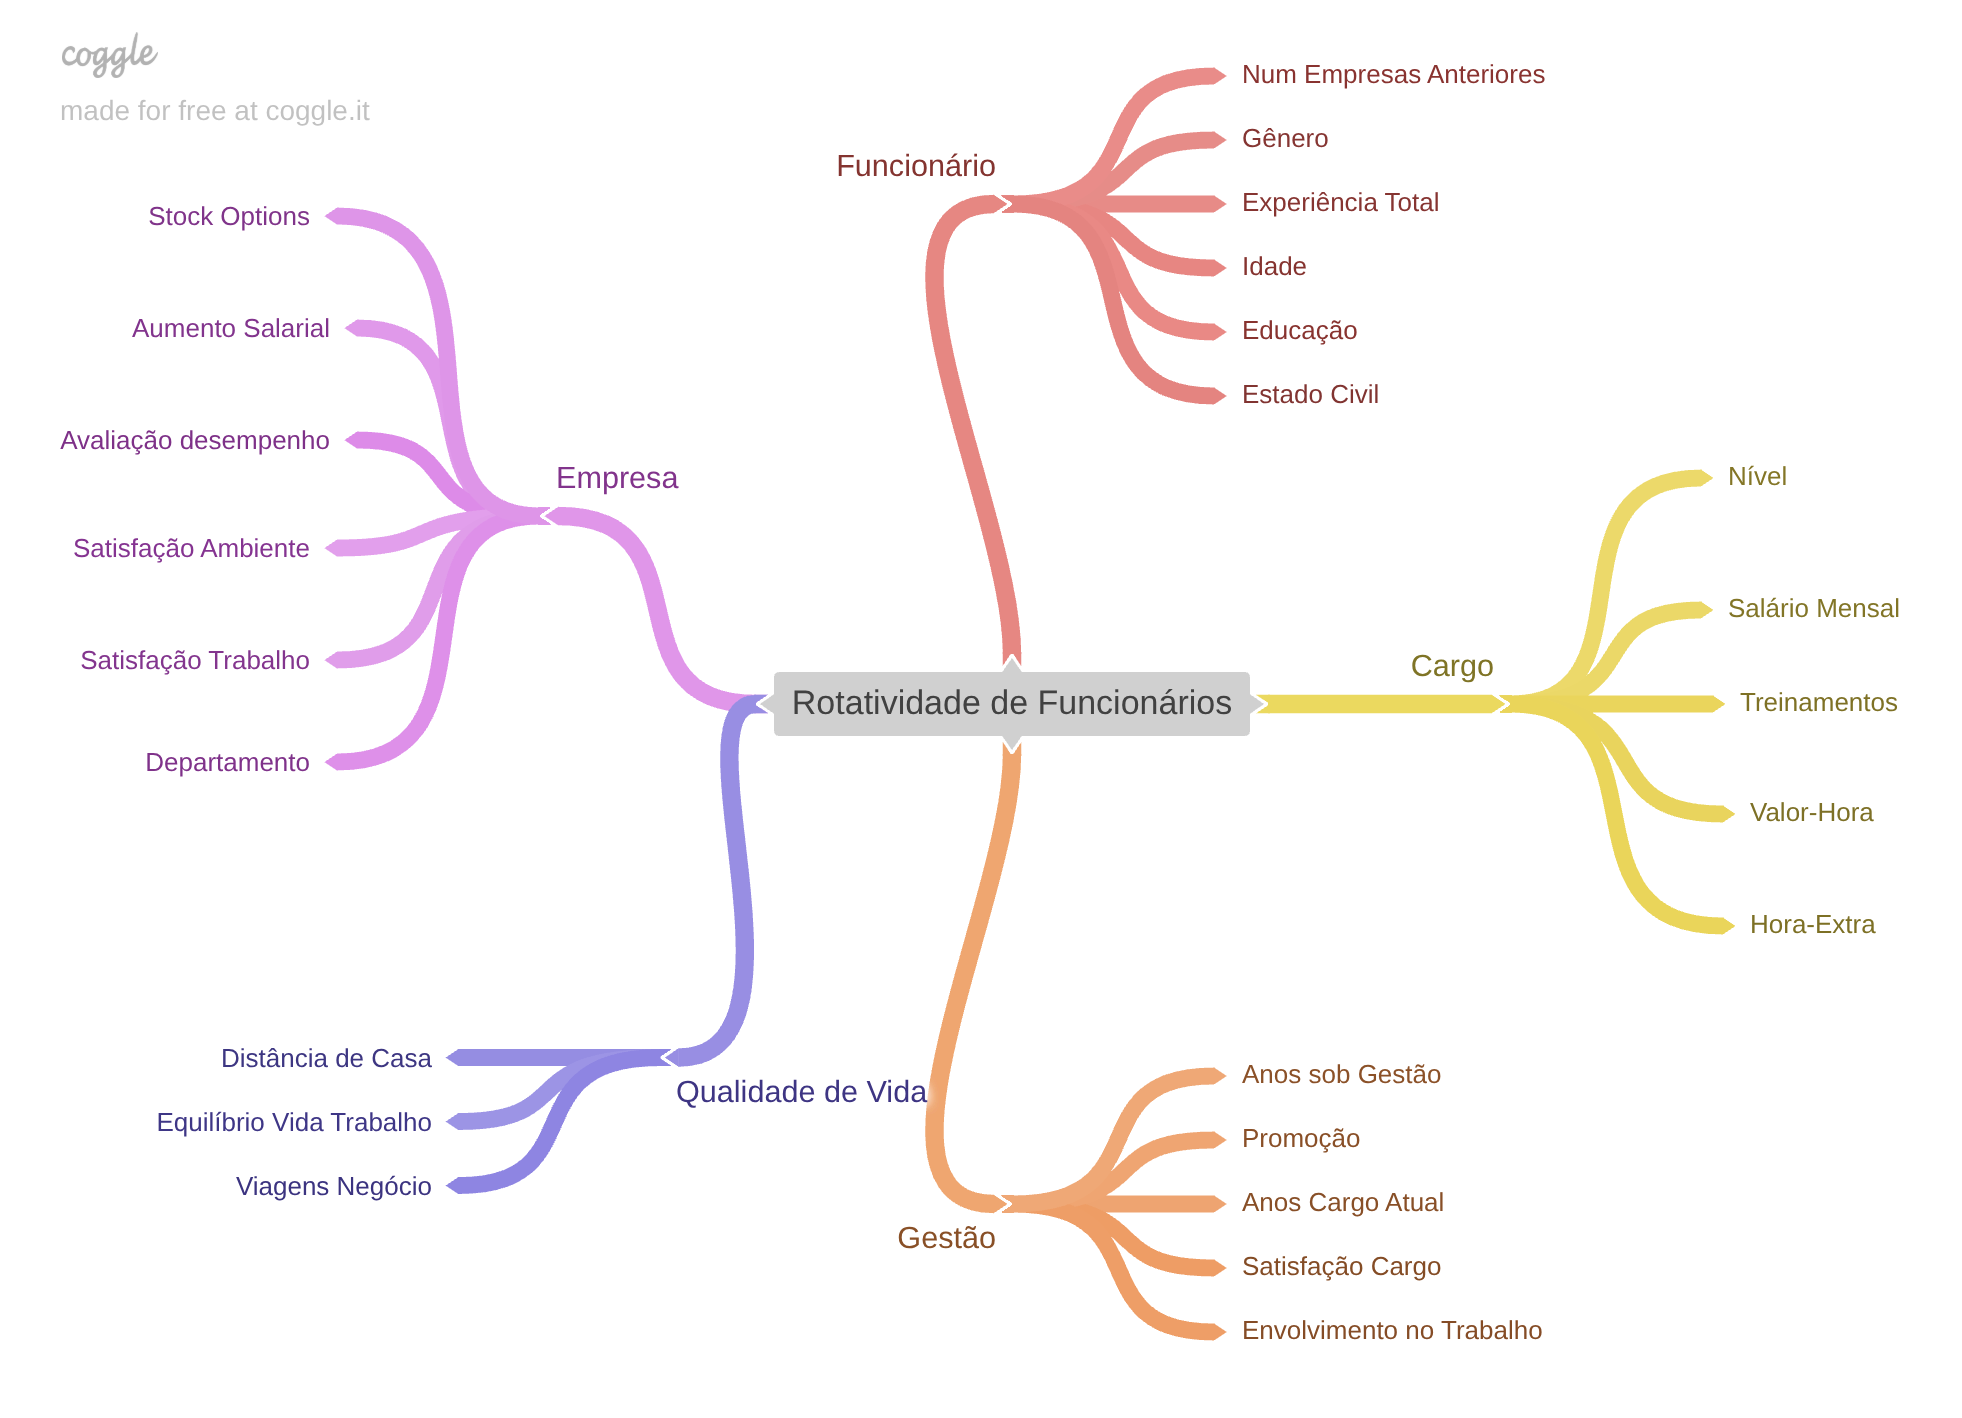

In [57]:
# Construção do mapa mental de hipóteses:
# Fenômeno: Qual fenômeno estou modelando?
# Agentes: Quem são os agentes que atuam sobre o fenômeno de interesse?
# Atributos dos agentes: que descrevem os agentes
Image('img/Rotatividade_de_Funcionarios.png')

## Criação das Hipóteses

### Dimensão: Funcionário

**H1:** Funcionários mais jovens (menores de 25 anos) tem uma taxa de rotatividade **maior** do que funcionários mais velhos.

**H2:** Funcionários solteiros tem uma taxa de rotatividade **maior** do que funcionários casados ou divorciados.

**H3:** Funcionários que já trabalharam em mais de 5 empresas anteriores tem um rotatividade maior.

### Dimensão: Cargo

**H4:** Funcionários que realizam **Horas Extras (OverTime)** tem uma taxa de rotatividade **maior**.

**H5:** Funcionários com **salários menores** (MonthlyIncome abaixo da mediana) tem um rotatividade **maior**.

**H6:** Funcionários em cargos de nível de entrada (JobLevel 1) saem **mais** do que os de níveis seniores.

### Dimensão: Empresa

**H7:** Funcionários com **baixa Satisfação com o Trabalho (JobSatisfaction 1-2)** tem maior rotatividade.

**H8:** Funcionários que não recebem opções de ações (**StockOptionLevel 0**) tem maior rotatividade.

**H9:** Funcionários em departamentos de **Vendas (Sales)** tem um rotatividade **maior** que em P&D (R&D).

### Dimensão: Gestão

**H10:** Funcionários com **pouco tempo sob o mesmo gestor** (menos de 2 anos) tem **maior** rotatividade.

**H11:** Funcionários que não são promovidos há mais de 3 anos (**YearsSinceLastPromotion**) tem **maior** probabilidade de sair.

**H12:** Funcionários com **baixo envolvimento (JobInvolvement 1-2)** tem **maior** rotatividade.

### Dimensão: Qualidade de Vida

**H13:** Funcionários que moram **mais longe do trabalho** (DistanceFromHome > 15km) tem **maior** rotatividade.

**H14:** Funcionários que viajam frequentemente (**BusinessTravel: Travel_Frequently**) tem uma taxa de rotatividade **maior**.

**H15:** Funcionários com **baixo equilíbrio de vida-trabalho (WorkLifeBalance 1-2)** deveriam sair **mais**.

## 2.1. Feature Creation

Transposição (`.T`) do `df02` apenas para visualizar todas as colunas e o primeiro conjunto de linhas de forma mais legível (linhas viram colunas na exibição).


In [58]:
df02.T

,0,1,2,3,4,5,6,7,8,9,...,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760
Age,58,27,50,39,32,29,33,30,42,32,...,33,35,49,24,33,35,41,22,29,50
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Non-Travel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,...,Non-Travel,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Rarely
DailyRate,601,1341,407,439,601,337,501,1441,557,825,...,750,1208,1495,1438,589,750,447,1256,1378,264
Department,Research & Development,Human Resources,Sales,Research & Development,Sales,Research & Development,Research & Development,Research & Development,Research & Development,Research & Development,...,Sales,Sales,Research & Development,Sales,Research & Development,Research & Development,Research & Development,Research & Development,Research & Development,Sales
DistanceFromHome,7,21,28,9,7,14,15,0,18,29,...,22,4,5,0,28,28,5,3,13,9
Education,4,2,3,3,5,1,2,5,4,4,...,2,2,4,0,4,3,3,4,2,3
EducationField,Medical,Human Resources,Marketing,Life Sciences,Marketing,Other,Medical,Life Sciences,Life Sciences,Medical,...,Marketing,Technical Degree,Technical Degree,Technical Degree,Life Sciences,Life Sciences,Life Sciences,Life Sciences,Other,Marketing
EmployeeCount,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
EmployeeNumber,1360,1950,2049,1132,1446,1421,2009,1442,1998,1089,...,160,1103,1473,542,1549,1596,1814,1203,2053,1591
EnvironmentSatisfaction,3,0,3,3,4,3,2,3,4,1,...,3,3,1,0,2,2,2,3,4,3


### Criação de novas features (feature engineering)
Cada bloco cria uma variável derivada com uma hipótese de negócio por trás:

1. **career_stability / loyalty_ratio**: quanto tempo trabalhado o funcionário "concentra" na empresa atual vs. no mercado. `NumCompaniesWorked == 0` ou `TotalWorkingYears == 0` produzem divisão por zero → `inf`, tratado ao final da célula.
2. **income_relative_total**: renda do funcionário comparada à mediana do seu próprio nível de cargo (`JobLevel`) — mede frustração salarial relativa, não salário absoluto.
3. **commuteImpact / PromotionLag / ManagerTrust**: proporções que também podem gerar `inf` quando o denominador é zero (ex.: `YearsInCurrentRole == 0` em `PromotionLag`).
4. **TotalSatisfactionScore**: soma simples de 4 escalas de satisfação (ambiente, trabalho, relacionamento, equilíbrio vida-trabalho) em um único score.
5. **OverTimeRisk**: flag binária (1/0) para o cruzamento de risco "faz hora extra E tem baixo envolvimento no trabalho".
6. **AgeGroup**: categoriza idade em faixas de ciclo de vida profissional.
7. **Stability_ratio / Income_Age_Ratio / Manager_Loyalty**: versões refinadas/alternativas das métricas de estabilidade e confiança.

**Importante:** a última linha (`df02 = df02.replace([np.inf, -np.inf], np.nan)`) foi adicionada para limpar os `inf` resultantes das divisões por zero acima. Sem essa linha, análises posteriores (regressão logística, `qcut`) quebravam com `ValueError` ao encontrar valores infinitos.


In [59]:
# 1. Estabilidade e Fidelidade
df02['career_stability'] = df02['TotalWorkingYears'] / df02['NumCompaniesWorked']
df02['loyalty_ratio'] = df02['YearsAtCompany'] / df02['TotalWorkingYears']

# 2. Renda Relativa (Mede Frustração Salarial por Nível)
median_income_per_level = df02.groupby('JobLevel')['MonthlyIncome'].transform('median')
df02['income_relative_total'] = df02['MonthlyIncome'] / median_income_per_level

# 3. Impacto do Deslocamento até o trabalho
df02['commuteImpact'] = df02['DistanceFromHome']/ (df02['MonthlyIncome'])
df02['PromotionLag'] = df02['YearsSinceLastPromotion'] / (df02['YearsInCurrentRole'])
df02['ManagerTrust'] = df02['YearsWithCurrManager'] / (df02['YearsAtCompany'])

# 4. Satisfação consolidada
df02['TotalSatisfactionScore'] = (df02['EnvironmentSatisfaction'] +
                                      df02['JobSatisfaction'] +
                                      df02['RelationshipSatisfaction'] +
                                      df02['WorkLifeBalance'])


# 5. Risco: Horas trabalhadas com baixo envolvimento
df02['OverTimeRisk'] = df02.apply(lambda x: 1 if (x['OverTime'] == 'Yes') and (x['JobInvolvement'] < 3 ) else 0, axis=1)

# 6. Categórica: Ciclo de Vida
df02['AgeGroup'] = df02['Age'].apply(lambda x: 'young' if x < 25 else ('adult' if x < 45 else 'senior'))

# 7. Estabilidade Profissional (Variáveis Refinadas)
df02['Stability_ratio'] = df02['YearsAtCompany'] / (df02['TotalWorkingYears'])
df02['Income_Age_Ratio'] = df02['MonthlyIncome'] / df02['Age']
df02['Manager_Loyalty'] = df02['YearsWithCurrManager'] / (df02['YearsAtCompany'])

df02 = df02.replace([np.inf, -np.inf], np.nan)



# 3.0. Exploratory Data Analysis

### 3.1. Univariate Analysis

`df03` é a cópia final usada em toda a Análise Exploratória de Dados (EDA), já com as features criadas em `df02`.


In [60]:
df03 = df02.copy()

#### 3.1.1. Response Variable

### 3.1.1 Variável Resposta
Mostra a proporção de cada classe (`Yes`/`No`) em `Attrition`. Isso indica se as classes estão balanceadas — importante porque desbalanceamento forte afetaria a interpretação de métricas como acurácia (embora aqui usemos principalmente AUC/KS, menos sensíveis a isso).


<Axes: xlabel='Attrition', ylabel='Proportion'>

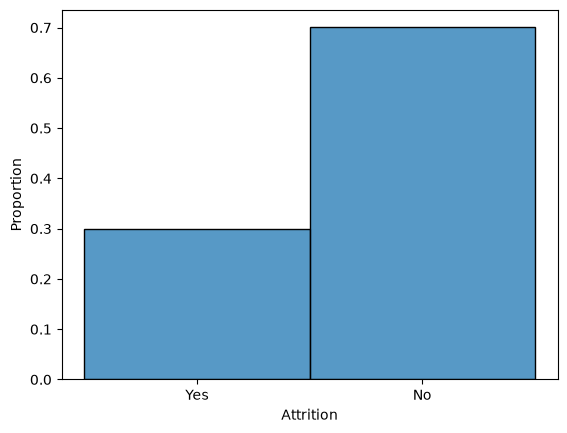

In [61]:
df03['Attrition'].value_counts(normalize=True)
sns.histplot(data=df03, x='Attrition', stat='proportion')

#### 3.1.2. Numerical Variable

### 3.1.2 Variável Numérica — Estudo de caso: Age
Antes de generalizar em loop (célula seguinte), esta célula detalha manualmente, para a variável `Age`, as três métricas de separação entre classes que serão usadas em todas as variáveis numéricas:

- **KS Statistic**: maior distância vertical entre as curvas de distribuição acumulada (CDF) de quem ficou e quem saiu. Quanto maior, mais a variável separa as duas classes.
- **Overlap Coefficient**: área de sobreposição entre as densidades (KDE) das duas classes — quanto **menor**, melhor a separação.
- **AUC Univariado**: treina uma regressão logística usando *só essa variável* para prever Attrition, e mede a AUC — quanto mais perto de 1, mais discriminativa a variável é sozinha.

Também calcula outliers pelo método IQR (valores fora de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`) e gera 3 gráficos: distribuição sobreposta, CDF por classe (mostrando o ponto de KS) e curva ROC.


KS Statistic: 0.2492, p-value: 0.0000
Interpretacao: Descriminativo

Overlap Coefficient para Age: 0.7755
Interpretacao: Fraco

AUC Univariado para Age: 0.6348
Interpretacao: Descriminativo

Outliers in Age: 0 (0.00%)


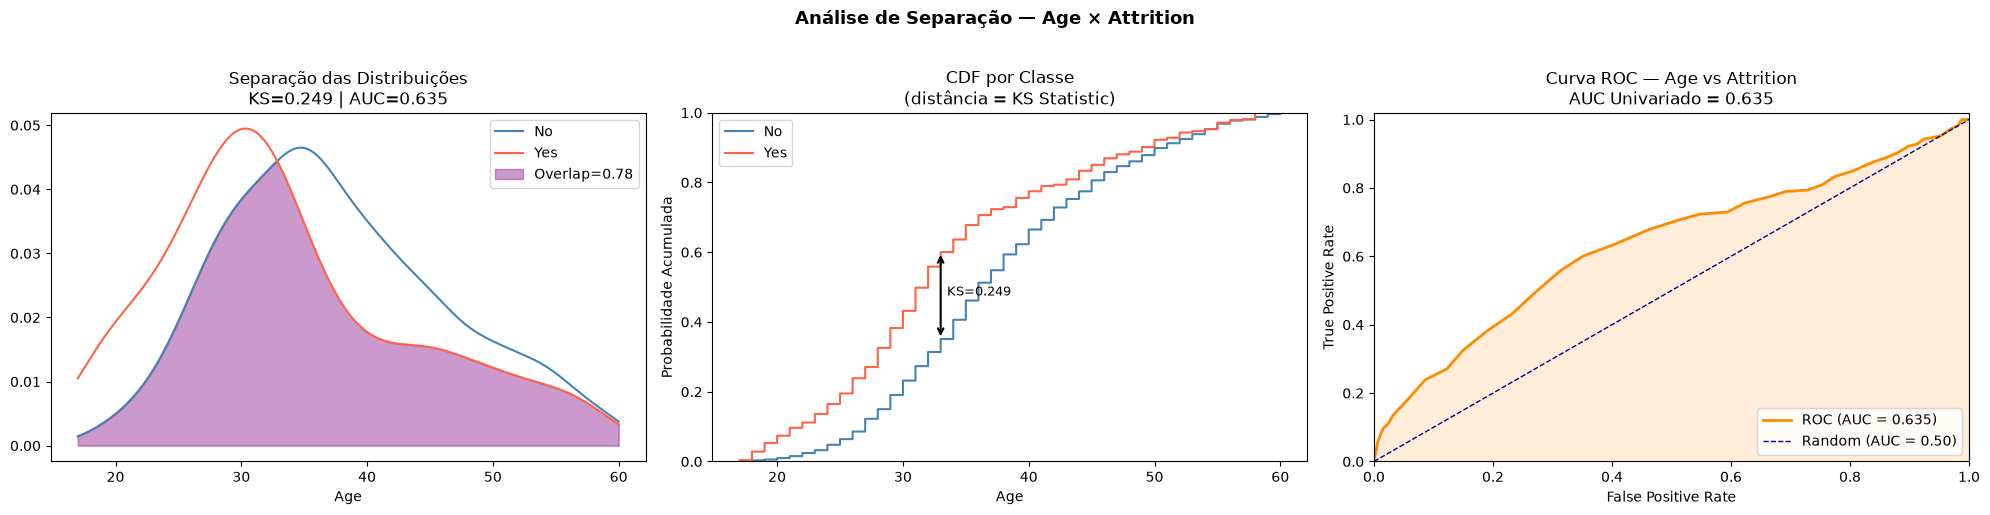

In [62]:
# KS Statistic (Kolmogorov-Smirnov)
age_no = df03.loc[df03['Attrition'] == 'No', 'Age']
age_yes = df03.loc[df03['Attrition'] == 'Yes', 'Age']

ks_stat, ks_p = stats.ks_2samp(age_no, age_yes)

print( f"KS Statistic: {ks_stat:.4f}, p-value: {ks_p:.4f}" )
print( f"Interpretacao: {'Descriminativo' if ks_stat > 0.2 else 'Fraco'}")

#=====================================================================================
# Overlap Coefficient
kde_no = gaussian_kde(age_no)
kde_yes = gaussian_kde(age_yes)

x_range = np.linspace(df_raw['Age'].min(), df_raw['Age'].max(), 1000)
overlap  = np.trapezoid(np.minimum(kde_no(x_range), kde_yes(x_range)), x_range)
print( f"\nOverlap Coefficient para Age: {overlap:.4f}" )
print( f"Interpretacao: {'Descriminativo' if overlap < 0.7 else 'Fraco'}" )

#=====================================================================================
# AUC Univariado
X = df03[['Age']]
y = LabelEncoder().fit_transform( df03['Attrition'] )

model = LogisticRegression()
model.fit( X, y )
y_prob = model.predict_proba( X )[:, 1]

auc = roc_auc_score( y, y_prob )
print( f"\nAUC Univariado para Age: {auc:.4f}" )
print( f"Interpretacao: {'Descriminativo' if auc > 0.55 else 'Fraco'}" )

#======================================================================================
# --- 3. Outliers (IQR method) ---
# series = df03['Age'].dropna()

# Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
# IQR     = Q3 - Q1
# n_outliers = int(((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum())
# pct_outliers = n_outliers / len(series) * 100

# print(f"\nOutliers: {n_outliers} ({pct_outliers:.2f}%)")
q1, q3 = df03['Age'].quantile( [0.25, 0.75] )
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

n_outliers = ( df03['Age'] < lower_bound ) | ( df03['Age'] > upper_bound )
pct_outliers =  ( n_outliers.sum() / len( df03['Age'] ) ) *100

print( f"\nOutliers in Age: {n_outliers.sum()} ({pct_outliers:.2f}%)" )

# ================================================
# Plot 1 — KDE com área de overlap destacada
# ================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x_range      = np.linspace(df_raw['Age'].min(), df_raw['Age'].max(), 1000)
kde_no_vals  = kde_no(x_range)
kde_yes_vals = kde_yes(x_range)

axes[0].plot(x_range, kde_no_vals,  label='No',  color='steelblue')
axes[0].plot(x_range, kde_yes_vals, label='Yes', color='tomato')
axes[0].fill_between(x_range, np.minimum(kde_no_vals, kde_yes_vals),
                     alpha=0.4, color='purple', label=f'Overlap={overlap:.2f}')
axes[0].set_title(f'Separação das Distribuições\nKS={ks_stat:.3f} | AUC={auc:.3f}')
axes[0].set_xlabel('Age')
axes[0].legend()

# ================================================
# Plot 2 — CDF por classe (KS Statistic)
# ================================================
axes[1].ecdf(age_no,  label='No',  color='steelblue')
axes[1].ecdf(age_yes, label='Yes', color='tomato')

# Marca o ponto de máxima distância (KS)
all_ages   = np.sort(np.concatenate([age_no, age_yes]))
cdf_no     = np.searchsorted(np.sort(age_no),  all_ages, side='right') / len(age_no)
cdf_yes    = np.searchsorted(np.sort(age_yes), all_ages, side='right') / len(age_yes)
ks_idx     = np.argmax(np.abs(cdf_no - cdf_yes))
ks_x       = all_ages[ks_idx]

axes[1].annotate('', 
    xy=(ks_x, cdf_yes[ks_idx]), xytext=(ks_x, cdf_no[ks_idx]),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
axes[1].text(ks_x + 0.5, (cdf_no[ks_idx] + cdf_yes[ks_idx]) / 2,
             f'KS={ks_stat:.3f}', fontsize=9, color='black')

axes[1].set_title('CDF por Classe\n(distância = KS Statistic)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Probabilidade Acumulada')
axes[1].legend()

# ================================================
# Plot 3 — Curva ROC (AUC Univariado)
# ================================================
fpr, tpr, _ = roc_curve(y, y_prob)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random (AUC = 0.50)')
axes[2].fill_between(fpr, tpr, alpha=0.15, color='darkorange')

axes[2].set_title(f'Curva ROC — Age vs Attrition\nAUC Univariado = {auc:.3f}')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.suptitle('Análise de Separação — Age × Attrition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### Generalização: loop de separação + outliers para TODAS as variáveis numéricas
Repete a lógica da célula anterior (KS, Overlap, AUC, outliers IQR) para cada coluna numérica, agora sem os gráficos individuais — apenas consolidando os números em uma tabela (`df_analysis`) ordenada pela AUC Univariado.

Ao final, `classify()` rotula automaticamente cada variável como discriminação 🟢 Alta (AUC ≥ 0.65), 🟡 Média (AUC ≥ 0.55) ou 🔴 Baixa — um critério de triagem rápida para decidir quais variáveis merecem mais atenção nas próximas etapas.

Os blocos `try/except` em volta do AUC e do Overlap existem porque algumas variáveis (ex.: com poucos valores únicos ou variância zero) podem falhar no `LogisticRegression.fit` ou no `gaussian_kde` — nesses casos o valor vira `NaN` em vez de quebrar o loop inteiro.


In [63]:
# ================================================
# Univariate Analysis: Separation + Outliers
# ================================================
    # Criar variável resposta "y"
    # Transformar a variável reposta em numérica - usar LabelEncoder, porque a variável resposta é categórica (Yes/No) e precisamos de valores numéricos para análise estatística.
    # Separar apenas as variáveis numéricas para análise estatística (excluindo a variável resposta e variáveis categóricas).
    # Criar loop para percorrer cada variável numérica e calcular as métricas de separação (KS Statistic, Overlap Coefficient, AUC Univariado) e identificar outliers usando o método IQR.
        # Dropar as séries com valores nulos para cada variável numérica antes de calcular as métricas.
        # criar grupos para cada variável numérica com base na variável resposta (Yes/No).
        # Ditribuição - criar métricas de distribuição média, desvio padrão
        # Calcular separação entre classes (KS Statistic, Overlap Coefficient, AUC Univariado)
        # Outiliers - identificar outliers usando o método IQR e calcular a porcentagem de outliers para cada variável numérica.
    # Criar dataframe com as métricas calculadas para cada variável numérica e exibir os resultados.
    # Inserir classificação automática das variáveis numéricas com base no poder discriminativo AUC 

y = LabelEncoder().fit_transform(df03['Attrition'])
num_cols = df03.select_dtypes(include=['int64', 'float64']).columns.tolist()

results = [ ]

for col in num_cols:
    series = df03[col].dropna()
    group_no = df03.loc[df03['Attrition'] == 'No', col].dropna()
    group_yes = df03.loc[df03['Attrition'] == 'Yes', col].dropna()

# --- 1. Distribuição ---
    mean_no, std_no   = group_no.mean(), group_no.std() 
    mean_yes, std_yes = group_yes.mean(), group_yes.std()

# --- 2. Separação entre classes ---
    # KS Statistic
    ks_stat, ks_p = stats.ks_2samp(group_no, group_yes)

# AUC Univariado
    X_col = df03[[col]].fillna(df03[col].median())
    try:
        model = LogisticRegression(max_iter=500).fit(X_col, y)
        auc   = roc_auc_score(y, model.predict_proba(X_col)[:, 1])
        auc   = max(auc, 1 - auc)   # garante AUC >= 0.5
    except Exception:
        auc = np.nan

# Overlap Coefficient via KDE
    try:
        kde_no  = gaussian_kde(group_no)
        kde_yes = gaussian_kde(group_yes)
        x_range = np.linspace(series.min(), series.max(), 500)
        overlap = float(np.trapezoid(np.minimum(kde_no(x_range), kde_yes(x_range)), x_range))
    except Exception:
        overlap = np.nan

# --- 3. Outliers (IQR method) ---
    # Overlap Coefficient via KDE
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR     = Q3 - Q1
    n_outliers = int(((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum())
    pct_outliers = n_outliers / len(series) * 100

    results.append({
        'Feature'        : col,
        'Mean (No)'      : round(mean_no, 2),
        'Mean (Yes)'     : round(mean_yes, 2),
        'Std (No)'       : round(std_no, 2),
        'Std (Yes)'      : round(std_yes, 2),
        'KS Stat'        : round(ks_stat, 4),
        'KS p-value'     : round(ks_p, 4),
        'AUC Univariado' : round(auc, 4),
        'Overlap Coef.'  : round(overlap, 4),
        'N Outliers'     : n_outliers,
        '% Outliers'     : round(pct_outliers, 2),
    })

df_analysis = pd.DataFrame(results).sort_values('AUC Univariado', ascending=False)

# --- Classificação automática por poder discriminativo ---
def classify(row):
    if row['AUC Univariado'] >= 0.65:
        return '🟢 Alta'
    elif row['AUC Univariado'] >= 0.55:
        return '🟡 Média'
    else:
        return '🔴 Baixa'

df_analysis['Discriminação'] = df_analysis.apply(classify, axis=1)


print("=" * 80)
print("UNIVARIATE ANALYSIS SUMMARY")
print("=" * 80)
df_analysis.style.background_gradient(subset = ['KS Stat', 'Overlap Coef.', 'AUC Univariado', '% Outliers'], cmap = 'RdYlGn')



UNIVARIATE ANALYSIS SUMMARY


,Feature,Mean (No),Mean (Yes),Std (No),Std (Yes),KS Stat,KS p-value,AUC Univariado,Overlap Coef.,N Outliers,% Outliers,Discriminação
32,TotalSatisfactionScore,11.060000,9.080000,1.970000,2.370000,0.348400,0.000000,0.735400,0.657700,18,1.020000,🟢 Alta
9,JobLevel,2.150000,1.430000,1.120000,1.090000,0.298700,0.000000,0.680400,0.704900,189,10.730000,🟢 Alta
8,JobInvolvement,2.770000,2.200000,0.690000,0.900000,0.288400,0.000000,0.673400,0.645600,22,1.250000,🟢 Alta
19,TotalWorkingYears,11.860000,8.210000,7.760000,7.550000,0.234000,0.000000,0.659700,0.754900,53,3.010000,🟢 Alta
18,StockOptionLevel,0.850000,0.430000,0.840000,0.810000,0.336600,0.000000,0.659100,0.449800,97,5.510000,🟢 Alta
22,YearsAtCompany,7.370000,5.100000,6.100000,6.310000,0.267500,0.000000,0.659000,0.722900,106,6.020000,🟢 Alta
23,YearsInCurrentRole,4.480000,2.790000,3.650000,3.130000,0.248200,0.000000,0.655200,0.699700,6,0.340000,🟢 Alta
25,YearsWithCurrManager,4.370000,2.760000,3.590000,3.190000,0.265000,0.000000,0.649900,0.690400,7,0.400000,🟡 Média
26,career_stability,6.010000,3.900000,5.350000,5.030000,0.278700,0.000000,0.646100,0.728400,55,3.750000,🟡 Média
10,JobSatisfaction,2.780000,2.170000,1.090000,1.200000,0.201300,0.000000,0.640100,0.704000,0,0.000000,🟡 Média


#### 3.1.3. Categorical Variable

### 3.1.3 Variável Categórica — Análise univariada
Mesma ideia da análise numérica, mas adaptada a variáveis categóricas:

- **Chi-Square (χ²)**: testa se existe associação estatisticamente significativa entre a categoria e `Attrition` (p-value baixo → associação real, não coincidência).
- **Cramér's V**: mede a *força* dessa associação (0 a 1), complementando o χ² (que só diz *se* existe associação, não o quanto).
- **AUC Univariado**: mesma lógica da análise numérica — aqui a categoria é primeiro codificada como número (`LabelEncoder`) para poder entrar na regressão logística.
- **Taxa de Attrition por categoria**: dicionário com a % de saída (`Yes`) dentro de cada valor da categoria — útil para ver *qual* valor da categoria concentra o risco.


In [64]:
# --- Análise categórica ---
y = LabelEncoder().fit_transform(df03['Attrition'])  # No=0, Yes=1
cat_cols = df03.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Attrition']

results_cat = []

for col in cat_cols:
    series = df03[col].fillna('Missing')

    # --- 1. Chi-Square ---
    contingency = pd.crosstab(series, df03['Attrition'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

    # --- 2. Cramér's V (Effect Size) ---
    cv = cramers_v(series, df03['Attrition'])

    # --- 3. AUC Univariado ---
    X_enc = LabelEncoder().fit_transform(series).reshape(-1, 1)
    try:
        model = LogisticRegression(max_iter=300).fit(X_enc, y)
        auc   = roc_auc_score(y, model.predict_proba(X_enc)[:, 1])
        auc   = max(auc, 1 - auc)
    except Exception:
        auc = np.nan

    # --- 4. Taxa de Attrition por categoria ---
    attrition_rate = (
        df03.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean())
        .to_dict()
    )

    results_cat.append({
        'Feature'            : col,
        'Chi2'               : round(chi2, 2),
        'p-value'            : round(p_value, 4),
        "Cramér's V"         : round(cv, 4),
        'AUC Univariado'     : round(auc, 4),
        'Taxa Attrition/Cat' : {k: f"{v:.0%}" for k, v in attrition_rate.items()},
    })

def classify_cat(row):
    if row['AUC Univariado'] >= 0.65:  return '🟢 Alta'
    elif row['AUC Univariado'] >= 0.55: return '🟡 Média'
    else:                               return '🔴 Baixa'

df_cat_analysis = pd.DataFrame(results_cat).sort_values('AUC Univariado', ascending=False)
df_cat_analysis['Discriminação'] = df_cat_analysis.apply(classify_cat, axis=1)

print("=" * 70)
print("CATEGORICAL UNIVARIATE ANALYSIS")
print("=" * 70)
df_cat_analysis[['Feature', 'Chi2', 'p-value', "Cramér's V", 'AUC Univariado', 'Discriminação']]


/tmp/ipykernel_101455/767016800.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df03.select_dtypes(include=['object']).columns.tolist()
/tmp/ipykernel_101455/3643401091.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))


CATEGORICAL UNIVARIATE ANALYSIS


,Feature,Chi2,p-value,Cramér's V,AUC Univariado,Discriminação
7,OverTime,155.54,0.0000,0.2963,0.6527,🟢 Alta
5,MaritalStatus,90.01,0.0000,0.2236,0.6273,🟡 Média
4,JobRole,157.72,0.0000,0.2917,0.5738,🟡 Média
1,Department,36.78,0.0000,0.1406,0.5555,🟡 Média
8,AgeGroup,68.87,0.0000,0.1949,0.5436,🔴 Baixa
3,Gender,2.18,0.1396,0.0259,0.5195,🔴 Baixa
2,EducationField,30.32,0.0000,0.1199,0.5170,🔴 Baixa
0,BusinessTravel,38.71,0.0000,0.1444,0.5140,🔴 Baixa
6,Over18,0.00,1.0000,NaN,0.5000,🔴 Baixa


Gera um grid de gráficos de barra (um por variável categórica) mostrando a taxa de Attrition por categoria, com Cramér's V e AUC no título de cada subplot para leitura rápida. A linha tracejada horizontal marca a taxa média geral de Attrition, servindo de referência visual para identificar categorias acima/abaixo da média.


/tmp/ipykernel_101455/171990453.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=attrition_rate, x=col, y='Attrition Rate',
/tmp/ipykernel_101455/171990453.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_101455/171990453.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=attrition_rate, x=col, y='Attrition Rate',
/tmp/ipykernel_101455/171990453.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

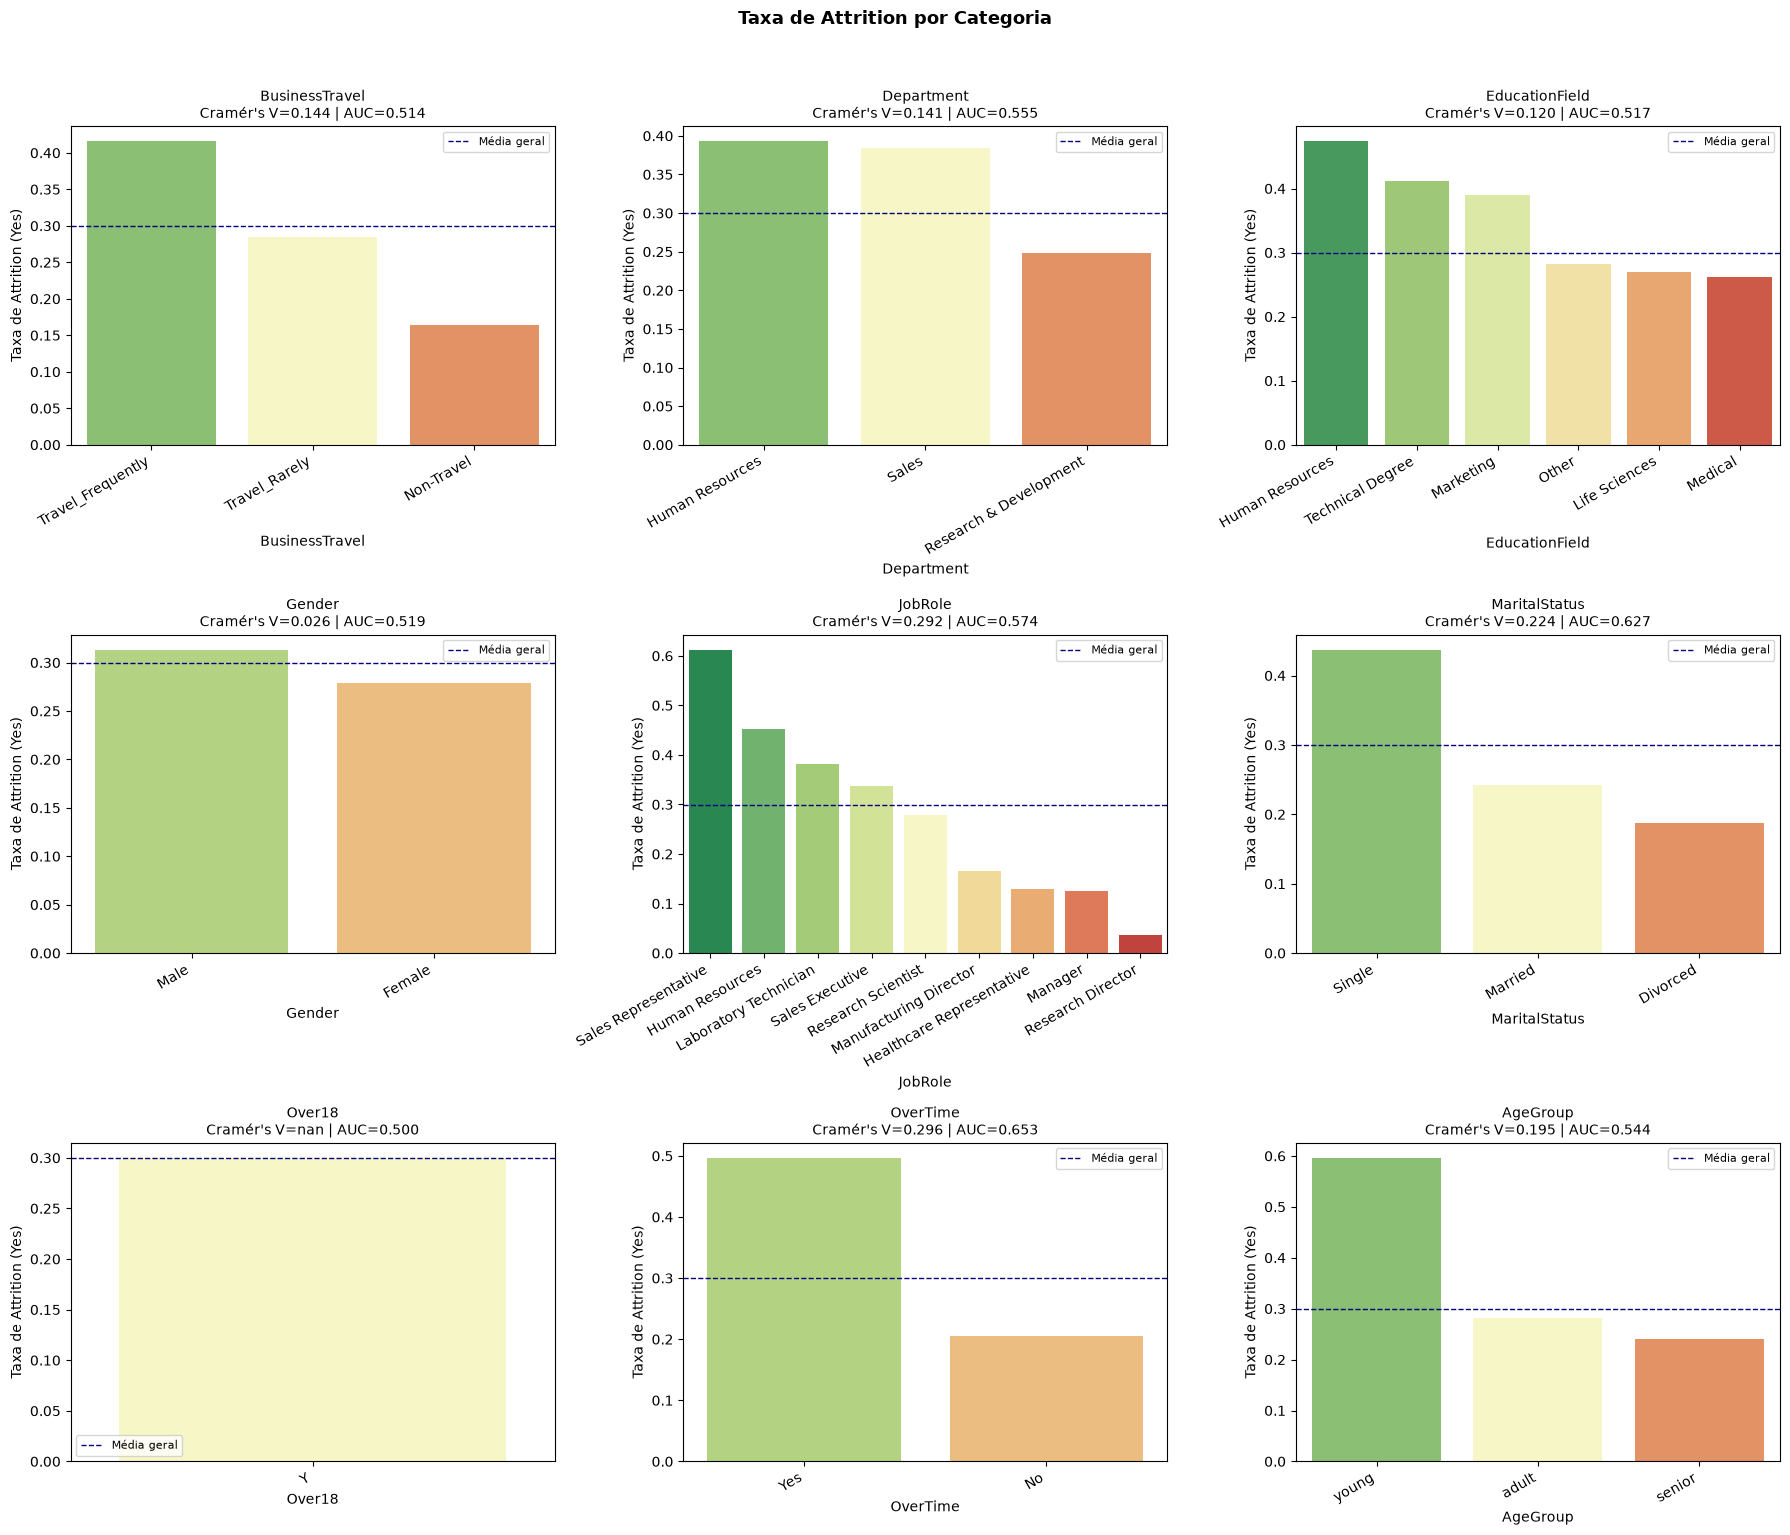

In [65]:
import math

max_cols = 3
n_plots  = len(cat_cols)
n_cols   = min(n_plots, max_cols)
n_rows   = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()   # garante sempre 1D mesmo com 1 linha

for i, col in enumerate(cat_cols):
    attrition_rate = (
        df03.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean())
        .sort_values(ascending=False)
        .reset_index()
    )
    attrition_rate.columns = [col, 'Attrition Rate']

    row = df_cat_analysis[df_cat_analysis['Feature'] == col].iloc[0]
    cv  = row["Cramér's V"]
    auc = row['AUC Univariado']

    sns.barplot(data=attrition_rate, x=col, y='Attrition Rate',
                ax=axes[i], palette='RdYlGn_r')
    axes[i].set_title(f"{col}\nCramér's V={cv:.3f} | AUC={auc:.3f}", fontsize=10)
    axes[i].set_ylabel('Taxa de Attrition (Yes)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].axhline(df_raw['Attrition'].eq('Yes').mean(),
                    color='navy', linestyle='--', linewidth=1, label='Média geral')
    axes[i].legend(fontsize=8)

# Oculta eixos vazios (quando n_plots não preenche o grid)
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de Attrition por Categoria', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.2. Bivariate Analysis

#### Numerical Bivariate

### Análise Bivariada Numérica × Attrition
Para cada variável numérica, monta um painel com 4 gráficos + métricas:

1. **Boxplot** e **2. Violin Plot**: comparam a distribuição da variável entre quem ficou (`No`) e quem saiu (`Yes`).
3. **Probability Plot**: divide a variável em 6 faixas por quantil (`qcut`; se houver muitos valores repetidos e o `qcut` não conseguir criar 6 faixas distintas, cai no `cut` por intervalos iguais) e mostra a taxa de Attrition dentro de cada faixa — revela se a relação com o alvo é linear, em degrau, ou em "U".
4. **KDE por classe**: densidade da variável por classe, com a correlação ponto-biserial (`r_pb`, equivalente à correlação de Pearson quando uma das variáveis é binária) indicando direção e força da associação.

**Proteções incluídas:**
- Se uma faixa de quantil ficar sem dados válidos (`Taxa Attrition` toda `NaN`), a célula avisa e pula o gráfico daquela variável (`continue`) em vez de quebrar o loop.
- O limite superior do eixo Y do Probability Plot (`ymax`) usa um fallback (`1.0`) quando não há valor válido, evitando o erro `Axis limits cannot be NaN or Inf`.


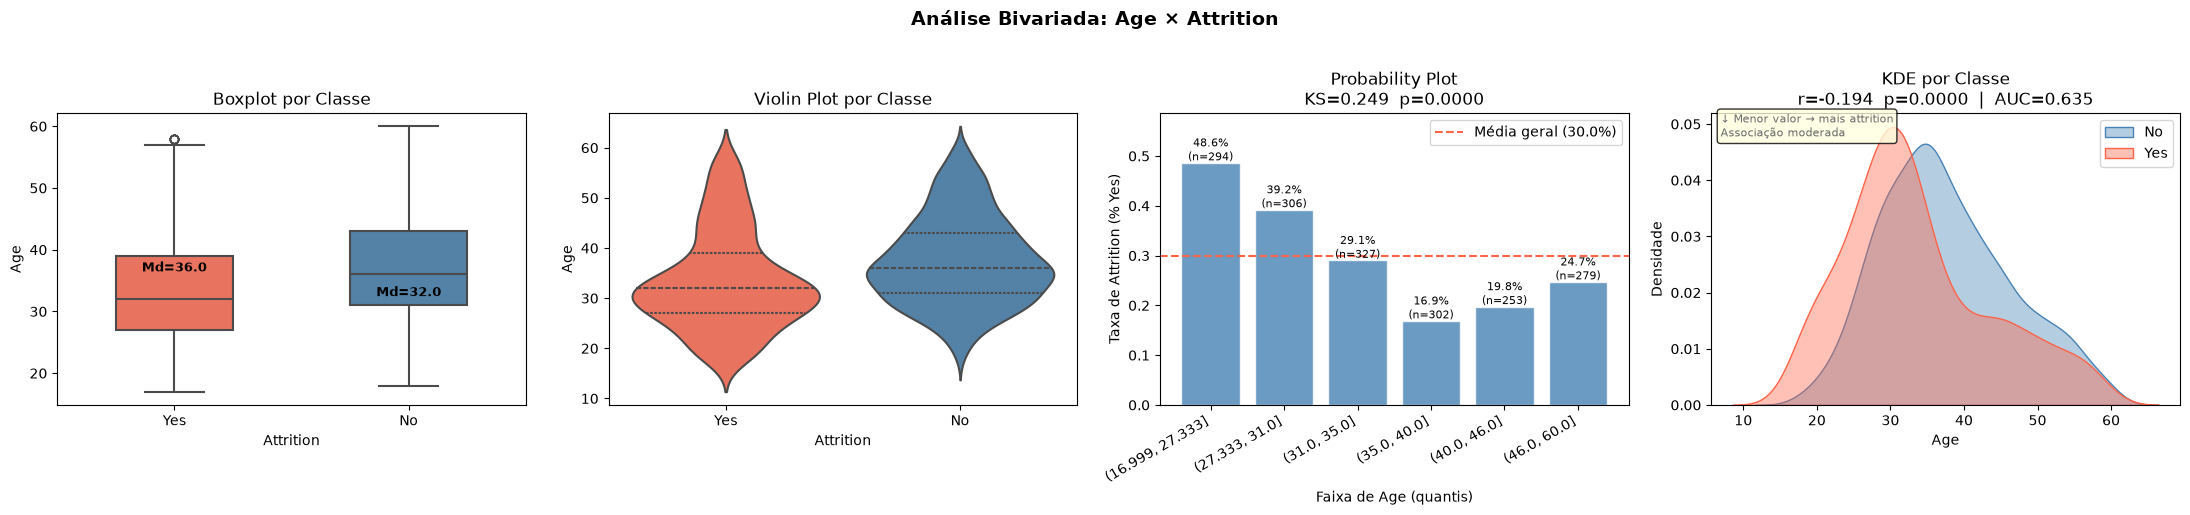

─────────────────────────────────────────────────────────────────
  Age
  KS=0.2492  p=0.0000  |  r=-0.1944  |  AUC=0.6348  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



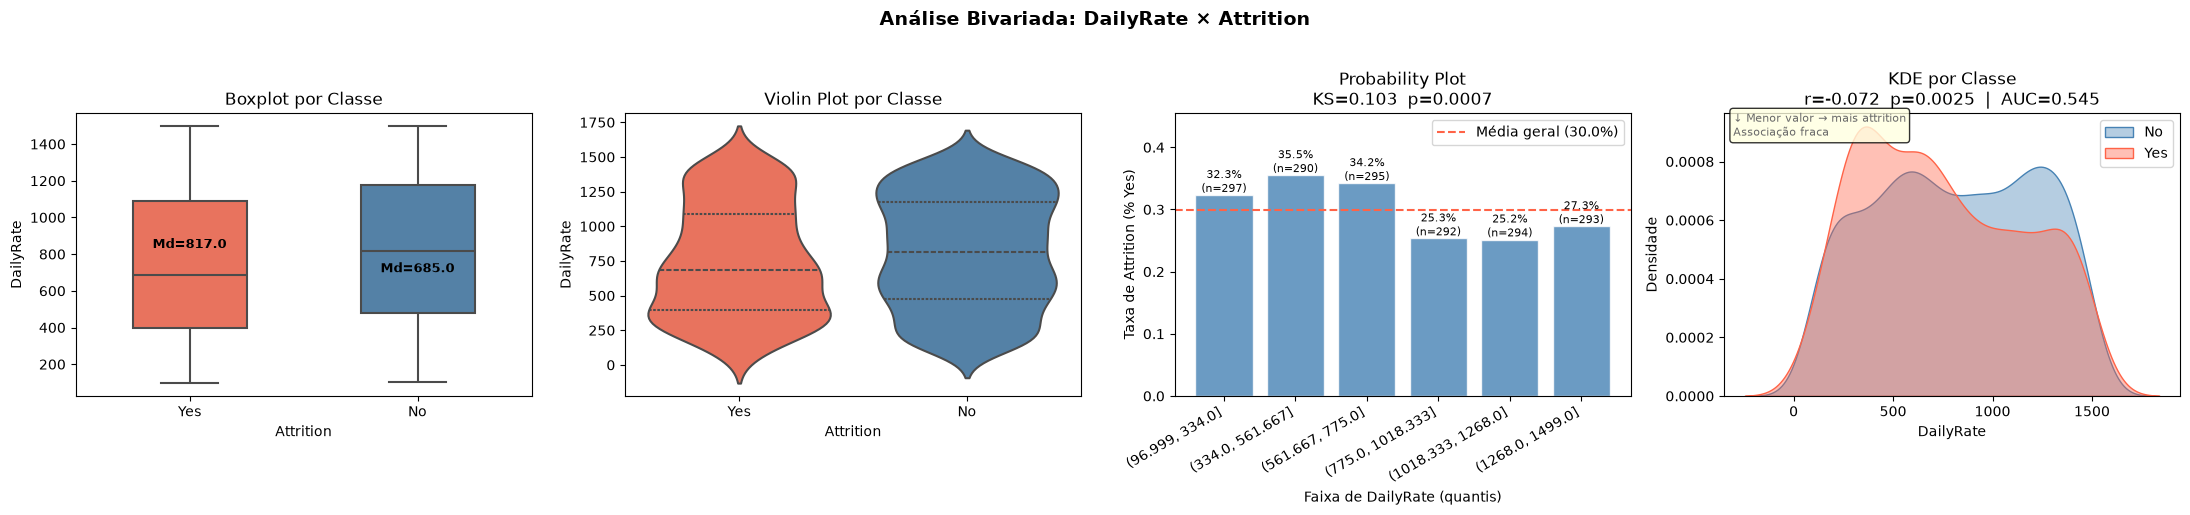

─────────────────────────────────────────────────────────────────
  DailyRate
  KS=0.1027  p=0.0007  |  r=-0.0721  |  AUC=0.5454  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



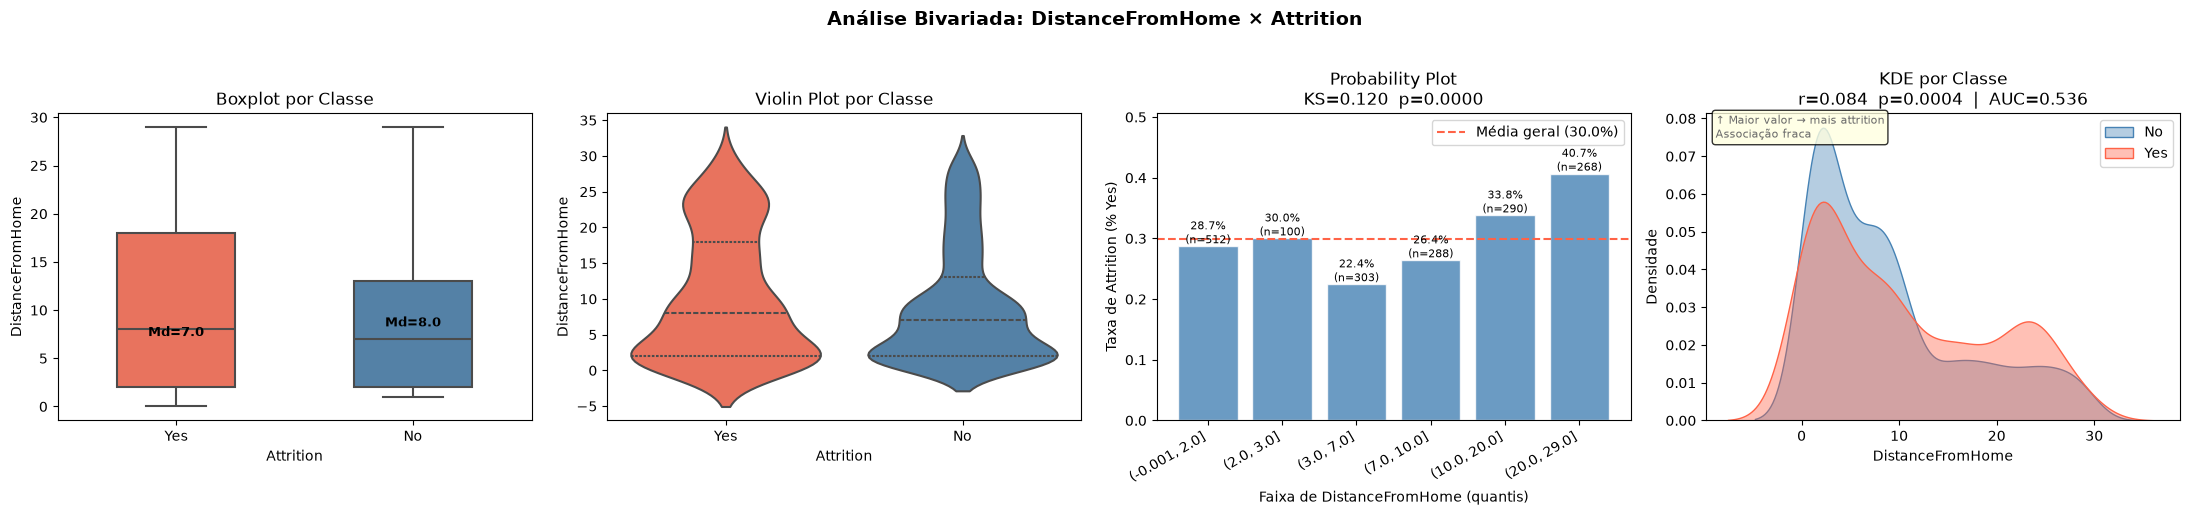

─────────────────────────────────────────────────────────────────
  DistanceFromHome
  KS=0.1201  p=0.0000  |  r=0.0842  |  AUC=0.5361  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



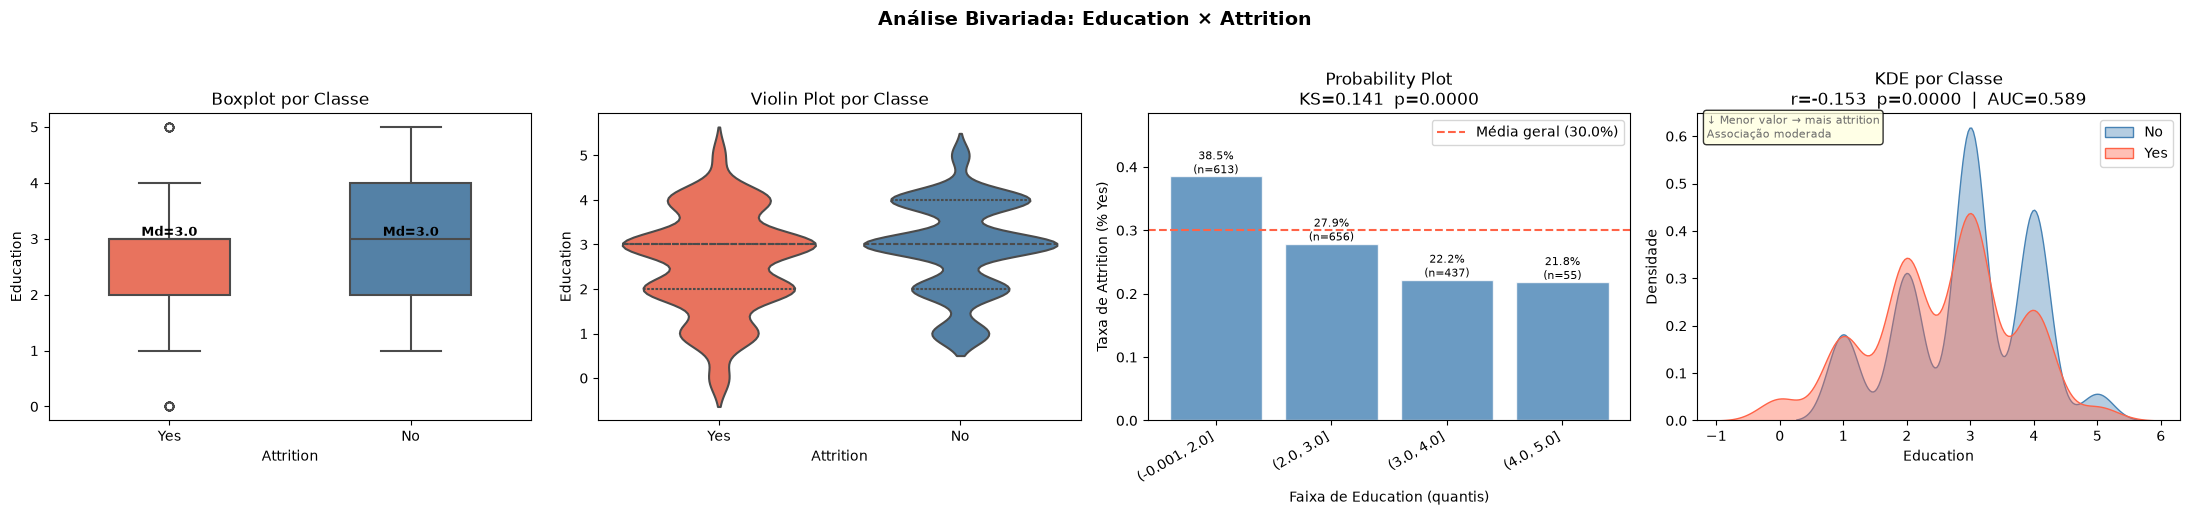

─────────────────────────────────────────────────────────────────
  Education
  KS=0.1412  p=0.0000  |  r=-0.1533  |  AUC=0.5887  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────

⚠️ EmployeeCount: não foi possível calcular faixas de quantil (valores insuficientes) — pulando plot.


/home/alvaro/.pyenv/versions/3.14.2/envs/metodologiacrisp/lib/python3.14/site-packages/scipy/stats/_stats_py.py:5567: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y, axis=axis)


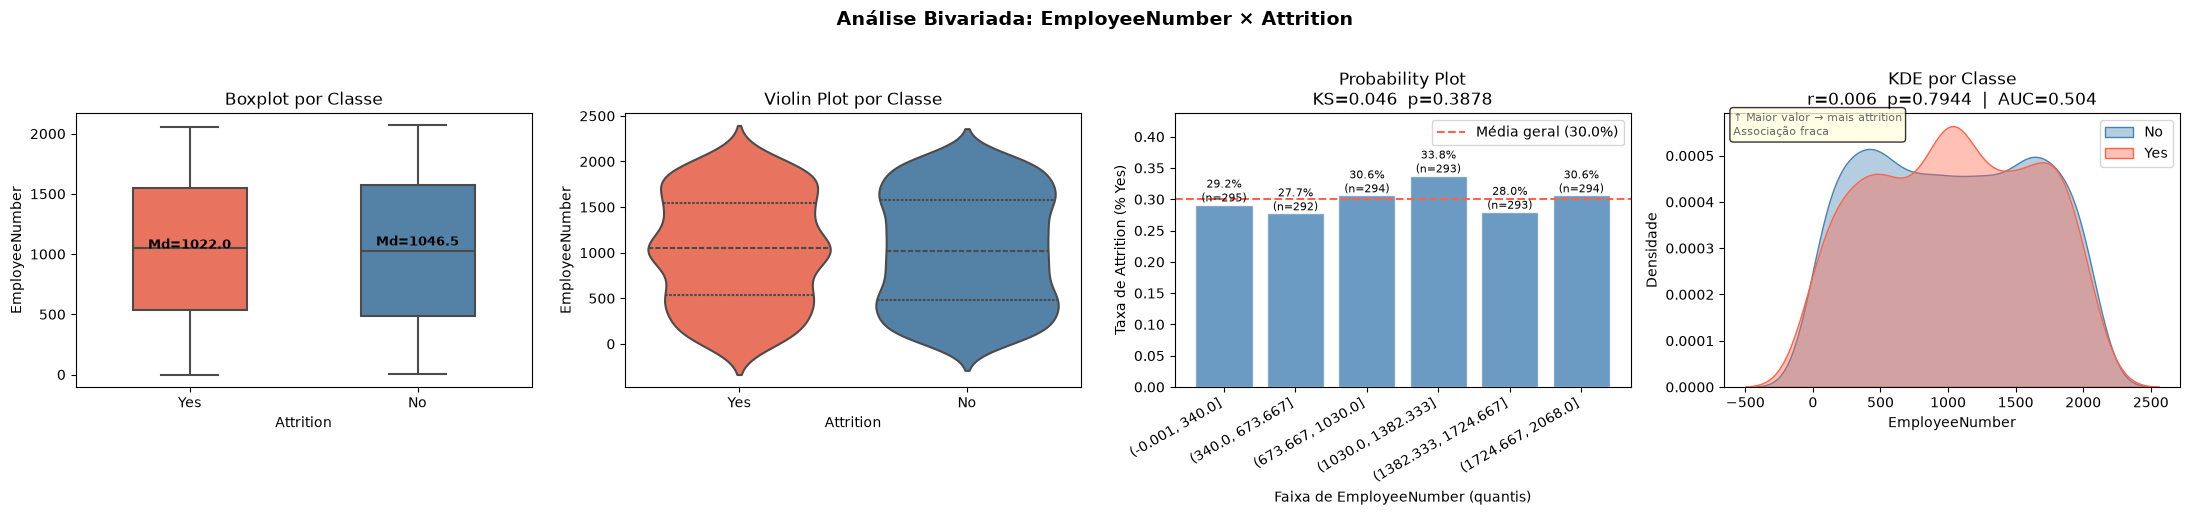

─────────────────────────────────────────────────────────────────
  EmployeeNumber
  KS=0.0464  p=0.3878  |  r=0.0062  |  AUC=0.5040  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



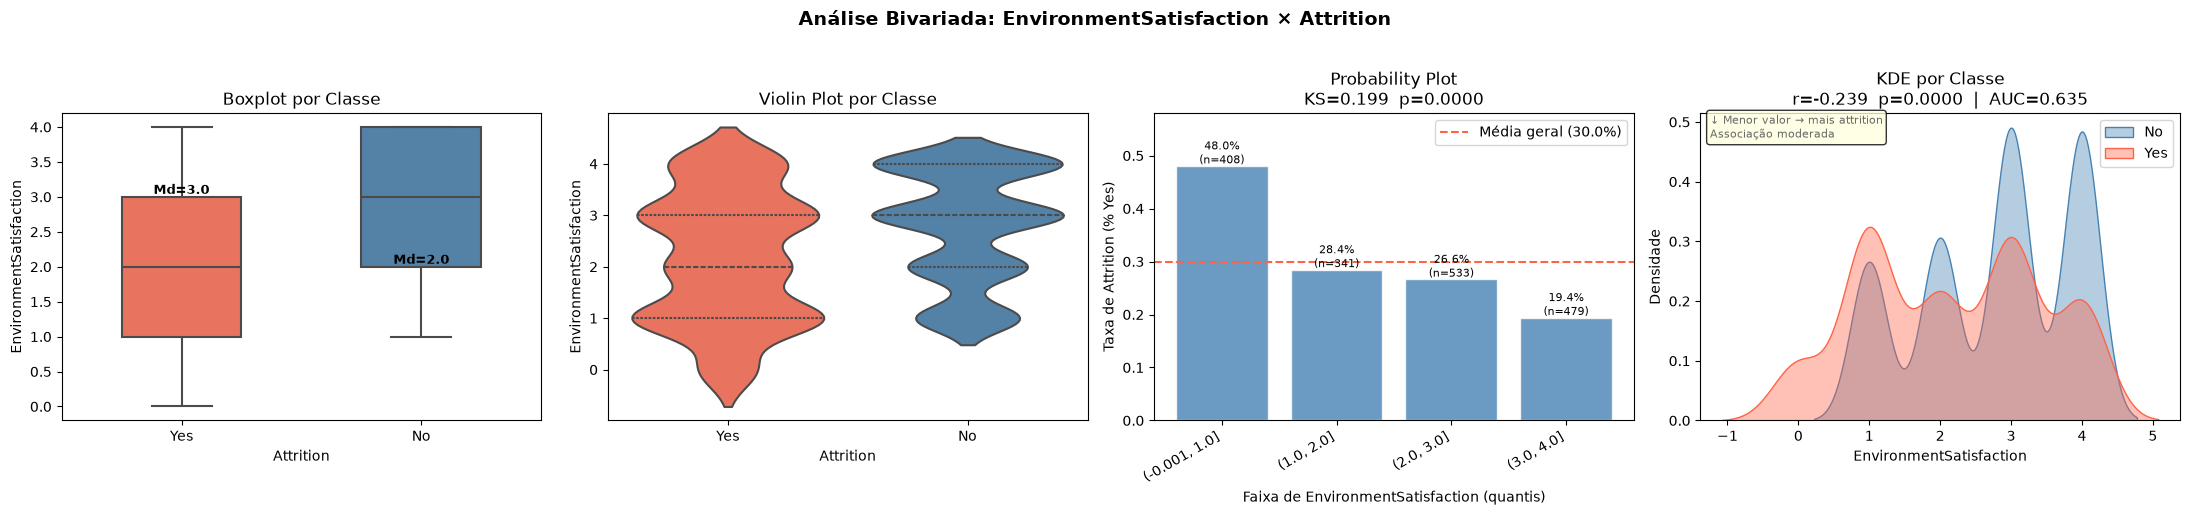

─────────────────────────────────────────────────────────────────
  EnvironmentSatisfaction
  KS=0.1993  p=0.0000  |  r=-0.2390  |  AUC=0.6350  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



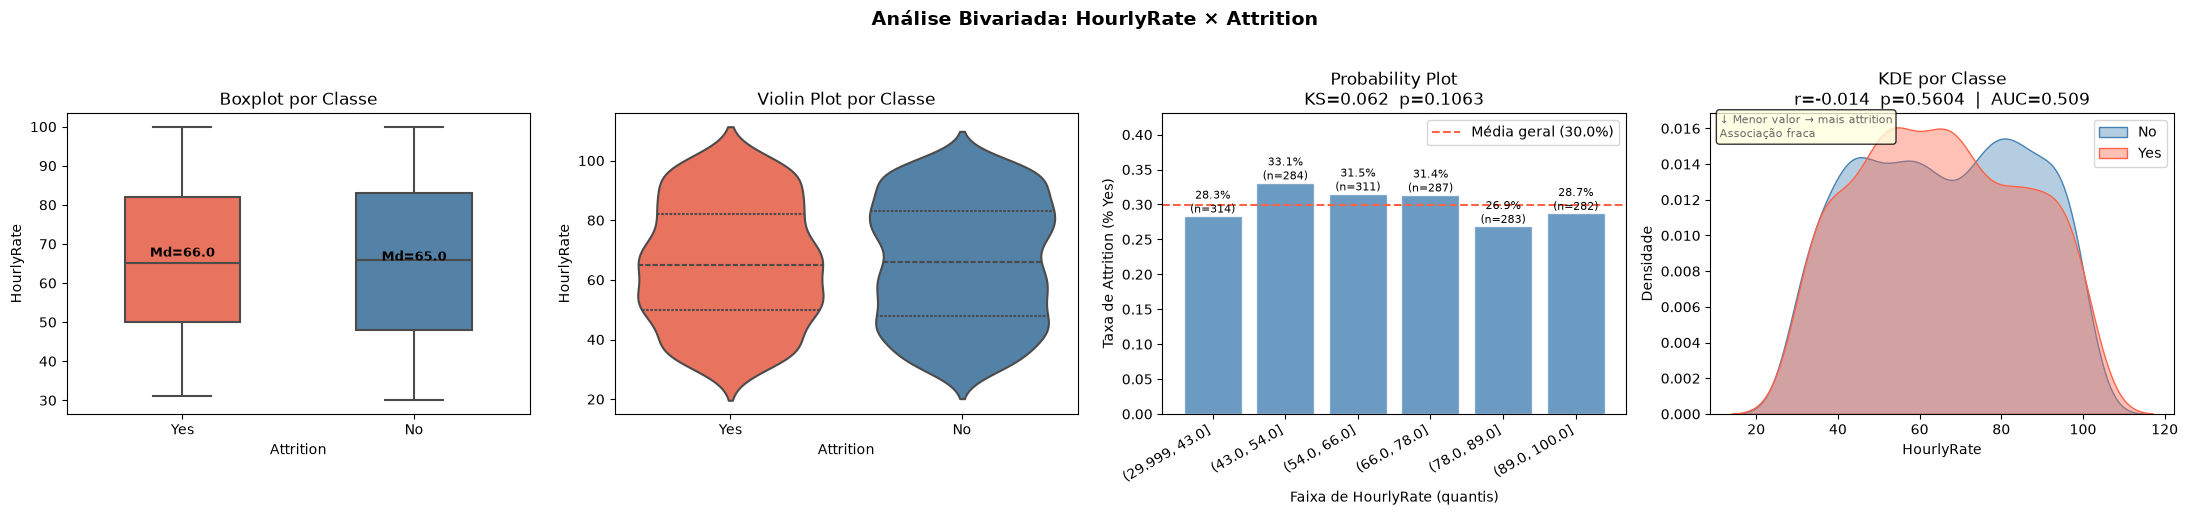

─────────────────────────────────────────────────────────────────
  HourlyRate
  KS=0.0624  p=0.1063  |  r=-0.0139  |  AUC=0.5086  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



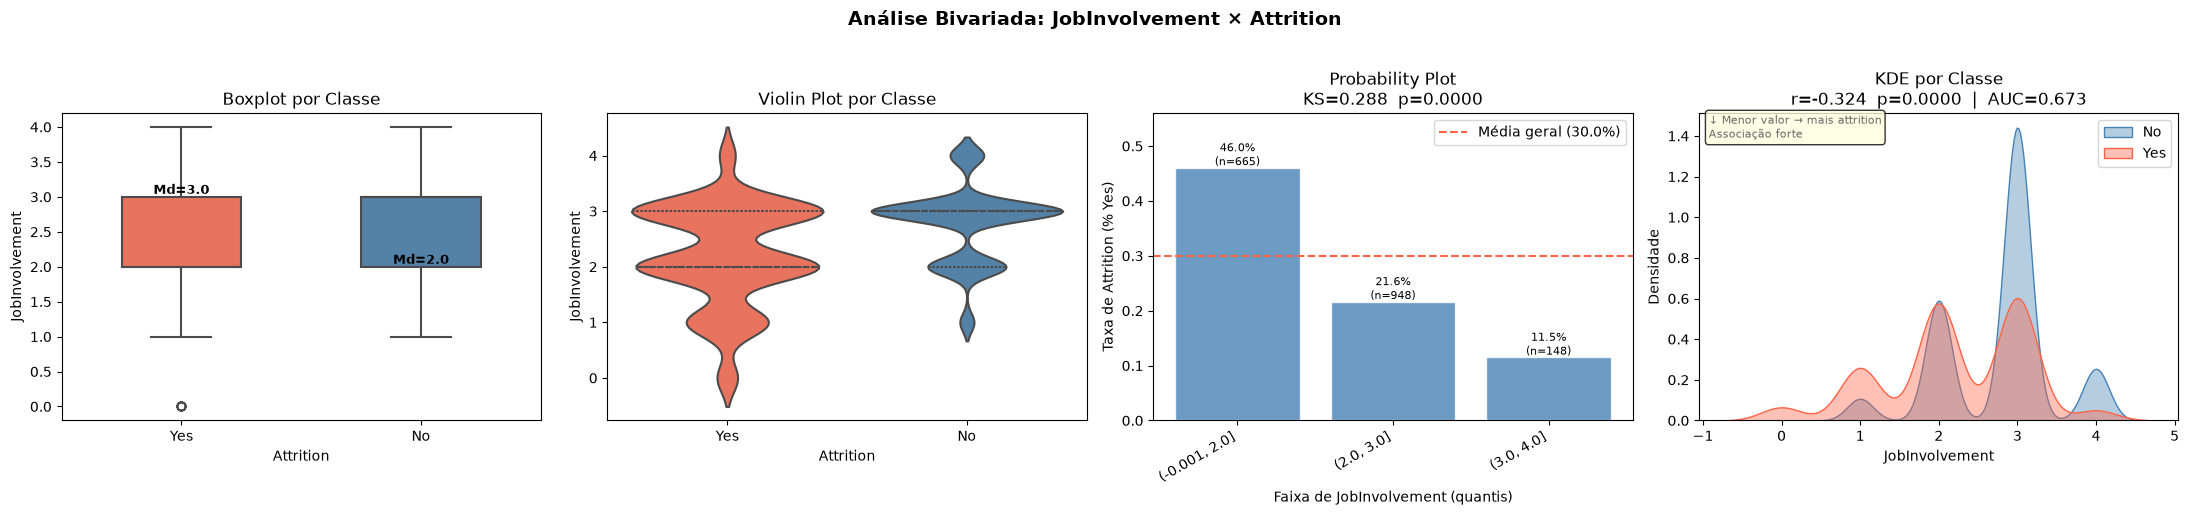

─────────────────────────────────────────────────────────────────
  JobInvolvement
  KS=0.2884  p=0.0000  |  r=-0.3238  |  AUC=0.6734  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



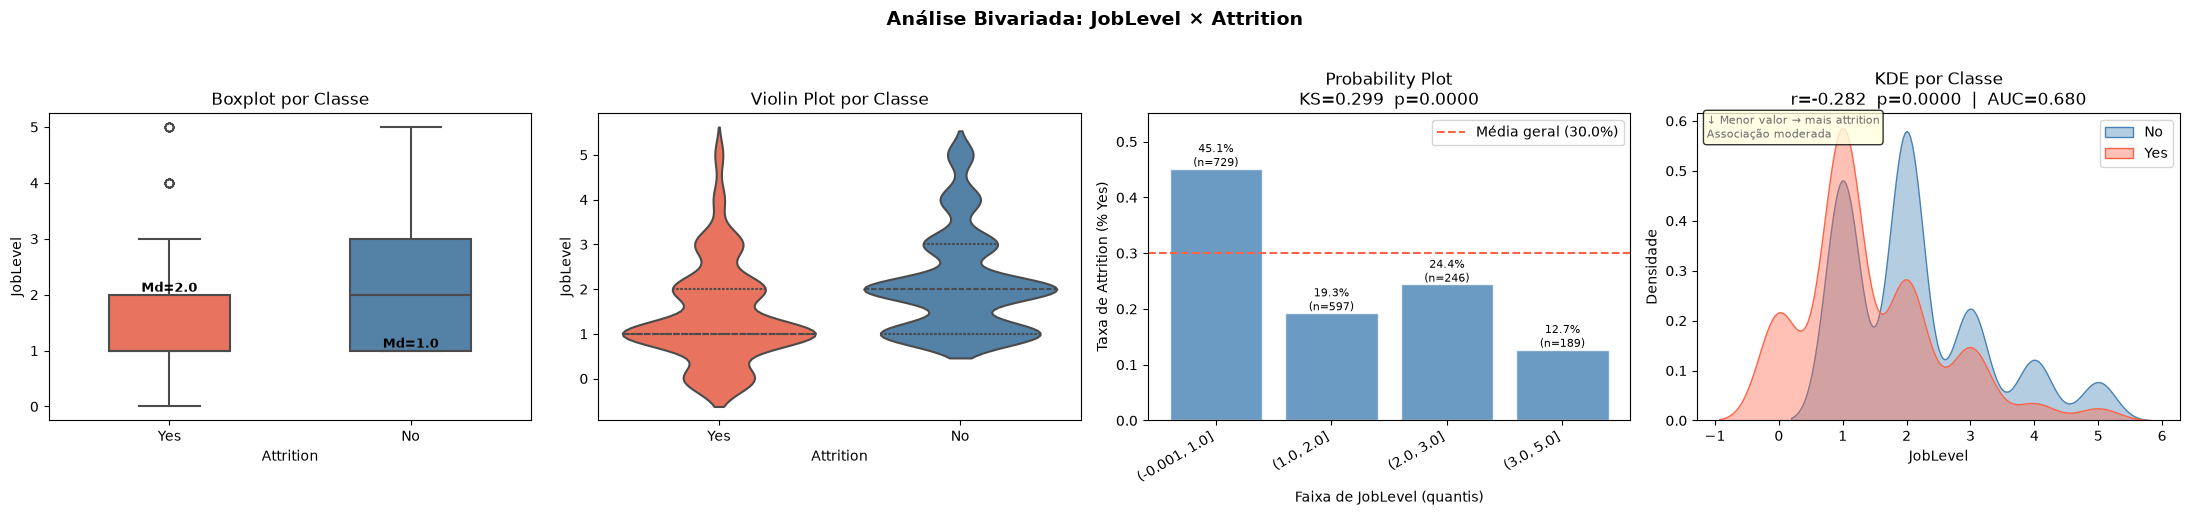

─────────────────────────────────────────────────────────────────
  JobLevel
  KS=0.2987  p=0.0000  |  r=-0.2821  |  AUC=0.6804  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



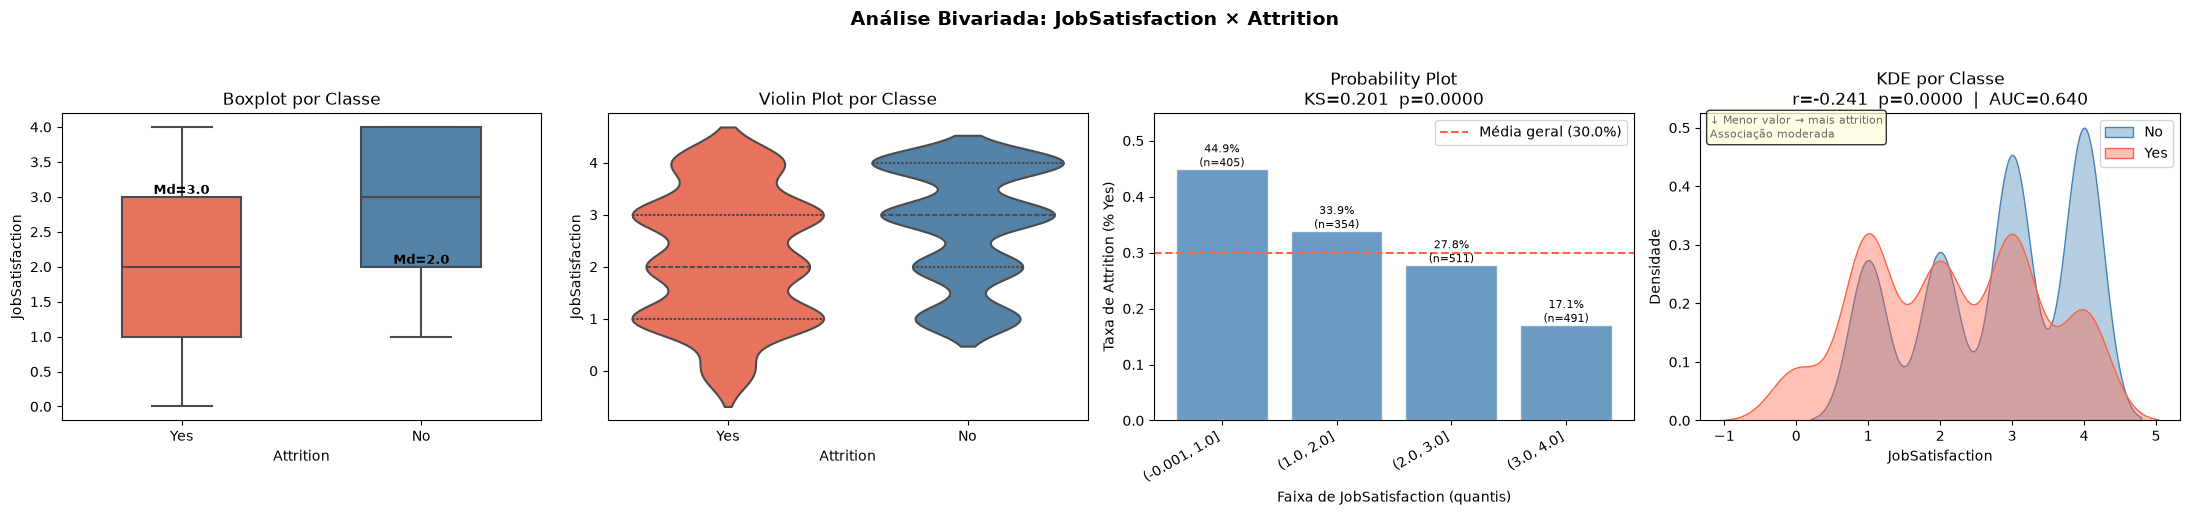

─────────────────────────────────────────────────────────────────
  JobSatisfaction
  KS=0.2013  p=0.0000  |  r=-0.2408  |  AUC=0.6401  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



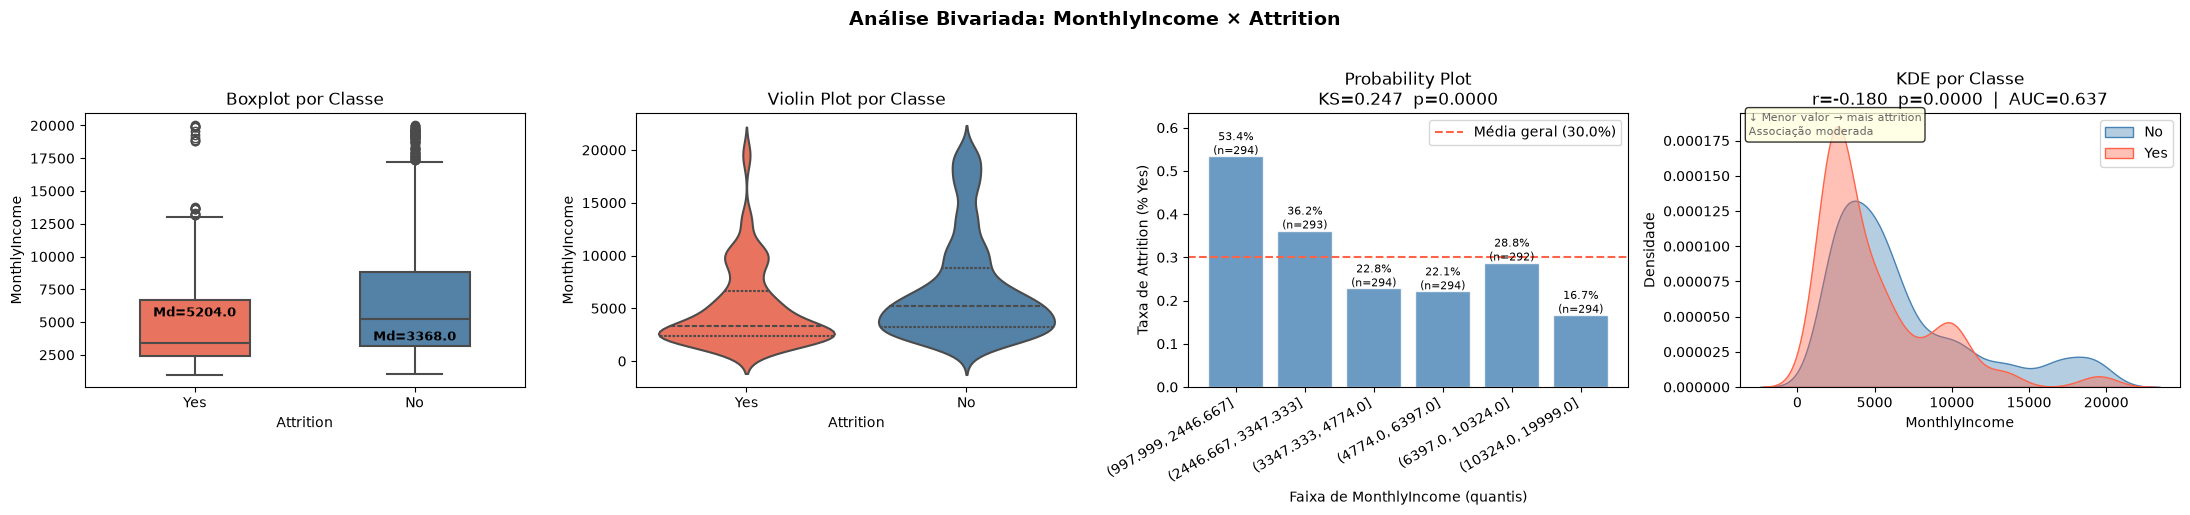

─────────────────────────────────────────────────────────────────
  MonthlyIncome
  KS=0.2472  p=0.0000  |  r=-0.1796  |  AUC=0.6373  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



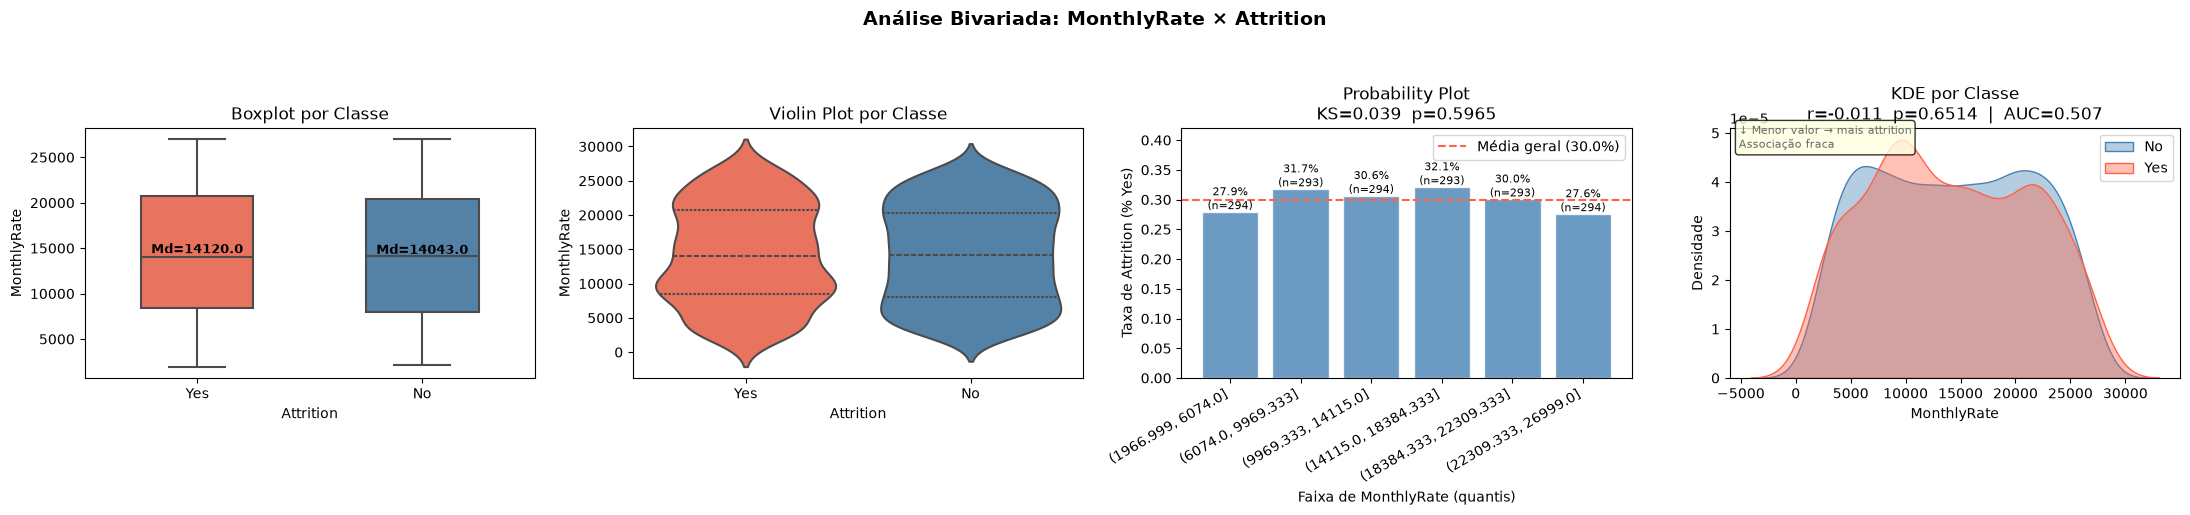

─────────────────────────────────────────────────────────────────
  MonthlyRate
  KS=0.0394  p=0.5965  |  r=-0.0108  |  AUC=0.5065  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



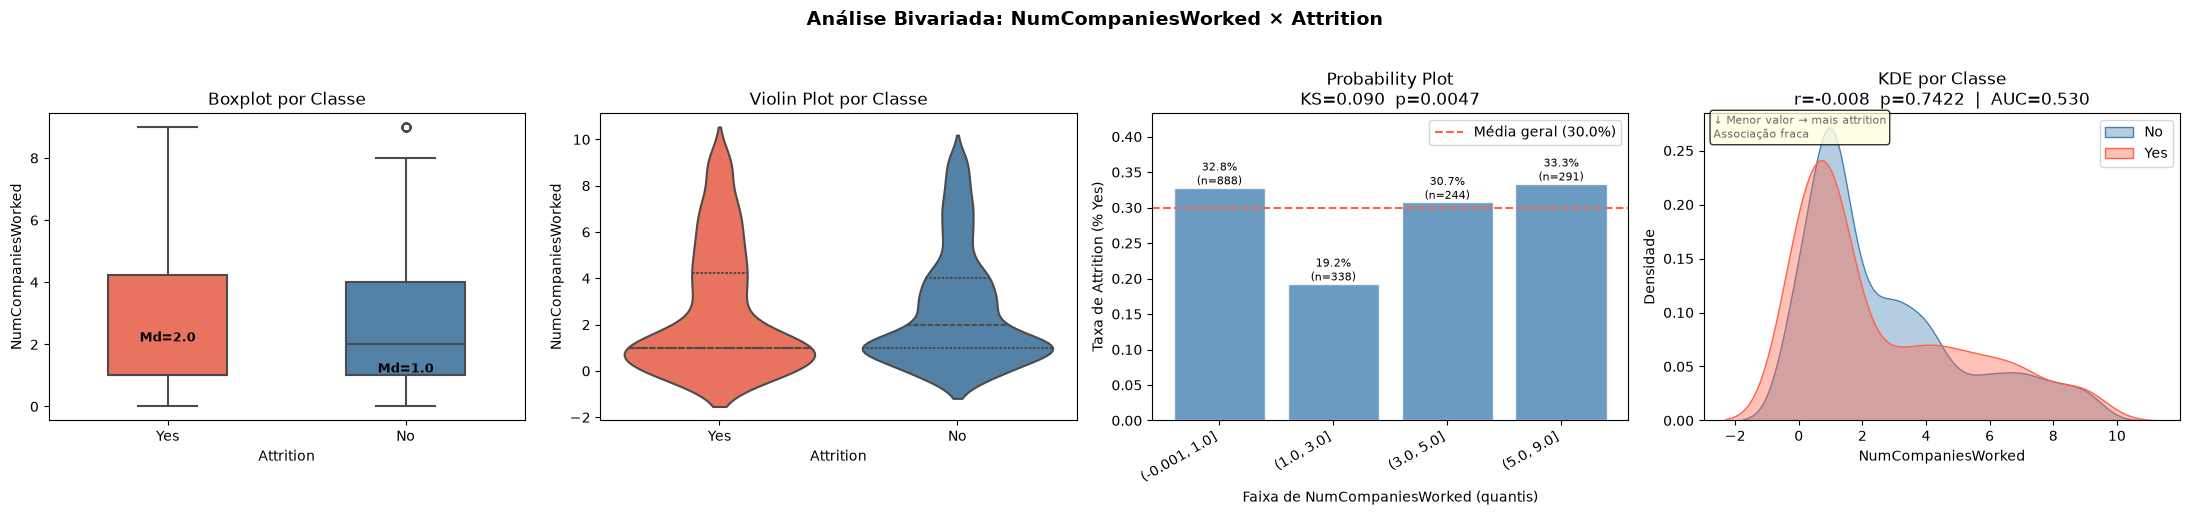

─────────────────────────────────────────────────────────────────
  NumCompaniesWorked
  KS=0.0899  p=0.0047  |  r=-0.0078  |  AUC=0.5301  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



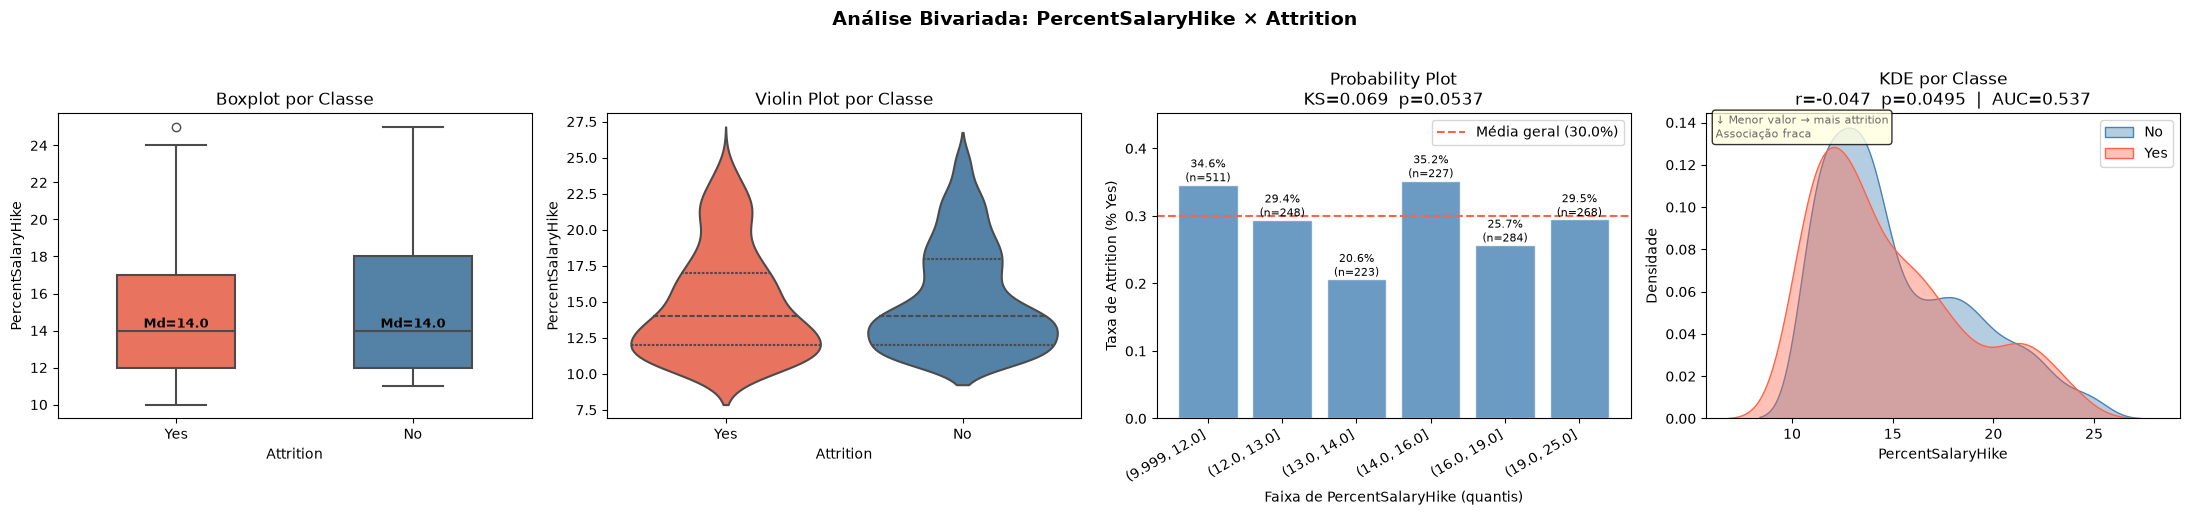

─────────────────────────────────────────────────────────────────
  PercentSalaryHike
  KS=0.0694  p=0.0537  |  r=-0.0468  |  AUC=0.5373  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



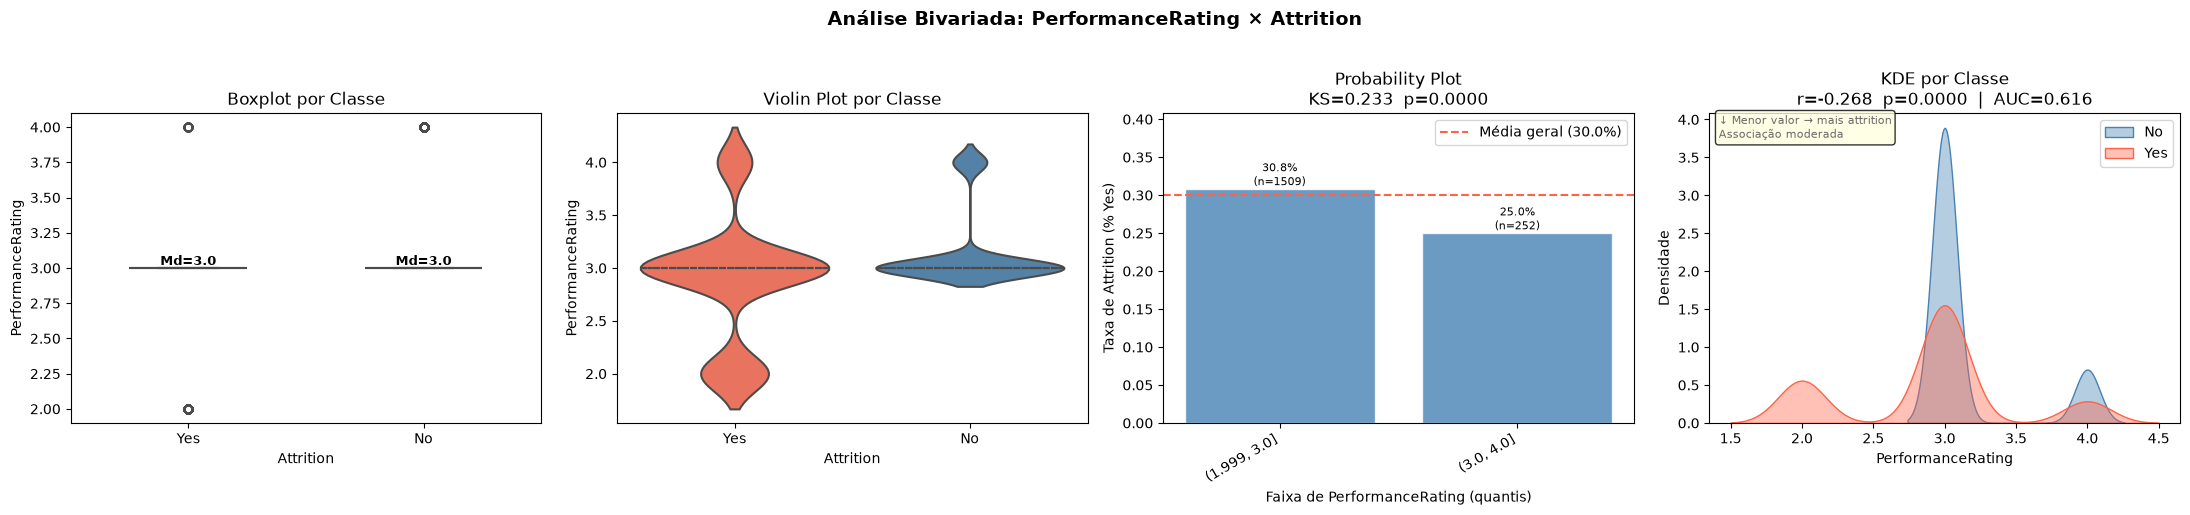

─────────────────────────────────────────────────────────────────
  PerformanceRating
  KS=0.2330  p=0.0000  |  r=-0.2684  |  AUC=0.6156  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



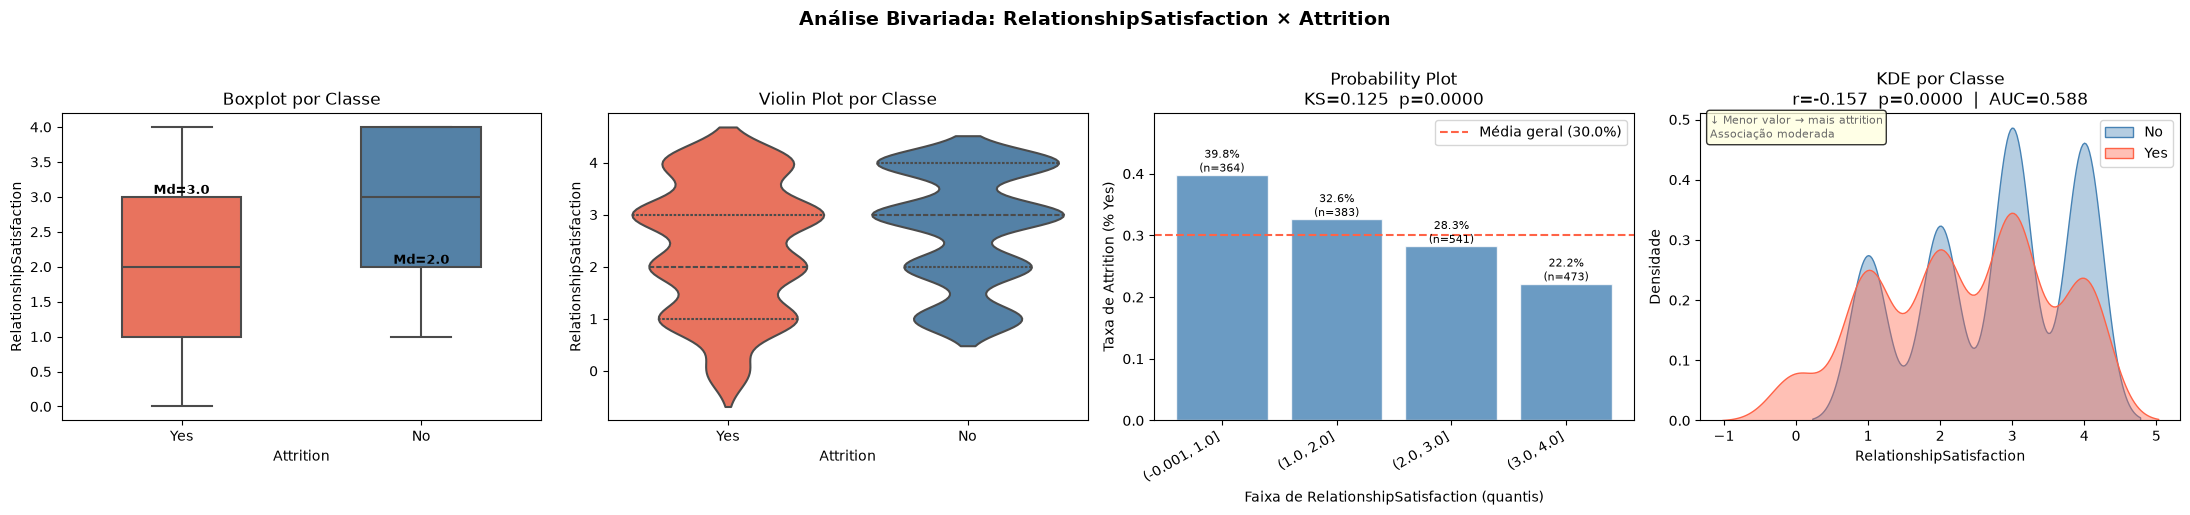

─────────────────────────────────────────────────────────────────
  RelationshipSatisfaction
  KS=0.1245  p=0.0000  |  r=-0.1571  |  AUC=0.5876  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────

⚠️ StandardHours: não foi possível calcular faixas de quantil (valores insuficientes) — pulando plot.


/home/alvaro/.pyenv/versions/3.14.2/envs/metodologiacrisp/lib/python3.14/site-packages/scipy/stats/_stats_py.py:5567: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y, axis=axis)


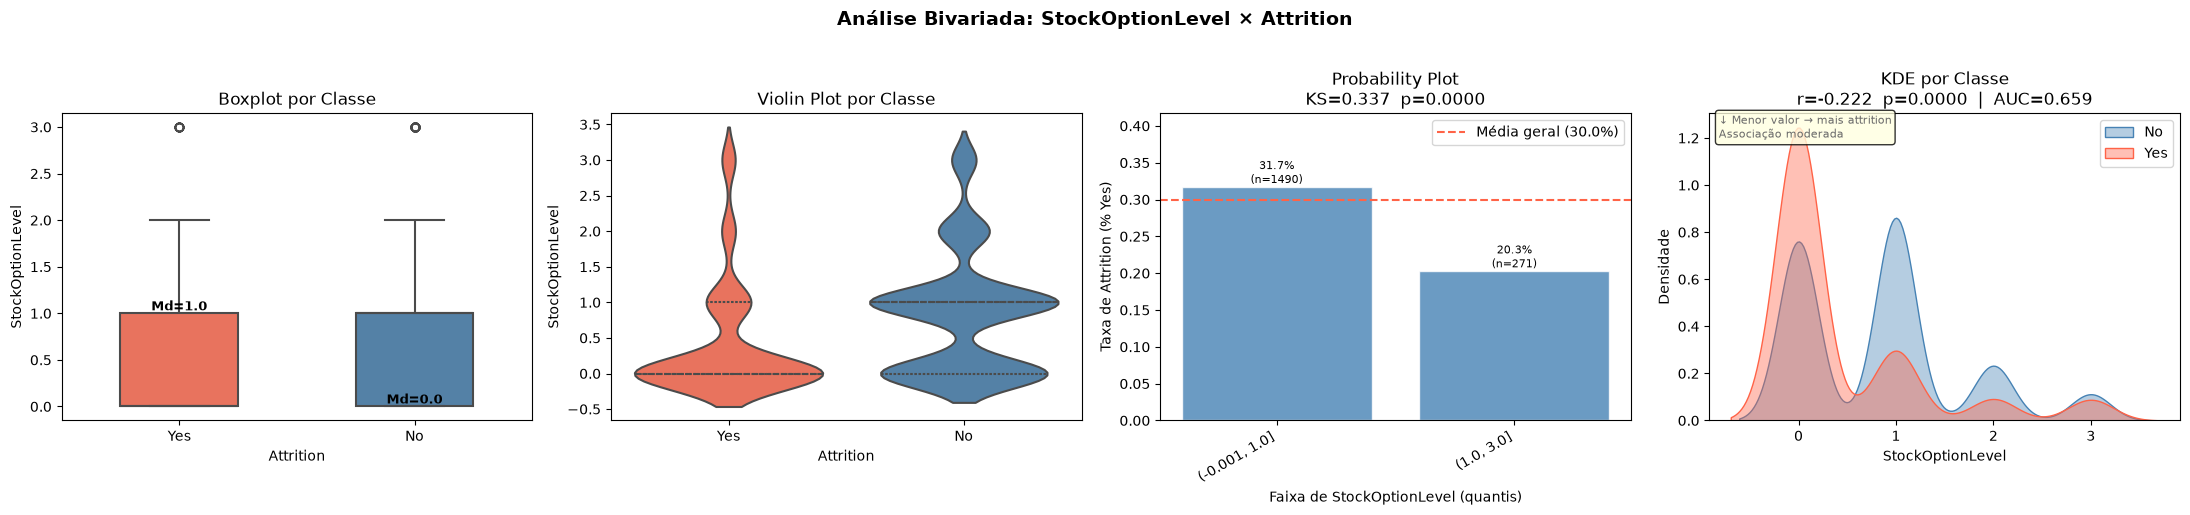

─────────────────────────────────────────────────────────────────
  StockOptionLevel
  KS=0.3366  p=0.0000  |  r=-0.2217  |  AUC=0.6591  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



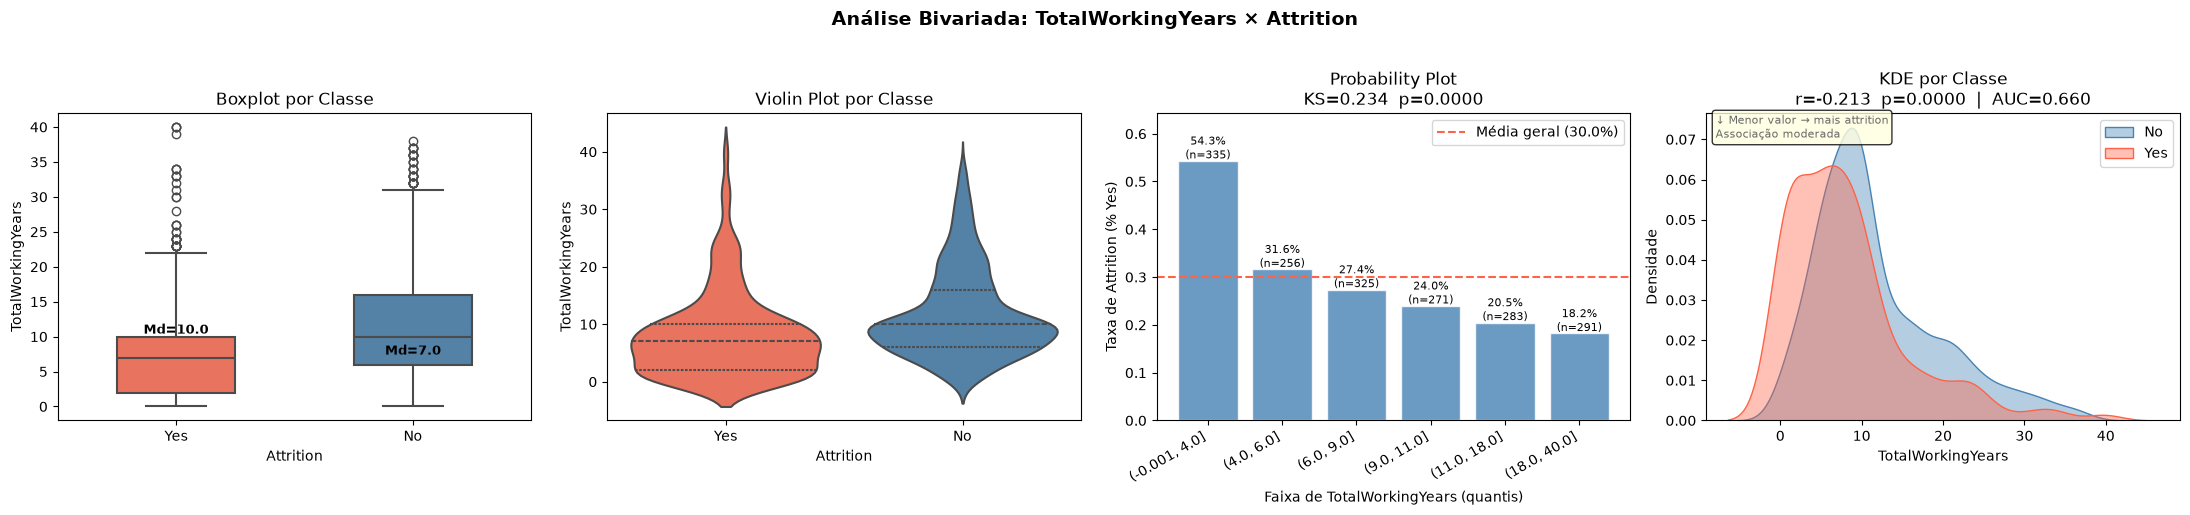

─────────────────────────────────────────────────────────────────
  TotalWorkingYears
  KS=0.2340  p=0.0000  |  r=-0.2126  |  AUC=0.6597  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



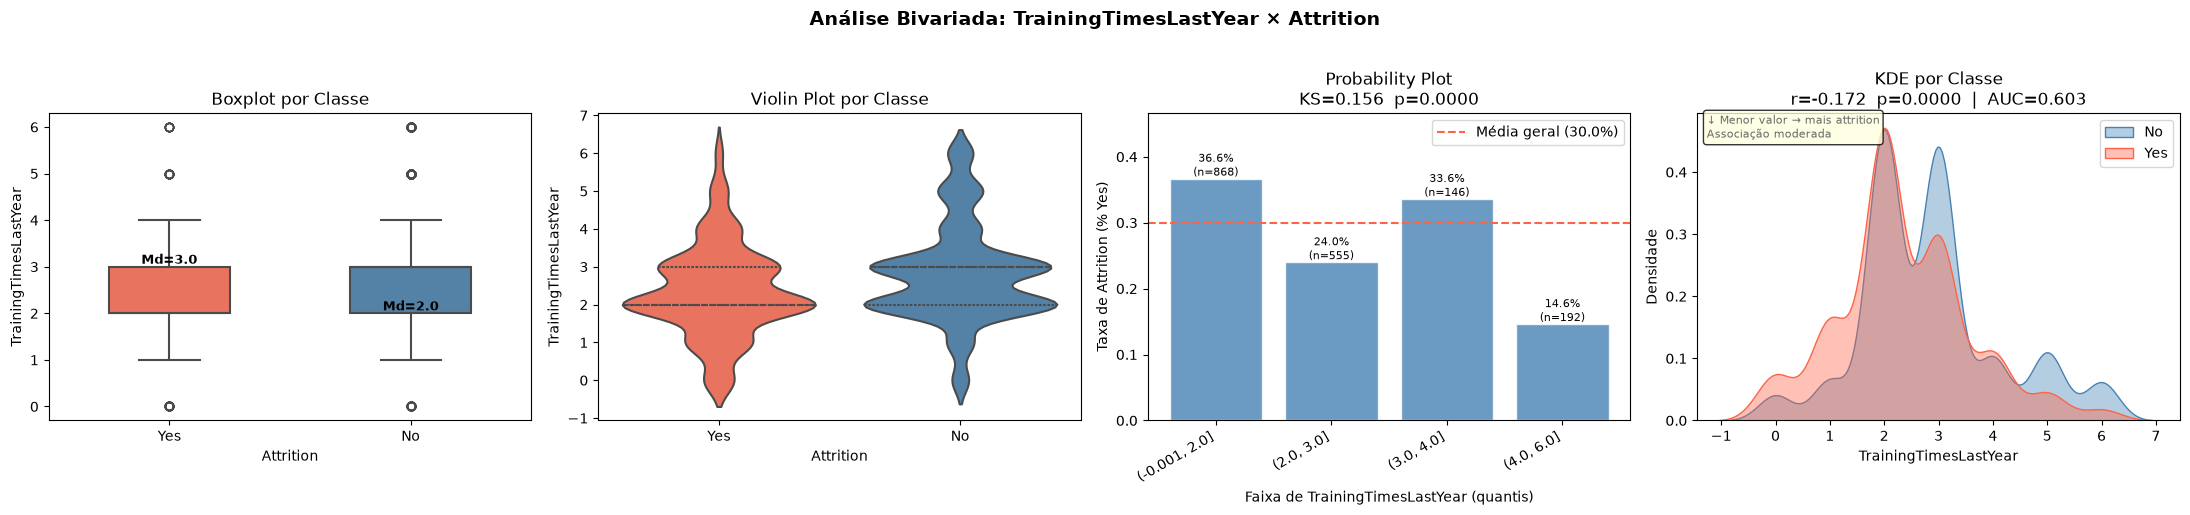

─────────────────────────────────────────────────────────────────
  TrainingTimesLastYear
  KS=0.1562  p=0.0000  |  r=-0.1716  |  AUC=0.6033  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



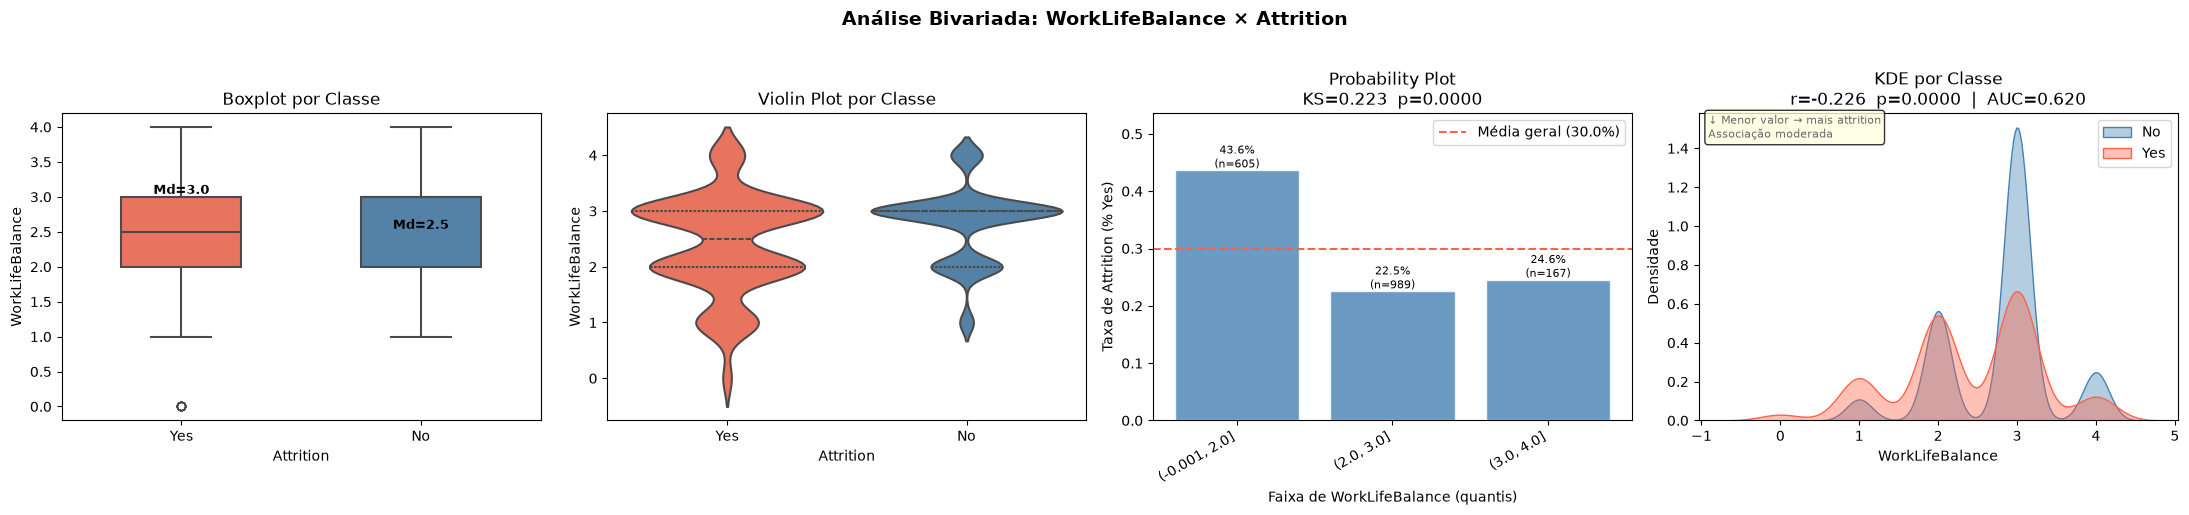

─────────────────────────────────────────────────────────────────
  WorkLifeBalance
  KS=0.2234  p=0.0000  |  r=-0.2262  |  AUC=0.6202  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



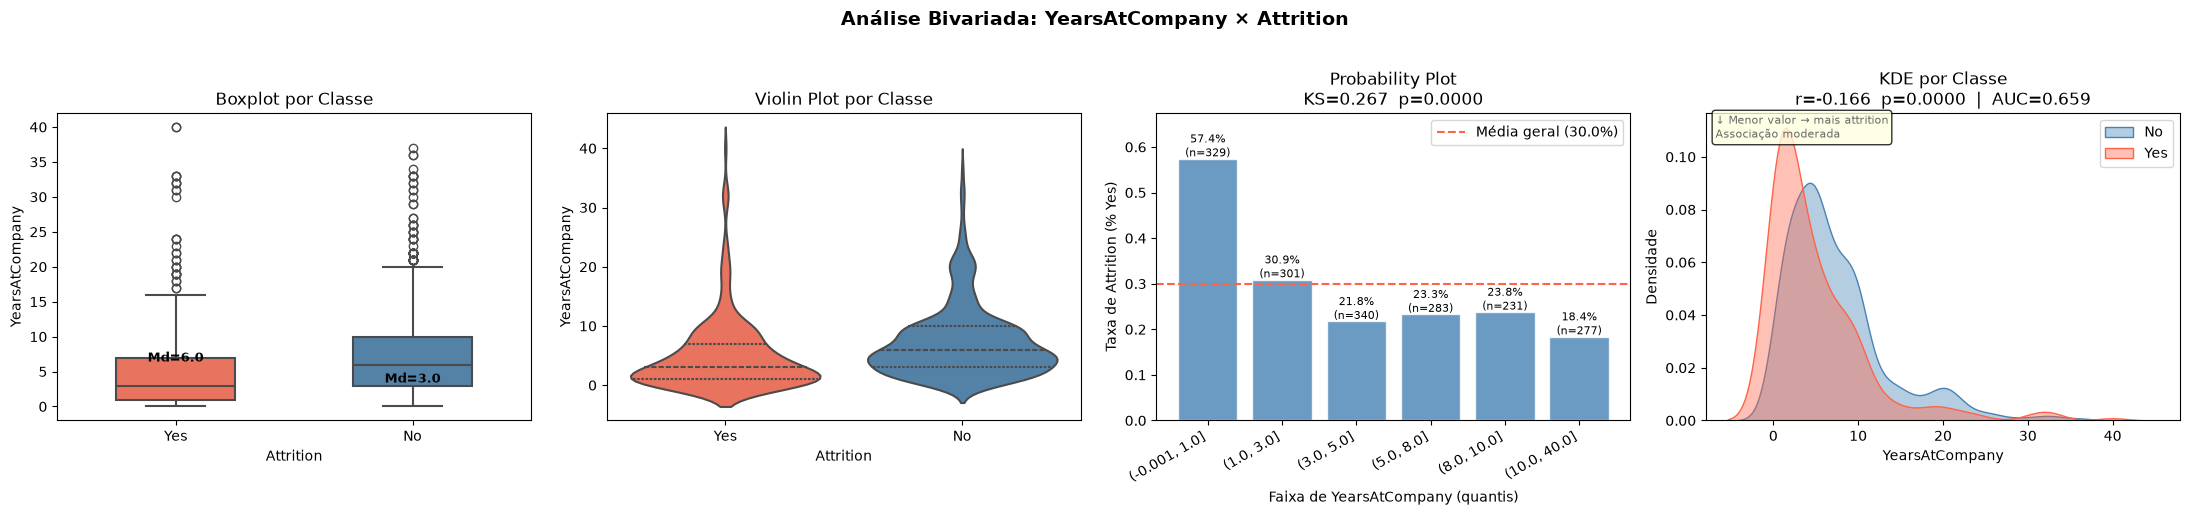

─────────────────────────────────────────────────────────────────
  YearsAtCompany
  KS=0.2675  p=0.0000  |  r=-0.1665  |  AUC=0.6590  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



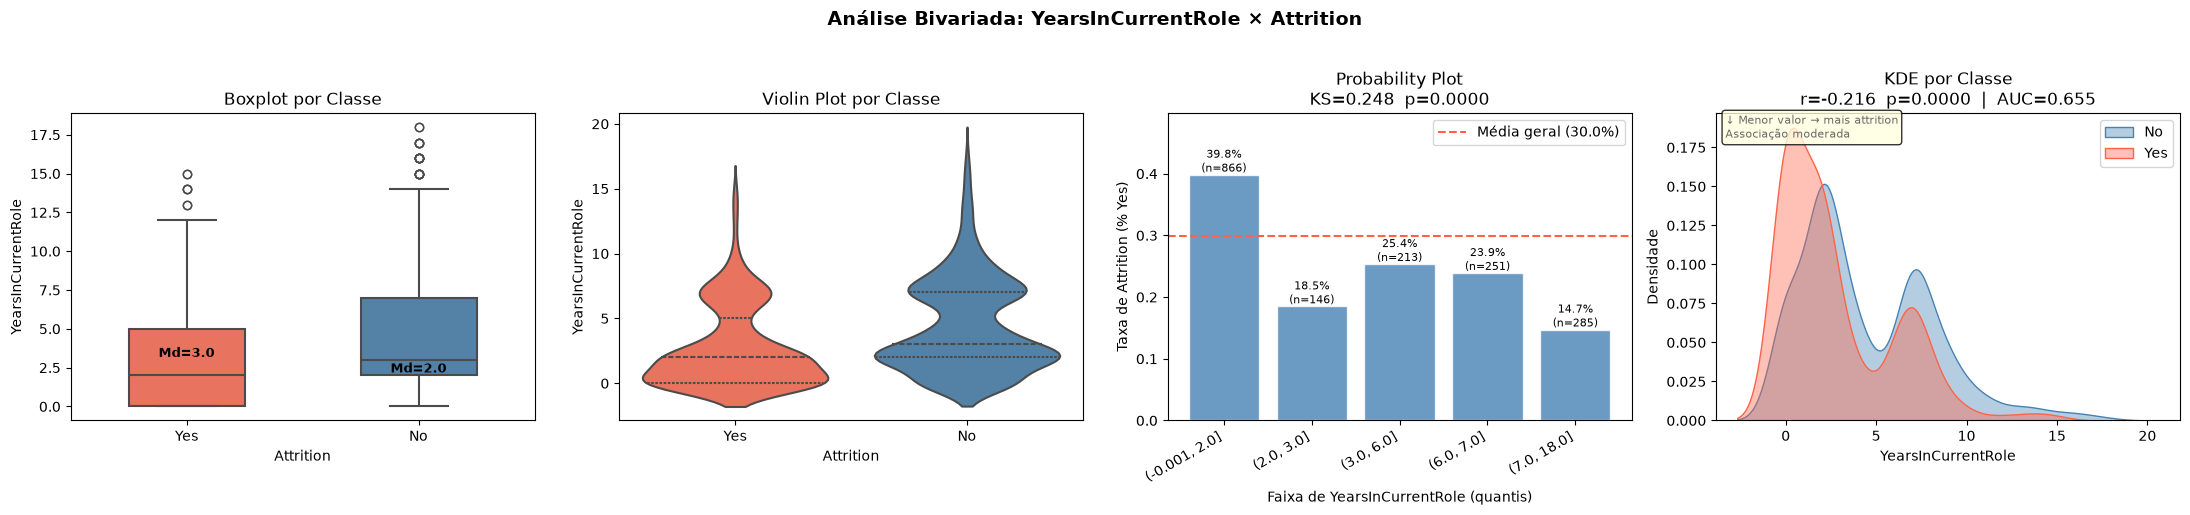

─────────────────────────────────────────────────────────────────
  YearsInCurrentRole
  KS=0.2482  p=0.0000  |  r=-0.2165  |  AUC=0.6552  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



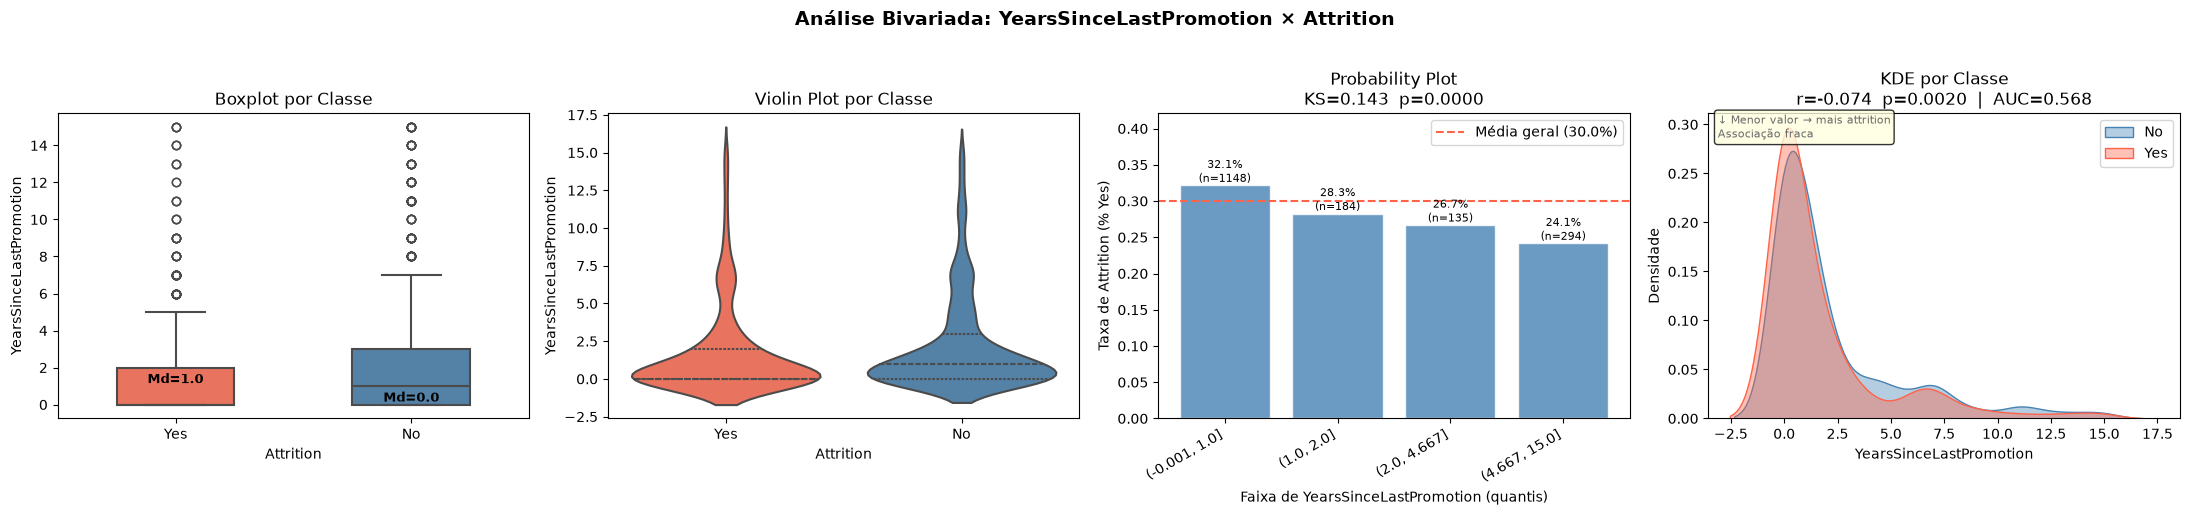

─────────────────────────────────────────────────────────────────
  YearsSinceLastPromotion
  KS=0.1426  p=0.0000  |  r=-0.0736  |  AUC=0.5685  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



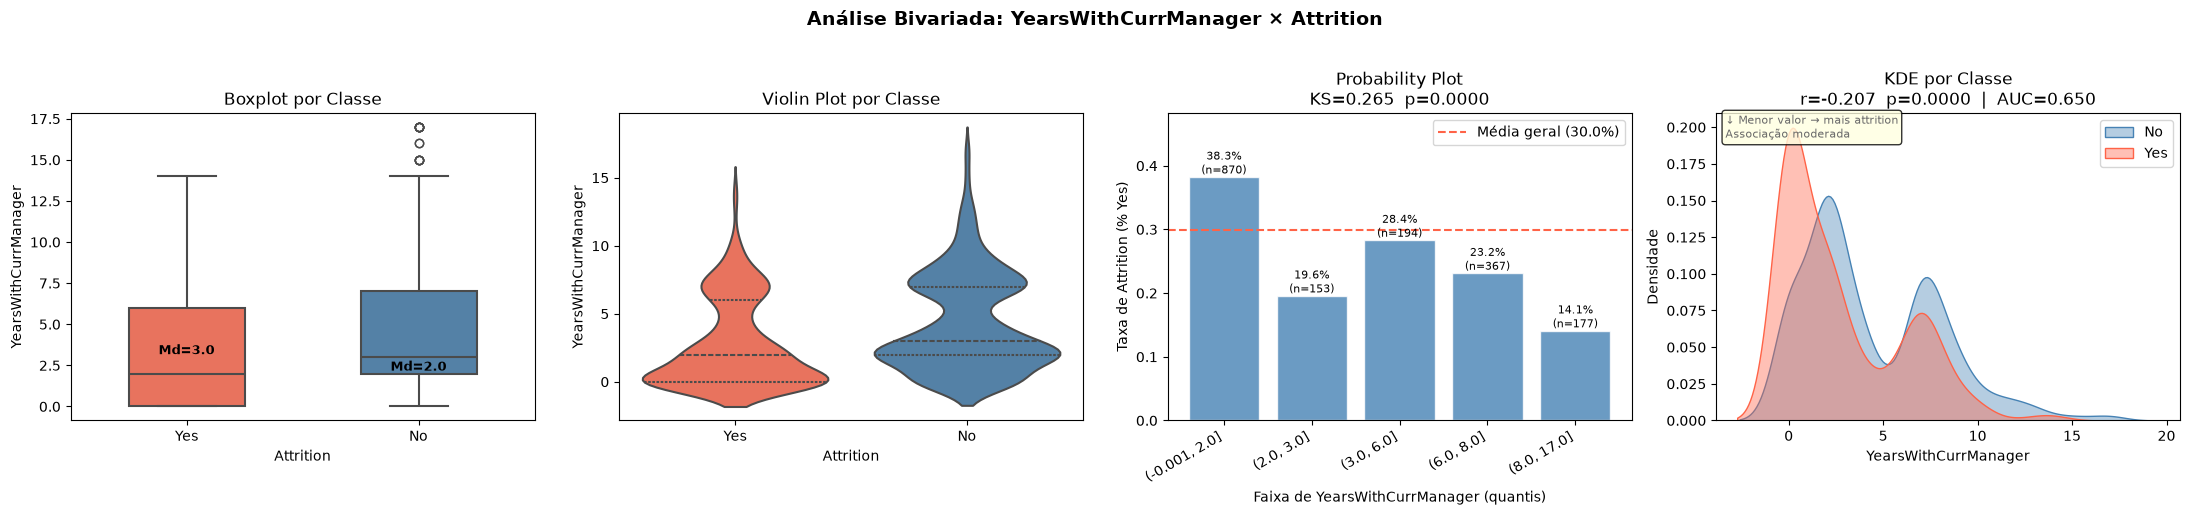

─────────────────────────────────────────────────────────────────
  YearsWithCurrManager
  KS=0.2650  p=0.0000  |  r=-0.2069  |  AUC=0.6499  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



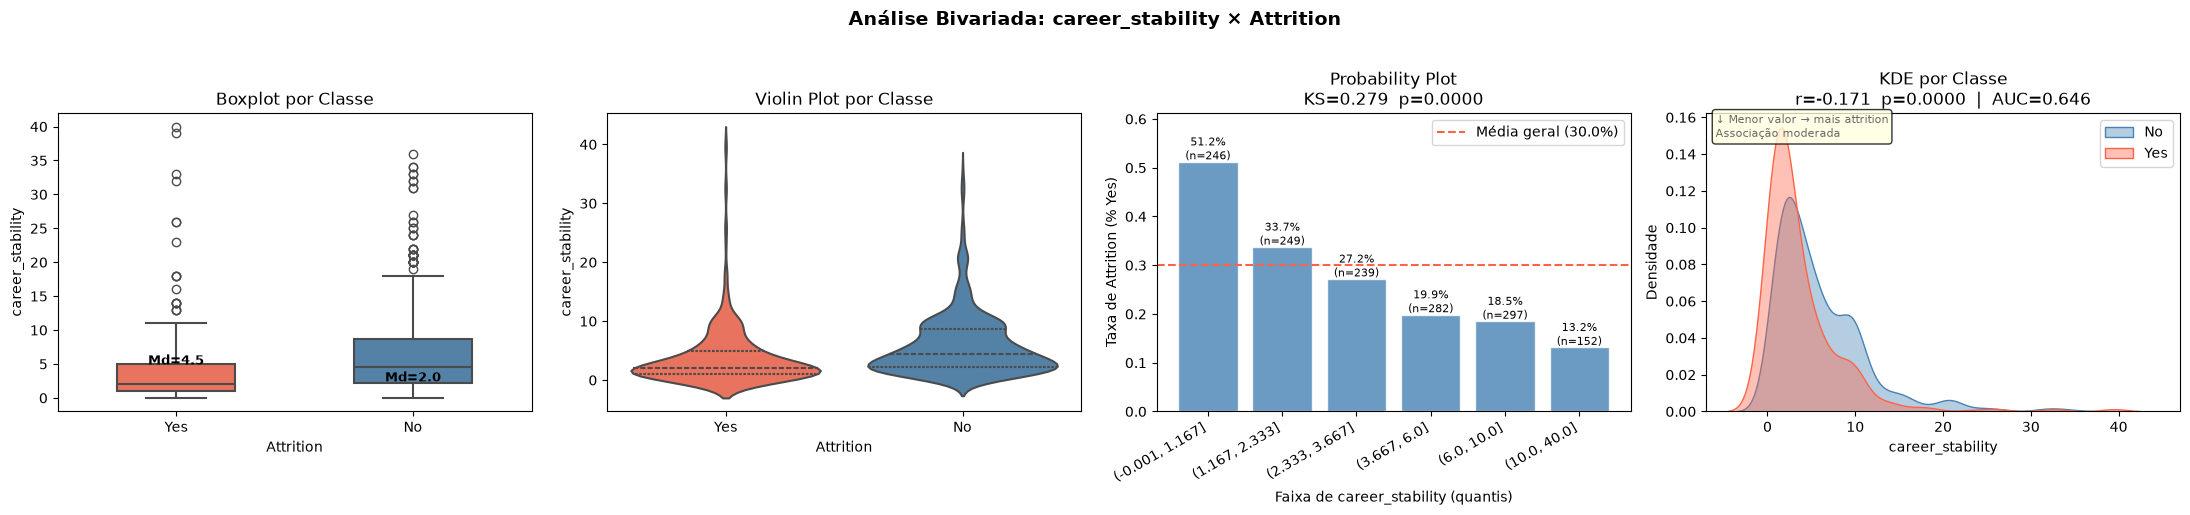

─────────────────────────────────────────────────────────────────
  career_stability
  KS=0.2787  p=0.0000  |  r=-0.1714  |  AUC=0.6461  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



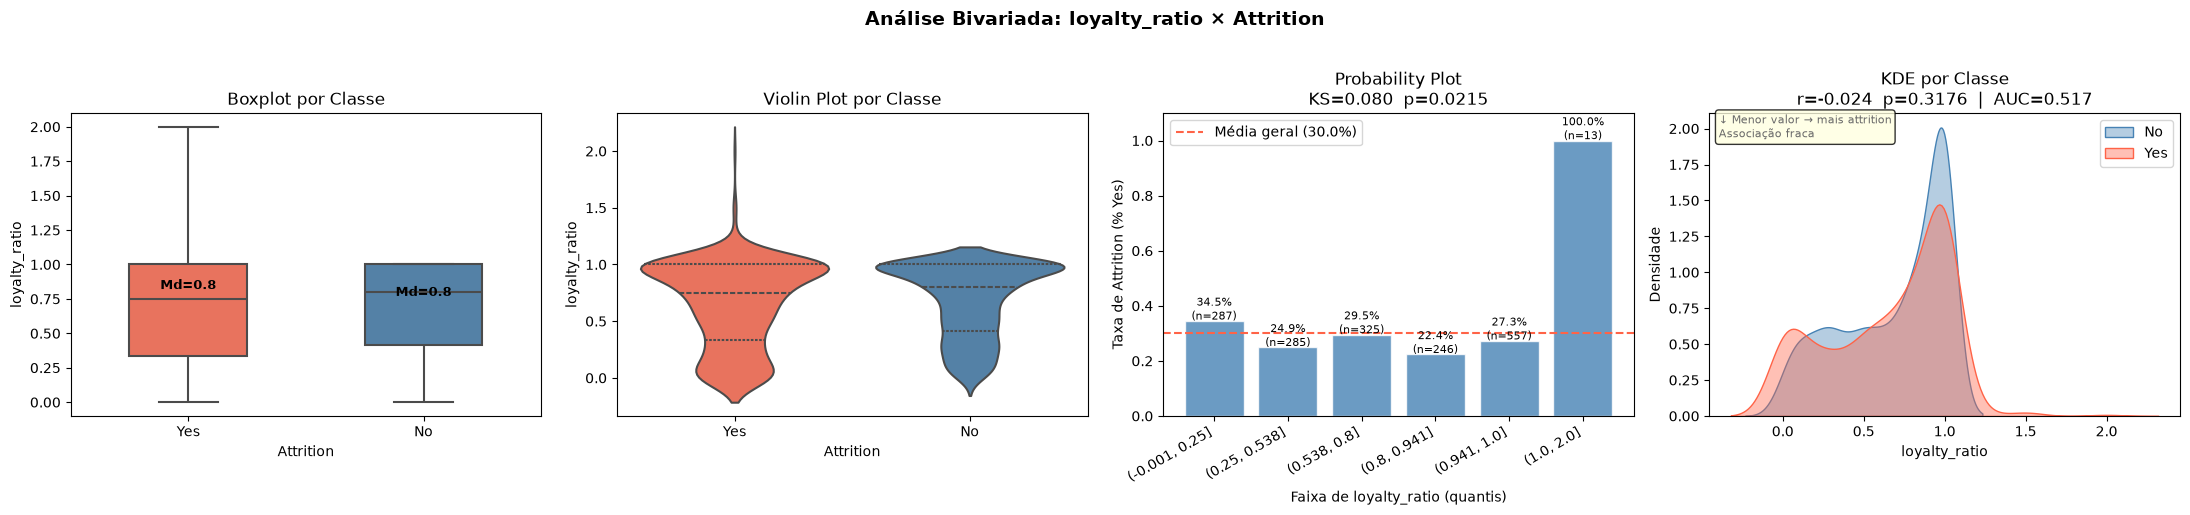

─────────────────────────────────────────────────────────────────
  loyalty_ratio
  KS=0.0801  p=0.0215  |  r=-0.0238  |  AUC=0.5166  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



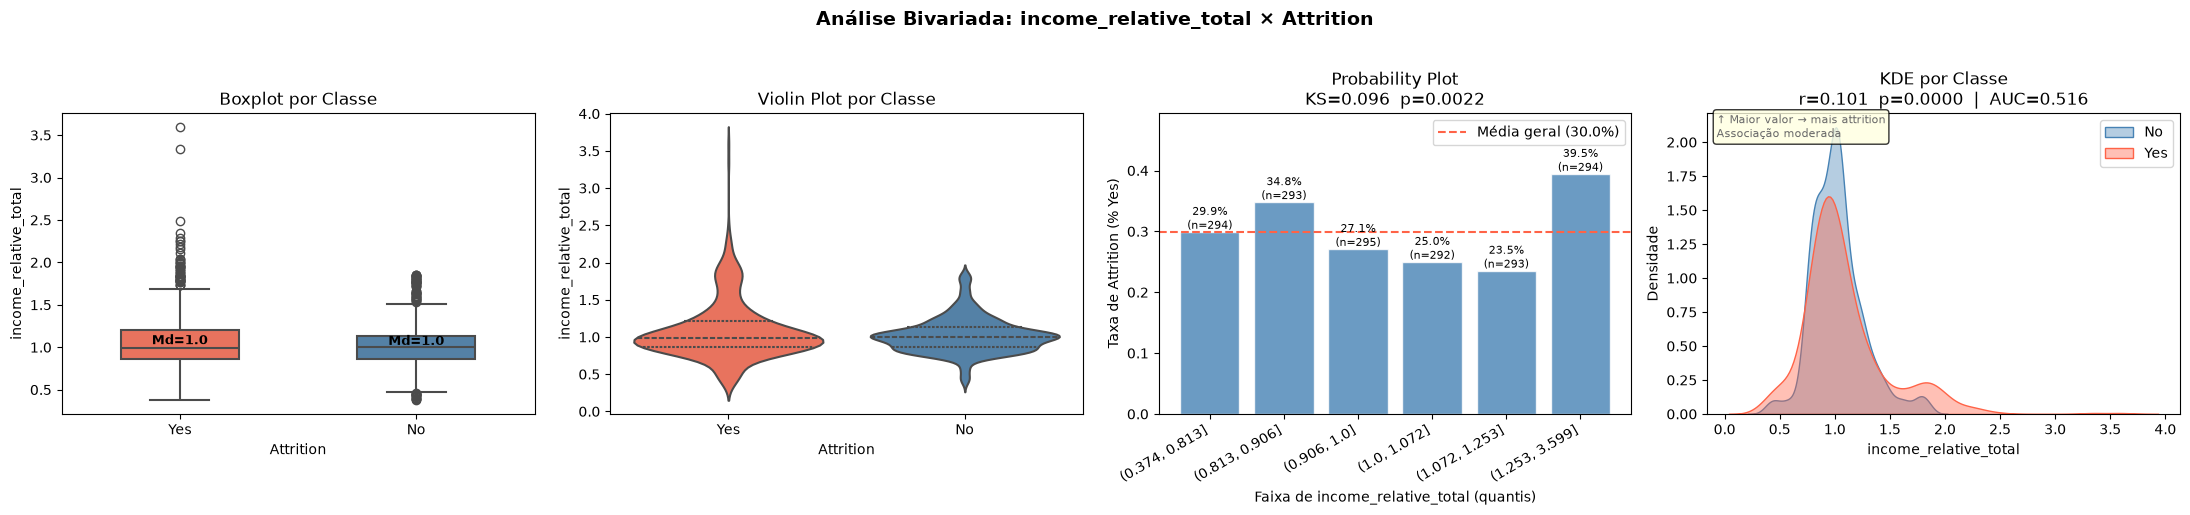

─────────────────────────────────────────────────────────────────
  income_relative_total
  KS=0.0955  p=0.0022  |  r=0.1011  |  AUC=0.5163  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



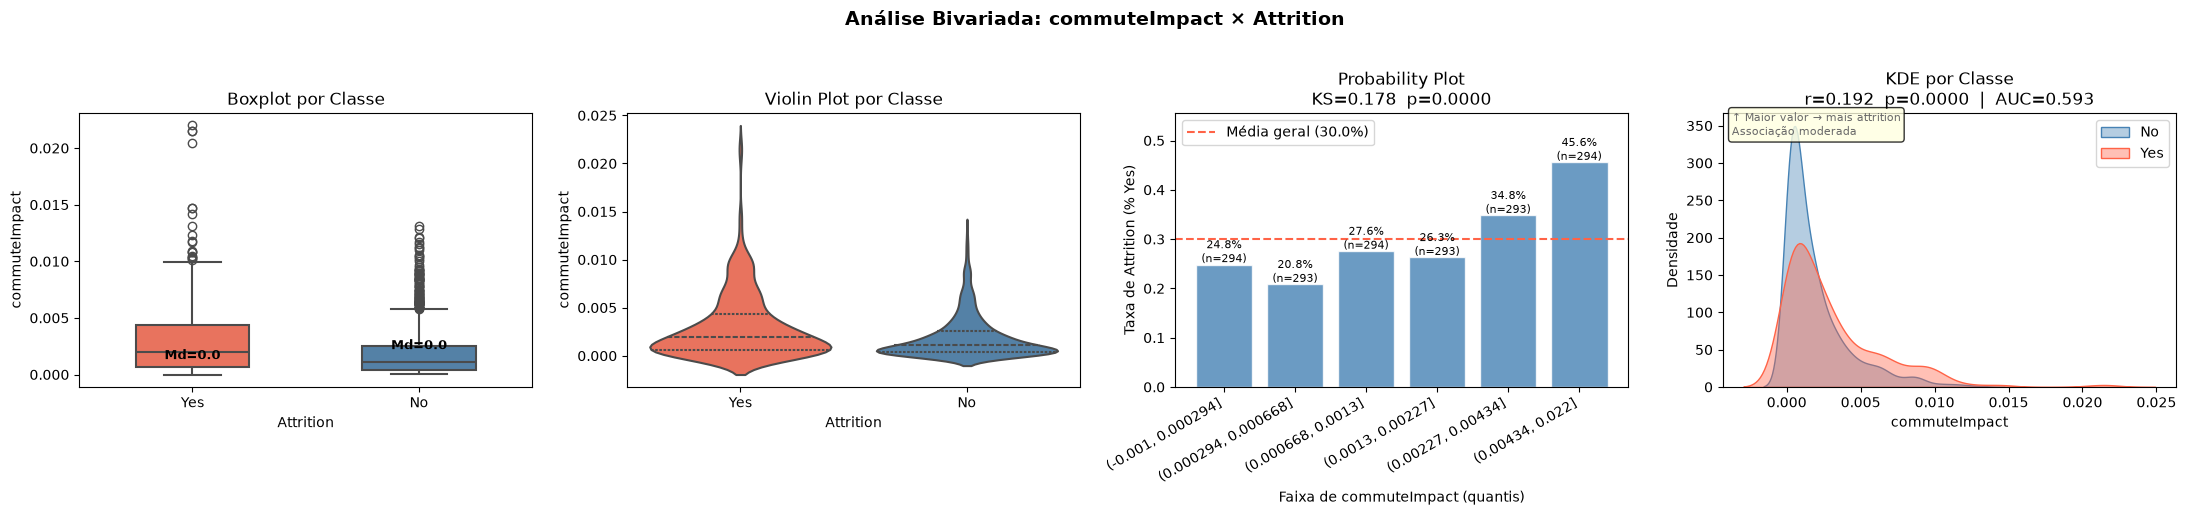

─────────────────────────────────────────────────────────────────
  commuteImpact
  KS=0.1781  p=0.0000  |  r=0.1920  |  AUC=0.5932  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



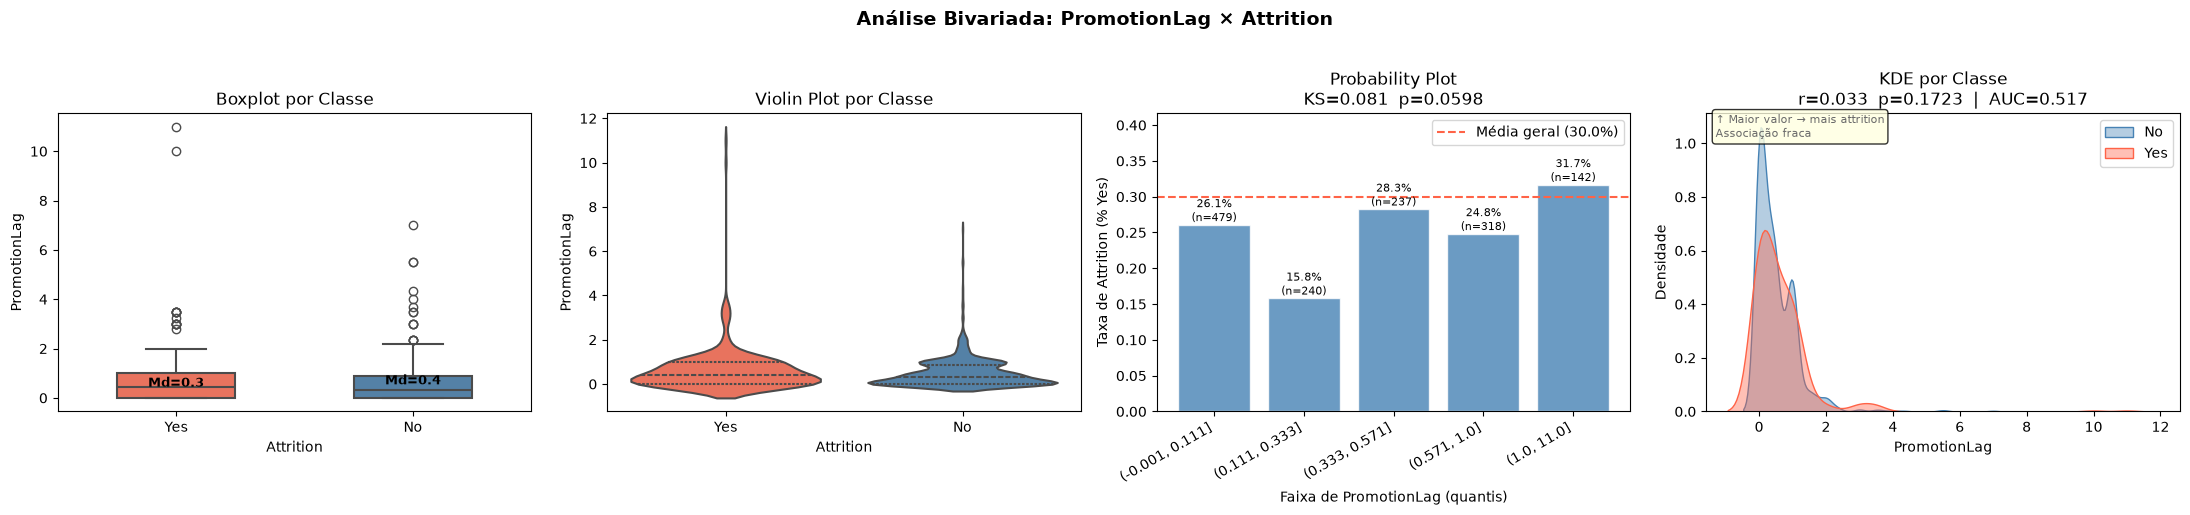

─────────────────────────────────────────────────────────────────
  PromotionLag
  KS=0.0810  p=0.0598  |  r=0.0325  |  AUC=0.5166  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



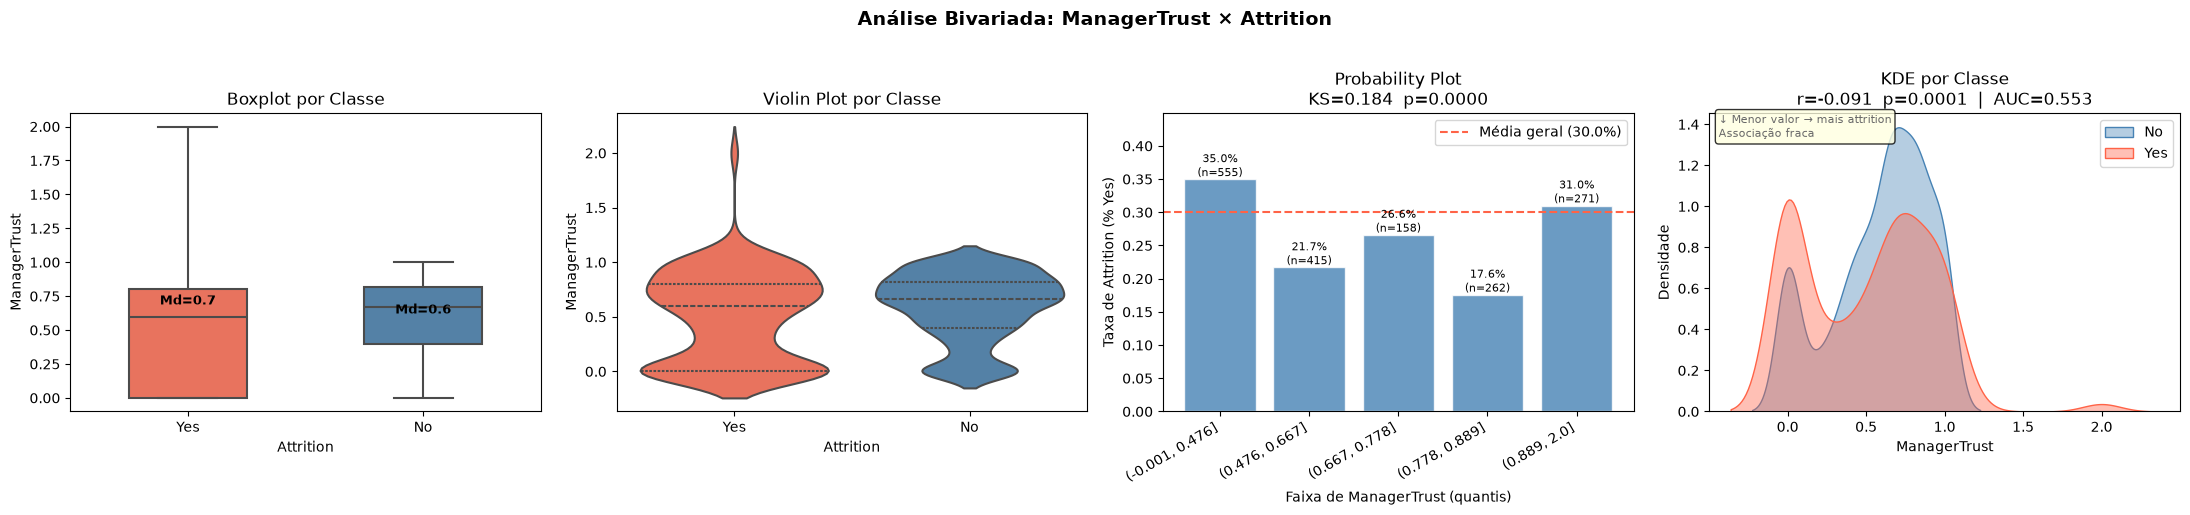

─────────────────────────────────────────────────────────────────
  ManagerTrust
  KS=0.1840  p=0.0000  |  r=-0.0906  |  AUC=0.5525  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



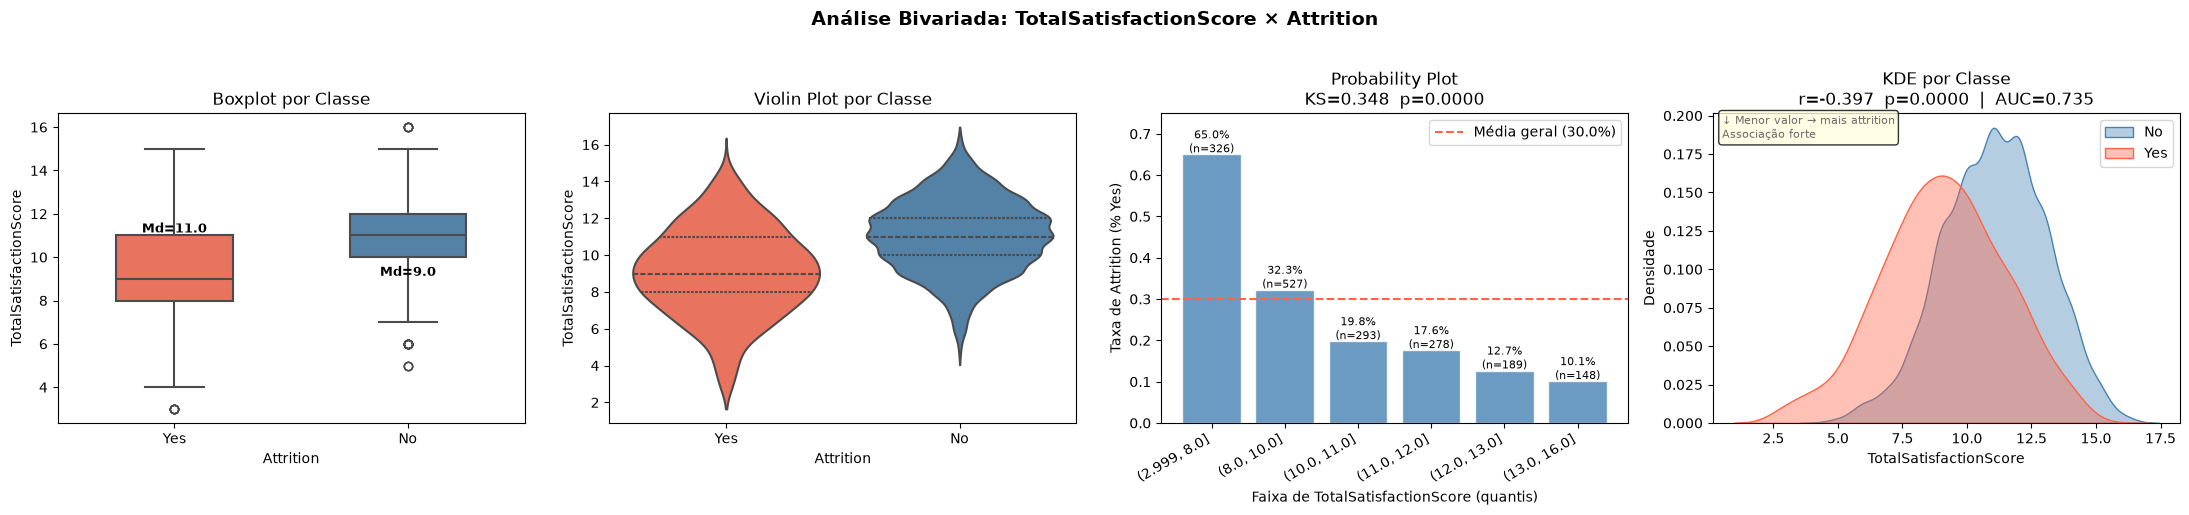

─────────────────────────────────────────────────────────────────
  TotalSatisfactionScore
  KS=0.3484  p=0.0000  |  r=-0.3972  |  AUC=0.7354  |  Discriminação: 🟢 Alta
─────────────────────────────────────────────────────────────────



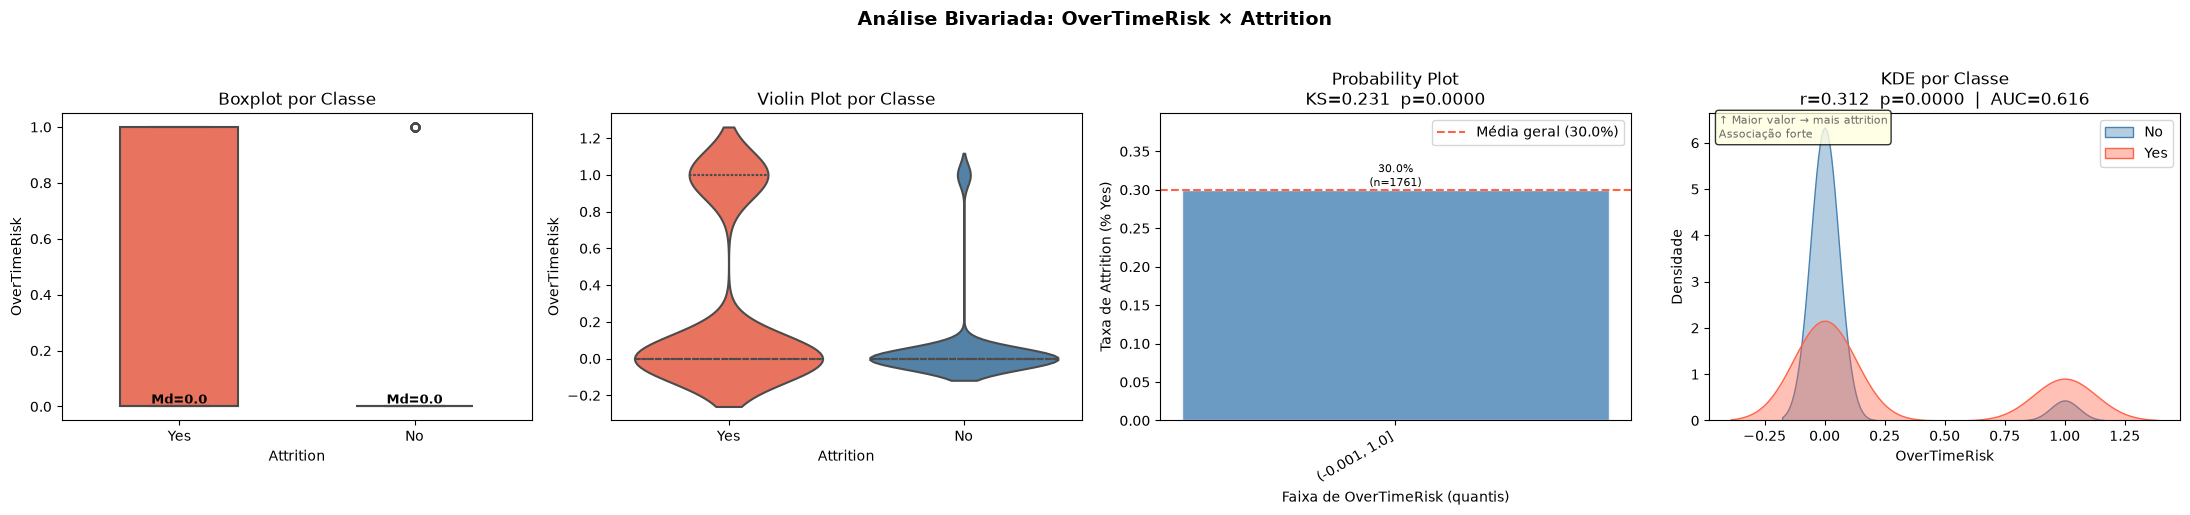

─────────────────────────────────────────────────────────────────
  OverTimeRisk
  KS=0.2314  p=0.0000  |  r=0.3118  |  AUC=0.6157  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



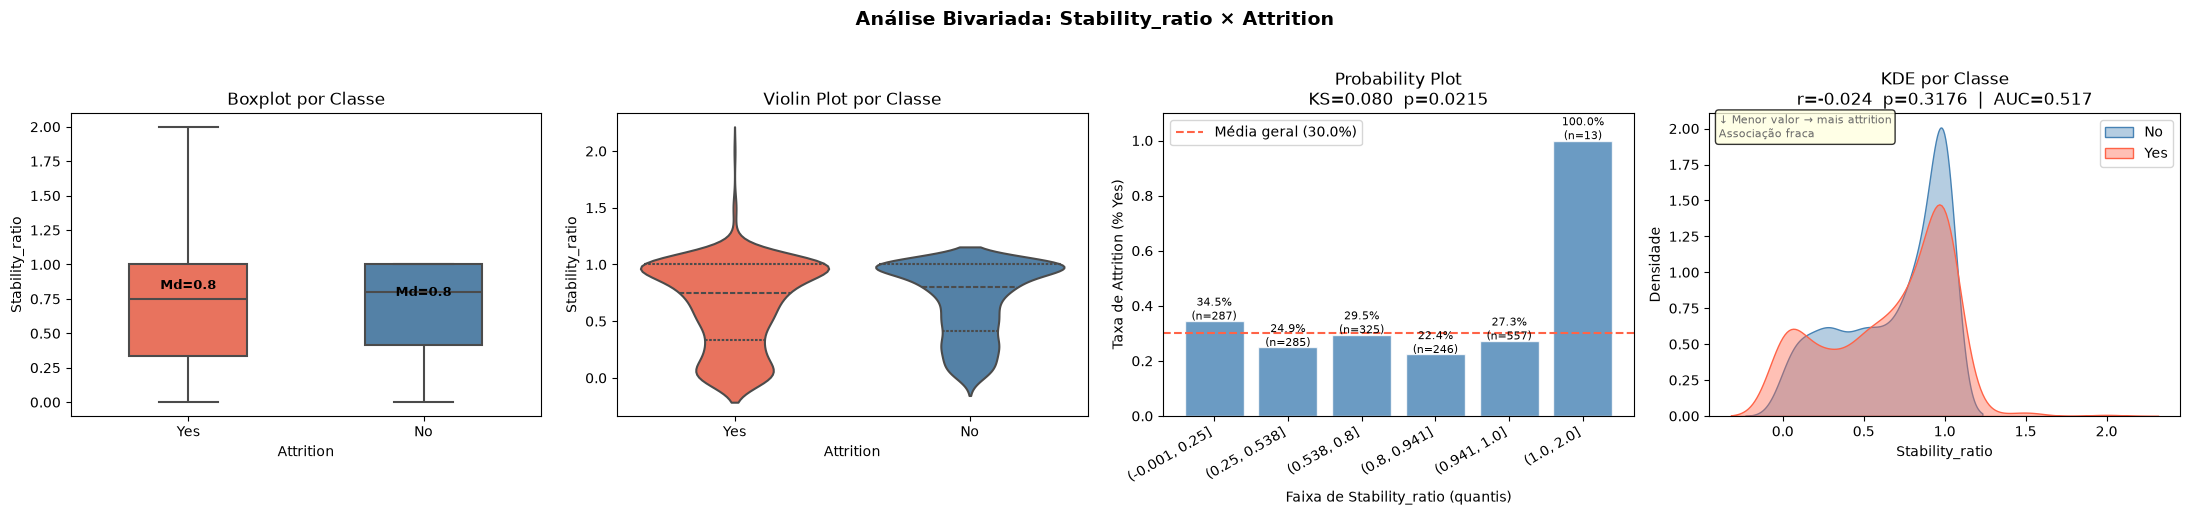

─────────────────────────────────────────────────────────────────
  Stability_ratio
  KS=0.0801  p=0.0215  |  r=-0.0238  |  AUC=0.5166  |  Discriminação: 🔴 Baixa
─────────────────────────────────────────────────────────────────



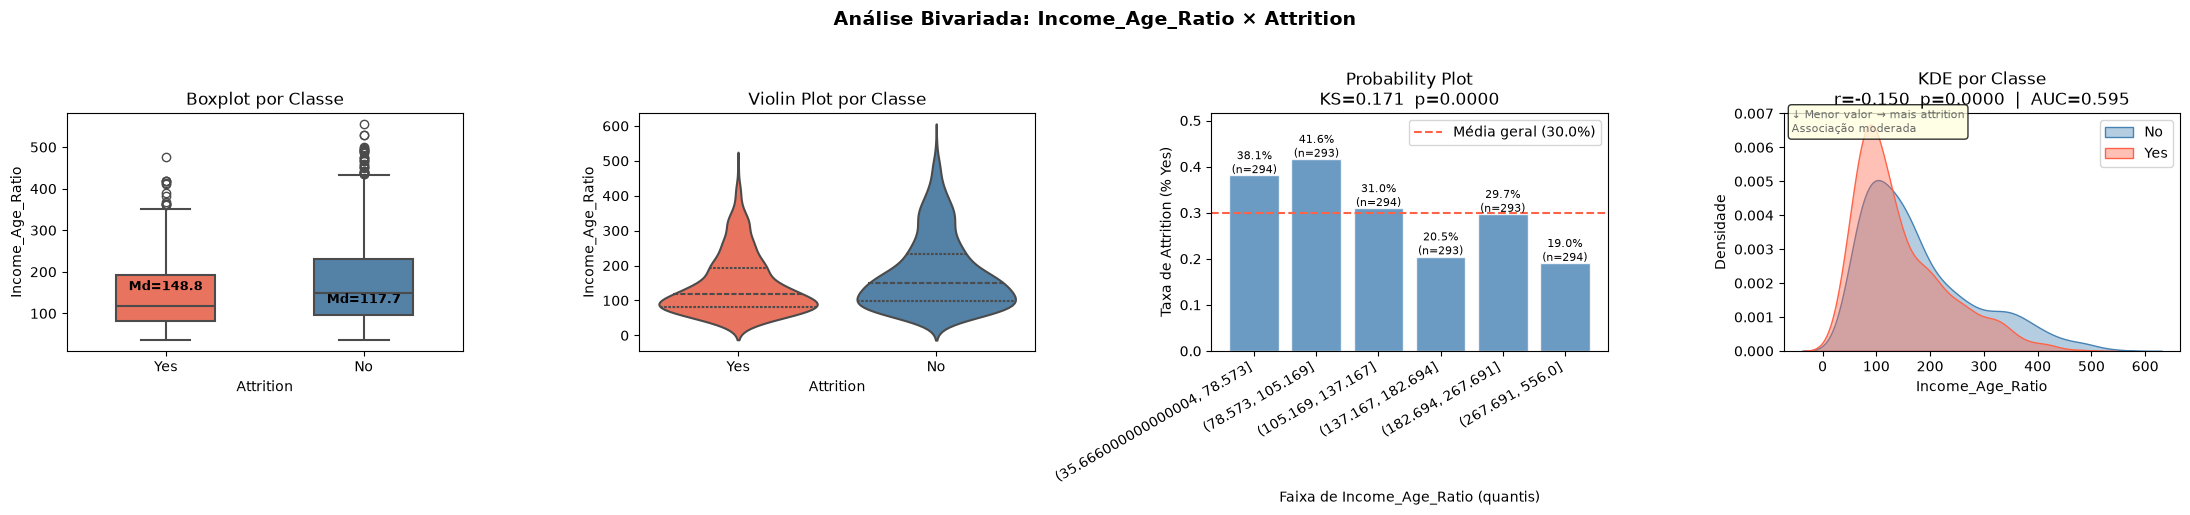

─────────────────────────────────────────────────────────────────
  Income_Age_Ratio
  KS=0.1711  p=0.0000  |  r=-0.1498  |  AUC=0.5950  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



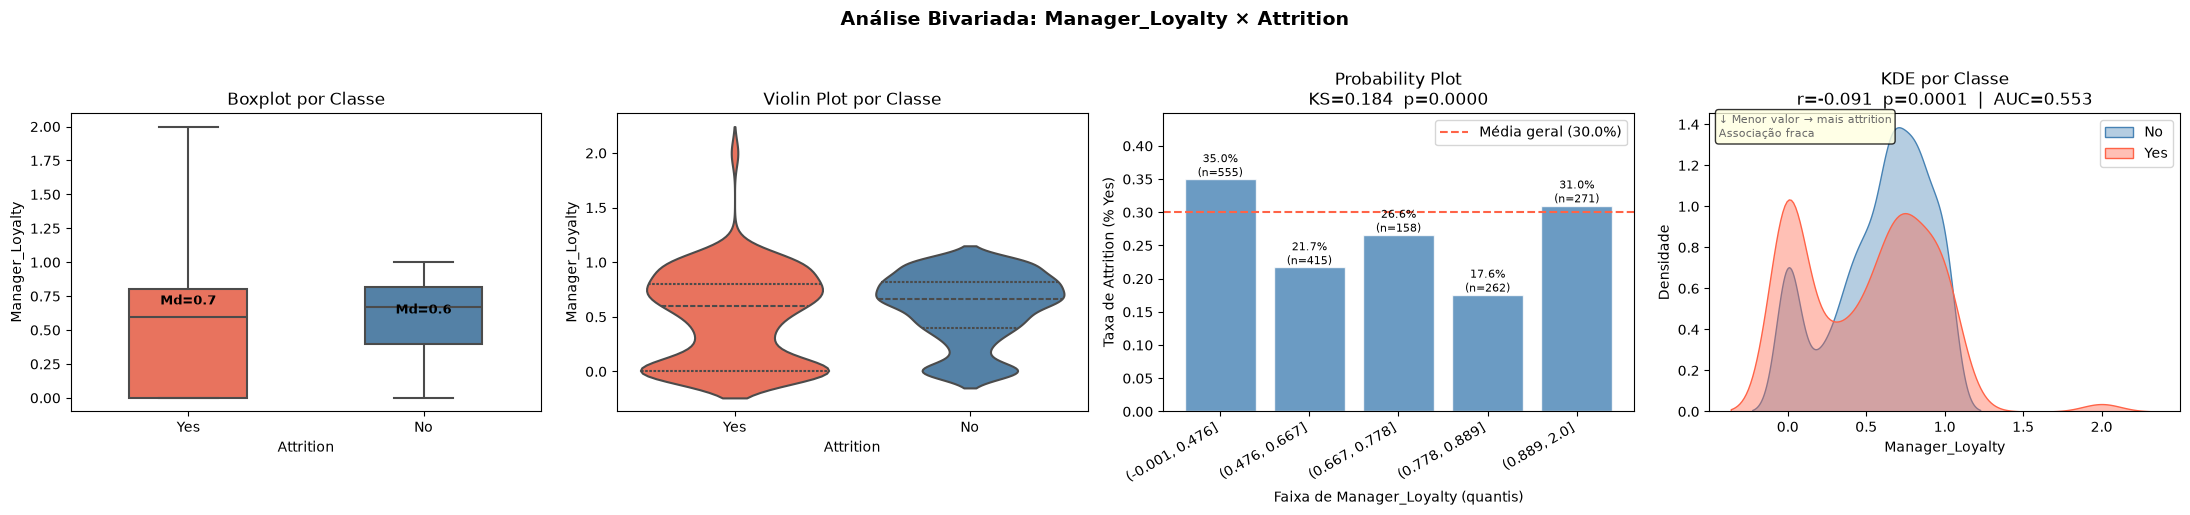

─────────────────────────────────────────────────────────────────
  Manager_Loyalty
  KS=0.1840  p=0.0000  |  r=-0.0906  |  AUC=0.5525  |  Discriminação: 🟡 Média
─────────────────────────────────────────────────────────────────



In [73]:
from scipy.stats import pointbiserialr

col_target = 'Attrition'
y_binary   = (df03[col_target] == 'Yes').astype(int)
num_cols   = df03.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    g_no  = df03.loc[df03[col_target] == 'No',  col].dropna()
    g_yes = df03.loc[df03[col_target] == 'Yes', col].dropna()

    # --- Métricas ---
    ks_stat, ks_p = stats.ks_2samp(g_no, g_yes)
    r_pb,    p_pb = pointbiserialr(y_binary, df03[col].fillna(df03[col].median()))

    X_col = df03[[col]].fillna(df03[col].median())

    model = LogisticRegression(max_iter=500).fit(X_col, y_binary)
    auc   = roc_auc_score(y_binary, model.predict_proba(X_col)[:, 1])
    auc   = max(auc, 1 - auc)

    # --- Probability Plot: faixas por quantil ---
    df_prob        = df03[[col, col_target]].copy()
    df_prob['y']   = y_binary
    taxa_geral     = y_binary.mean()

    try:
        df_prob['faixa'] = pd.qcut(df_prob[col], q=6, duplicates='drop')
    except ValueError:
        df_prob['faixa'] = pd.cut(df_prob[col], bins=6)

    prob_by_faixa = (
        df_prob.groupby('faixa', observed=True)['y']
        .agg(['mean', 'count'])
        .reset_index()
    )
    prob_by_faixa.columns = ['Faixa', 'Taxa Attrition', 'N']
    prob_by_faixa['Faixa'] = prob_by_faixa['Faixa'].astype(str)

    # --- Plots ---
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f'Análise Bivariada: {col} × {col_target}',
                 fontsize=14, fontweight='bold', y=1.02)

    # ── Plot 1: Boxplot por classe ────────────────────────────────────────
    sns.boxplot(data=df03, x=col_target, y=col, ax=axes[0],
                hue=col_target,
                palette={'No': 'steelblue', 'Yes': 'tomato'},
                width=0.5, linewidth=1.5, legend=False)

    for i, (group, label) in enumerate([(g_no, 'No'), (g_yes, 'Yes')]):
        med = group.median()
        axes[0].text(i, med, f'Md={med:.1f}',
                     ha='center', va='bottom',
                     fontsize=9, fontweight='bold', color='black')

    axes[0].set_title('Boxplot por Classe')
    axes[0].set_xlabel(col_target)
    axes[0].set_ylabel(col)

    # ── Plot 2: Violin por classe ─────────────────────────────────────────
    sns.violinplot(data=df03, x=col_target, y=col, ax=axes[1],
                   hue=col_target,
                   palette={'No': 'steelblue', 'Yes': 'tomato'},
                   inner='quartile', linewidth=1.5, legend=False)

    axes[1].set_title('Violin Plot por Classe')
    axes[1].set_xlabel(col_target)
    axes[1].set_ylabel(col)

    # ── Plot 3: Probability Plot ──────────────────────────────────────────
    bars = axes[2].bar(
        prob_by_faixa['Faixa'], prob_by_faixa['Taxa Attrition'],
        color='steelblue', alpha=0.8, edgecolor='white'
    )
    if prob_by_faixa['Taxa Attrition'].isna().all():
        print(f"⚠️ {col}: não foi possível calcular faixas de quantil (valores insuficientes) — pulando plot.")
        plt.close(fig)
        continue

    axes[2].axhline(taxa_geral, color='tomato', linestyle='--',
                    linewidth=1.5, label=f'Média geral ({taxa_geral:.1%})')

    for bar, (_, row_data) in zip(bars, prob_by_faixa.iterrows()):
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f"{row_data['Taxa Attrition']:.1%}\n(n={int(row_data['N'])})",
                     ha='center', fontsize=8, color='black')

    axes[2].set_title(f'Probability Plot\nKS={ks_stat:.3f}  p={ks_p:.4f}')
    axes[2].set_xlabel(f'Faixa de {col} (quantis)')
    axes[2].set_ylabel('Taxa de Attrition (% Yes)')
    axes[2].set_xticks(range(len(prob_by_faixa)))
    axes[2].set_xticklabels(prob_by_faixa['Faixa'], rotation=30, ha='right')
    ymax = prob_by_faixa['Taxa Attrition'].max()
    axes[2].set_ylim(0, (ymax if pd.notna(ymax) else 1.0) + 0.1)
    axes[2].legend()

    # ── Plot 4: KDE por classe + correlação ponto-biserial ────────────────
    sns.kdeplot(g_no,  ax=axes[3], label='No',  fill=True, alpha=0.4, color='steelblue')
    sns.kdeplot(g_yes, ax=axes[3], label='Yes', fill=True, alpha=0.4, color='tomato')

    direction = '↑ Maior valor → mais attrition' if r_pb > 0 else '↓ Menor valor → mais attrition'
    strength  = 'forte' if abs(r_pb) > 0.3 else 'moderada' if abs(r_pb) > 0.1 else 'fraca'

    axes[3].set_title(f'KDE por Classe\nr={r_pb:.3f}  p={p_pb:.4f}  |  AUC={auc:.3f}')
    axes[3].set_xlabel(col)
    axes[3].set_ylabel('Densidade')
    axes[3].legend()
    axes[3].text(0.02, 0.92, f'{direction}\nAssociação {strength}',
                 transform=axes[3].transAxes, fontsize=8, color='dimgray',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # --- Resumo textual ---
    discriminacao = '🟢 Alta' if auc >= 0.65 else '🟡 Média' if auc >= 0.55 else '🔴 Baixa'
    print(f"{'─'*65}")
    print(f"  {col}")
    print(f"  KS={ks_stat:.4f}  p={ks_p:.4f}  |  r={r_pb:.4f}  |  AUC={auc:.4f}  |  Discriminação: {discriminacao}")
    print(f"{'─'*65}\n")


#### Cateforical bivariate 

### Análise Bivariada Categórica × Attrition
Mesma ideia da análise numérica, mas com 3 gráficos por variável categórica:

1. **Barras de taxa de Attrition** por categoria (vermelho quando acima da média geral).
2. **Stacked Bar 100% normalizado**: mostra a composição percentual Yes/No dentro de cada categoria, facilitando comparar proporções mesmo quando as categorias têm tamanhos (n) diferentes.
3. **Heatmap de contingência**: cruza contagem absoluta e percentual num só gráfico, com AUC Univariado no título.

Note que aqui o código usa `df_raw` (dados originais, sem as features criadas) em vez de `df03` — então essa análise cobre apenas as categóricas originais do dataset, não inclui `AgeGroup` (criada em `df02`/`df03`).


/tmp/ipykernel_101455/2830147459.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols   = df_raw.select_dtypes(include=['object']).columns.tolist()


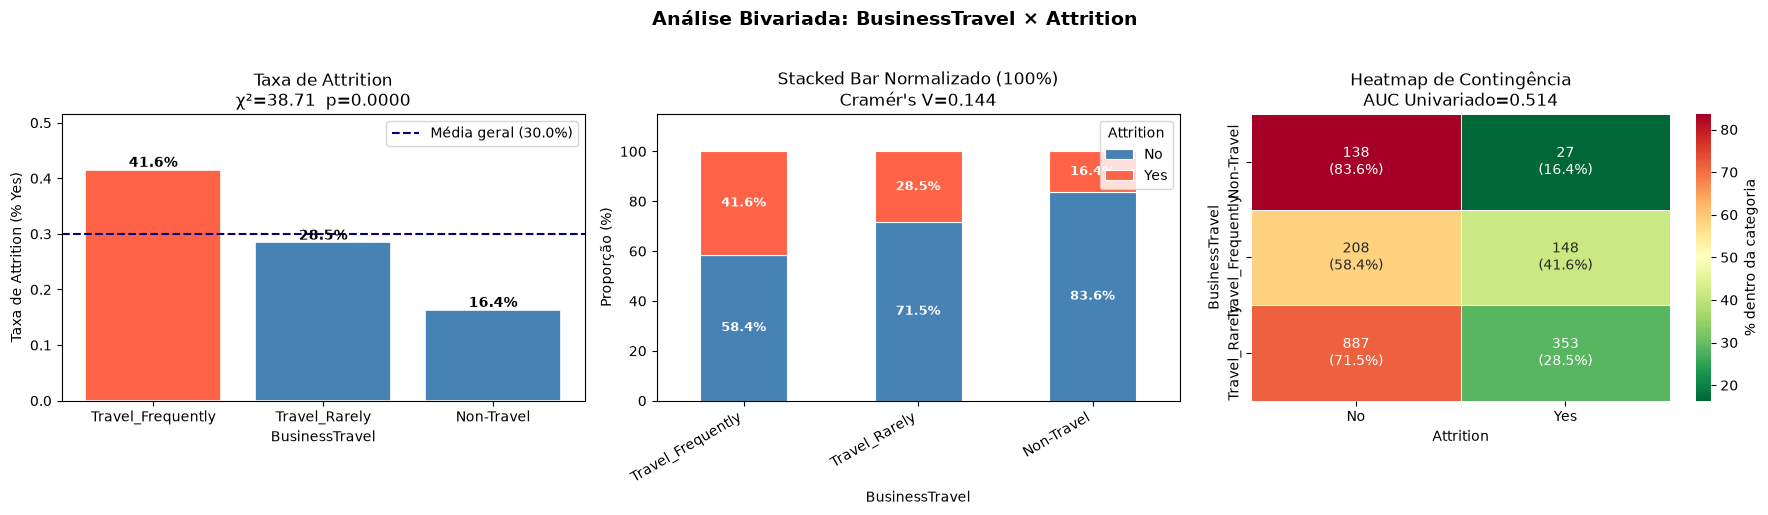

───────────────────────────────────────────────────────
  BusinessTravel
  χ²=38.71  p=0.0000  |  Cramér's V=0.1444  |  AUC=0.5140  |  Discriminação: 🔴 Baixa
───────────────────────────────────────────────────────



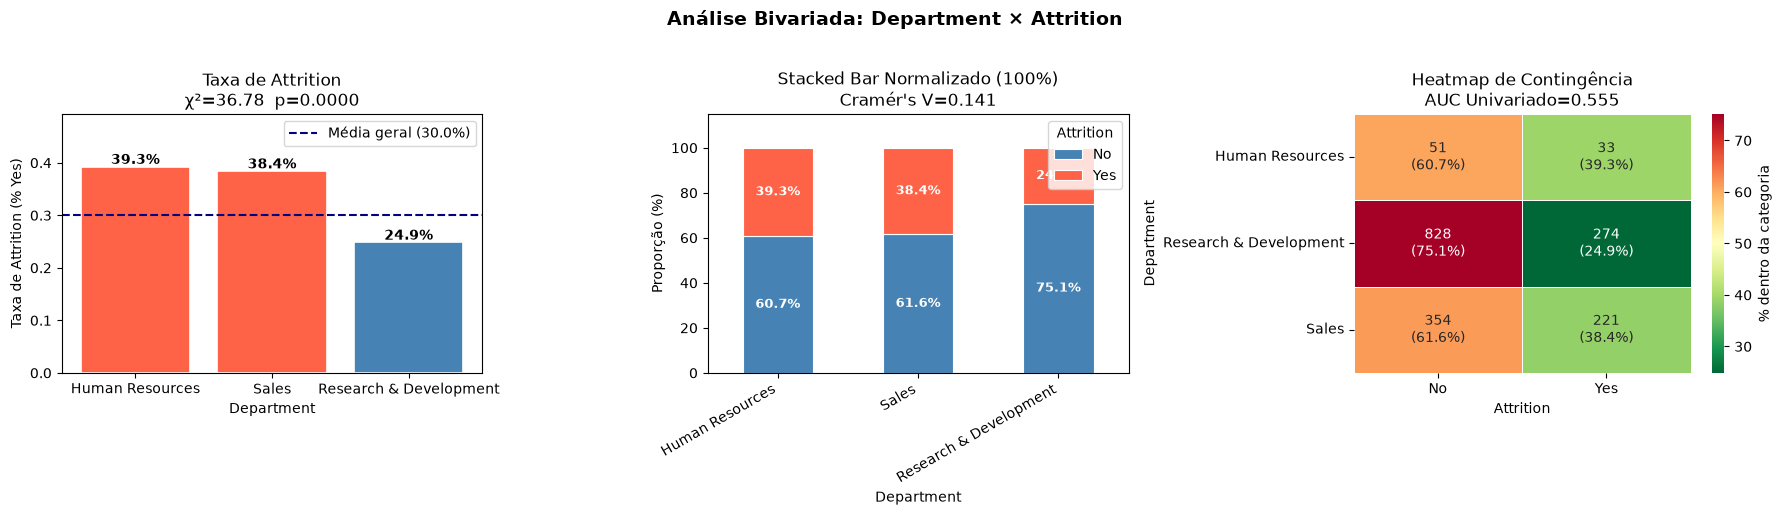

───────────────────────────────────────────────────────
  Department
  χ²=36.78  p=0.0000  |  Cramér's V=0.1406  |  AUC=0.5555  |  Discriminação: 🟡 Média
───────────────────────────────────────────────────────



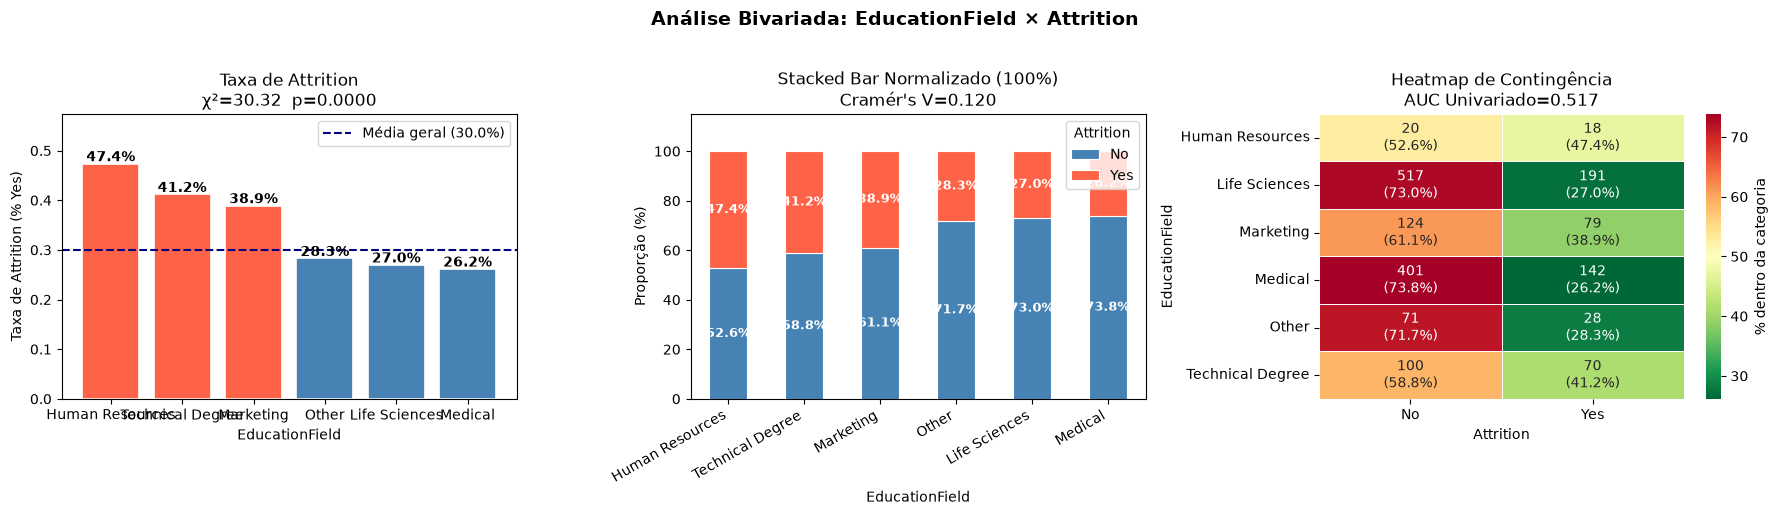

───────────────────────────────────────────────────────
  EducationField
  χ²=30.32  p=0.0000  |  Cramér's V=0.1199  |  AUC=0.5170  |  Discriminação: 🔴 Baixa
───────────────────────────────────────────────────────



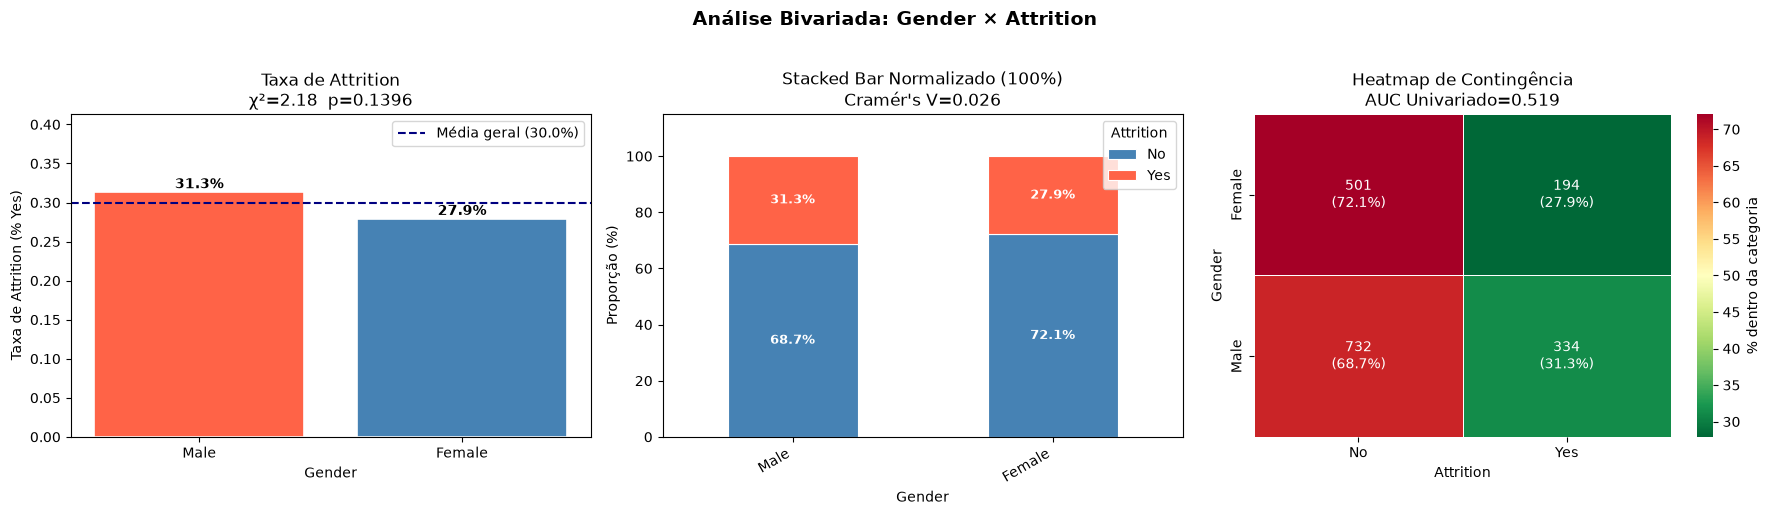

───────────────────────────────────────────────────────
  Gender
  χ²=2.18  p=0.1396  |  Cramér's V=0.0259  |  AUC=0.5195  |  Discriminação: 🔴 Baixa
───────────────────────────────────────────────────────



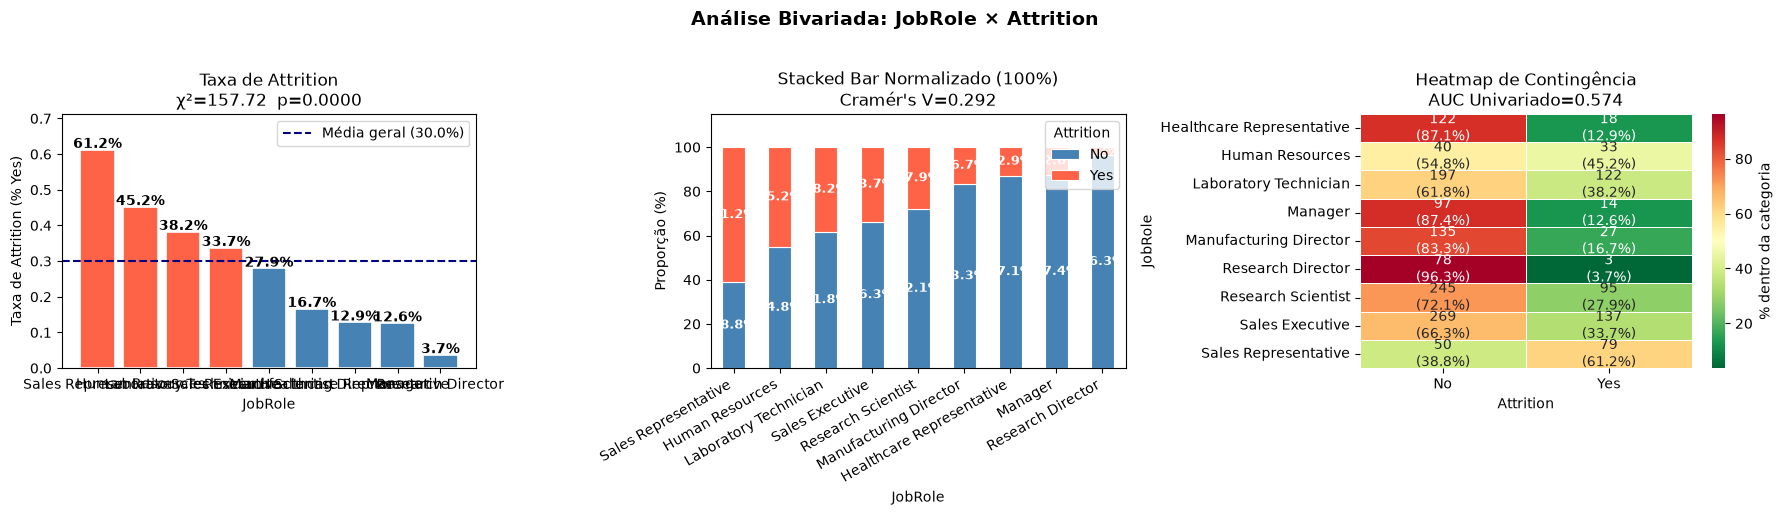

───────────────────────────────────────────────────────
  JobRole
  χ²=157.72  p=0.0000  |  Cramér's V=0.2917  |  AUC=0.5738  |  Discriminação: 🟡 Média
───────────────────────────────────────────────────────



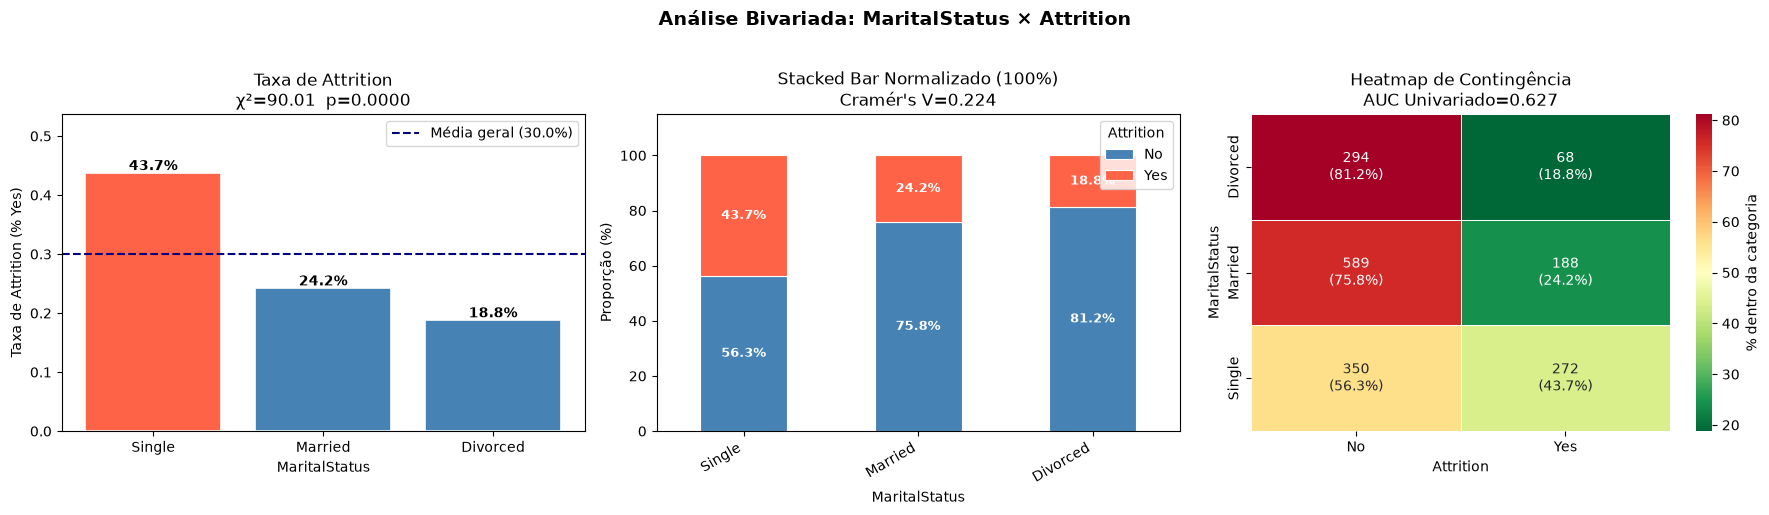

───────────────────────────────────────────────────────
  MaritalStatus
  χ²=90.01  p=0.0000  |  Cramér's V=0.2236  |  AUC=0.6273  |  Discriminação: 🟢 Alta
───────────────────────────────────────────────────────



/tmp/ipykernel_101455/3643401091.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))


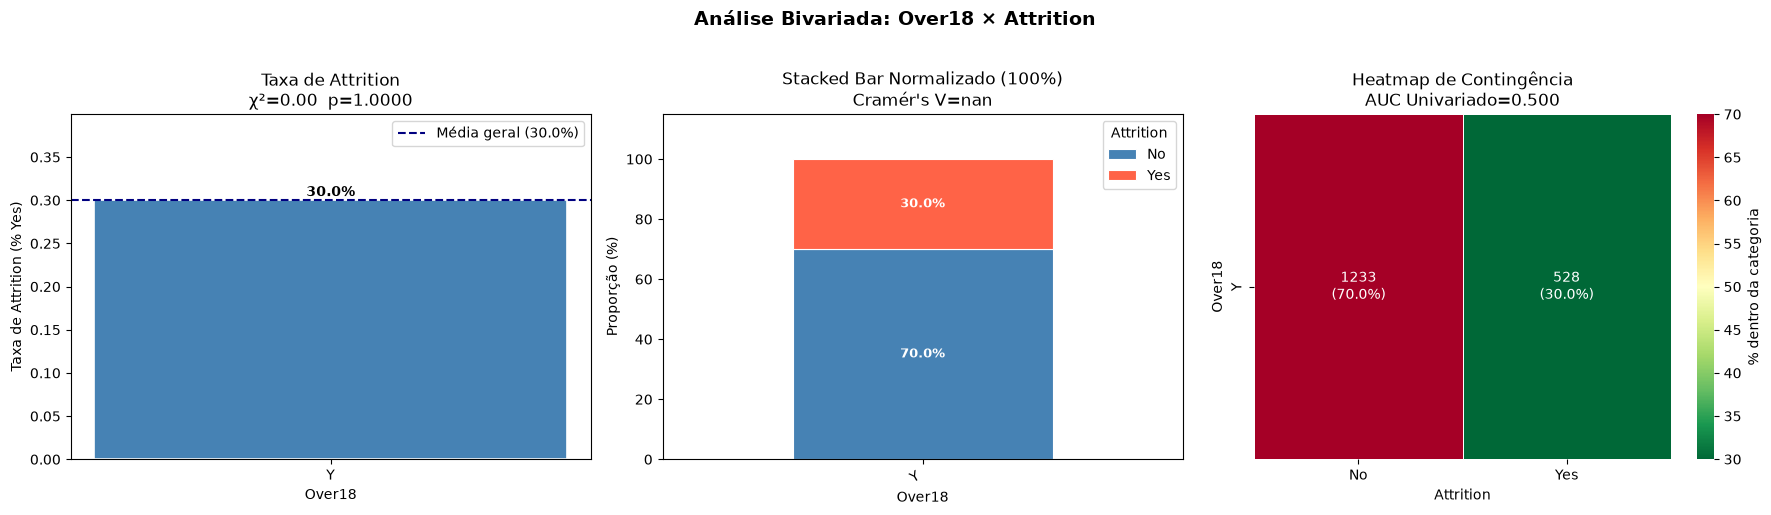

───────────────────────────────────────────────────────
  Over18
  χ²=0.00  p=1.0000  |  Cramér's V=nan  |  AUC=0.5000  |  Discriminação: 🔴 Baixa
───────────────────────────────────────────────────────



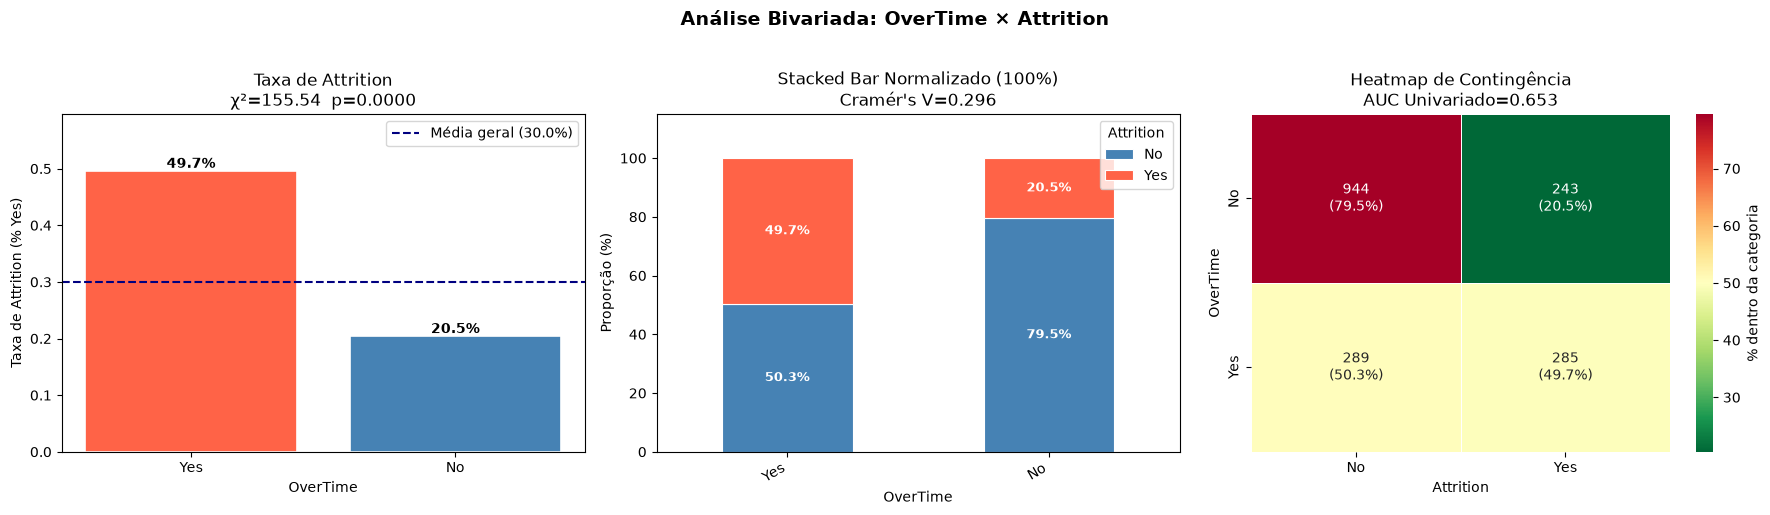

───────────────────────────────────────────────────────
  OverTime
  χ²=155.54  p=0.0000  |  Cramér's V=0.2963  |  AUC=0.6527  |  Discriminação: 🟢 Alta
───────────────────────────────────────────────────────



In [72]:
import math

col_target = 'Attrition'
y_binary   = (df_raw[col_target] == 'Yes').astype(int)
cat_cols   = df_raw.select_dtypes(include=['object']).columns.tolist()
cat_cols   = [c for c in cat_cols if c != col_target]

for col in cat_cols:

    # --- Métricas ---
    contingency       = pd.crosstab(df_raw[col], df_raw[col_target])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    cv  = cramers_v(df_raw[col], df_raw[col_target])

    X_enc = LabelEncoder().fit_transform(df_raw[col]).reshape(-1, 1)
    model = LogisticRegression(max_iter=300).fit(X_enc, y_binary)
    auc   = roc_auc_score(y_binary, model.predict_proba(X_enc)[:, 1])
    auc   = max(auc, 1 - auc)

    attrition_rate = (
        df_raw.groupby(col)[col_target]
        .apply(lambda x: (x == 'Yes').mean())
        .sort_values(ascending=False)
        .reset_index()
    )
    attrition_rate.columns = [col, 'Taxa Attrition']
    taxa_geral = y_binary.mean()

    # --- Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Análise Bivariada: {col} × {col_target}',
                 fontsize=14, fontweight='bold', y=1.02)

    # ── Plot 1: Taxa de Attrition por categoria ──────────────────────────
    bars = axes[0].bar(
        attrition_rate[col], attrition_rate['Taxa Attrition'],
        color=['tomato' if v > taxa_geral else 'steelblue'
               for v in attrition_rate['Taxa Attrition']],
        edgecolor='white', linewidth=1.2
    )
    axes[0].axhline(taxa_geral, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Média geral ({taxa_geral:.1%})')

    for bar, val in zip(bars, attrition_rate['Taxa Attrition']):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005,
                     f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

    axes[0].set_title(f'Taxa de Attrition\nχ²={chi2:.2f}  p={p_value:.4f}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Taxa de Attrition (% Yes)')
    axes[0].set_ylim(0, attrition_rate['Taxa Attrition'].max() + 0.1)
    axes[0].legend()

    # ── Plot 2: Stacked Bar 100% normalizado ─────────────────────────────
    stacked = (
        pd.crosstab(df_raw[col], df_raw[col_target], normalize='index') * 100
    ).loc[attrition_rate[col]]   # mesma ordem do plot 1

    stacked[['No', 'Yes']].plot(
        kind='bar', stacked=True, ax=axes[1],
        color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8
    )

    for idx, (_, row_data) in enumerate(stacked.iterrows()):
        axes[1].text(idx, row_data['No'] / 2,
                     f"{row_data['No']:.1f}%", ha='center', va='center',
                     color='white', fontsize=9, fontweight='bold')
        axes[1].text(idx, row_data['No'] + row_data['Yes'] / 2,
                     f"{row_data['Yes']:.1f}%", ha='center', va='center',
                     color='white', fontsize=9, fontweight='bold')

    axes[1].set_title(f"Stacked Bar Normalizado (100%)\nCramér's V={cv:.3f}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Proporção (%)')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
    axes[1].legend(title='Attrition', loc='upper right')
    axes[1].set_ylim(0, 115)

    # ── Plot 3: Heatmap de contingência ──────────────────────────────────
    cont_abs = pd.crosstab(df_raw[col], df_raw[col_target])
    cont_pct = pd.crosstab(df_raw[col], df_raw[col_target], normalize='index') * 100
    annot    = cont_abs.astype(str) + '\n(' + cont_pct.round(1).astype(str) + '%)'

    sns.heatmap(cont_pct, annot=annot, fmt='', cmap='RdYlGn_r',
                ax=axes[2], linewidths=0.5,
                cbar_kws={'label': '% dentro da categoria'},
                annot_kws={'size': 10})

    axes[2].set_title(f'Heatmap de Contingência\nAUC Univariado={auc:.3f}')
    axes[2].set_xlabel(col_target)
    axes[2].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    # --- Resumo textual ---
    discriminacao = '🟢 Alta' if auc >= 0.60 else '🟡 Média' if auc >= 0.55 else '🔴 Baixa'
    print(f"{'─'*55}")
    print(f"  {col}")
    print(f"  χ²={chi2:.2f}  p={p_value:.4f}  |  Cramér's V={cv:.4f}  |  AUC={auc:.4f}  |  Discriminação: {discriminacao}")
    print(f"{'─'*55}\n")


### 3.3. Multivariate Analysis

### 3.3 Multivariate Analysis — Matriz de Correlação Mista
Combina dois tipos de correlação numa única matriz, porque o dataset tem variáveis numéricas e categóricas juntas:
- **Pearson**: entre pares numérico × numérico.
- **Cramér's V**: entre pares que envolvem ao menos uma variável categórica (categórica × categórica ou numérica × categórica, esta última usando os valores numéricos convertidos para string).

O heatmap mostra só a metade inferior da matriz (a matriz é simétrica, então a metade superior é redundante) e demarca visualmente o bloco de variáveis numéricas vs. categóricas com linhas tracejadas.

O segundo gráfico (ranking) extrai apenas a coluna/linha `Attrition` da matriz e ordena as variáveis pela força de associação absoluta com o alvo — um resumo direto de "quais variáveis mais se relacionam com a rotatividade", destacando em vermelho as que passam do limiar arbitrário de 0.30.


/tmp/ipykernel_101455/2842578803.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df03.select_dtypes(include=['object']).columns.tolist()
/home/alvaro/.pyenv/versions/3.14.2/envs/metodologiacrisp/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alvaro/.pyenv/versions/3.14.2/envs/metodologiacrisp/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/alvaro/.pyenv/versi

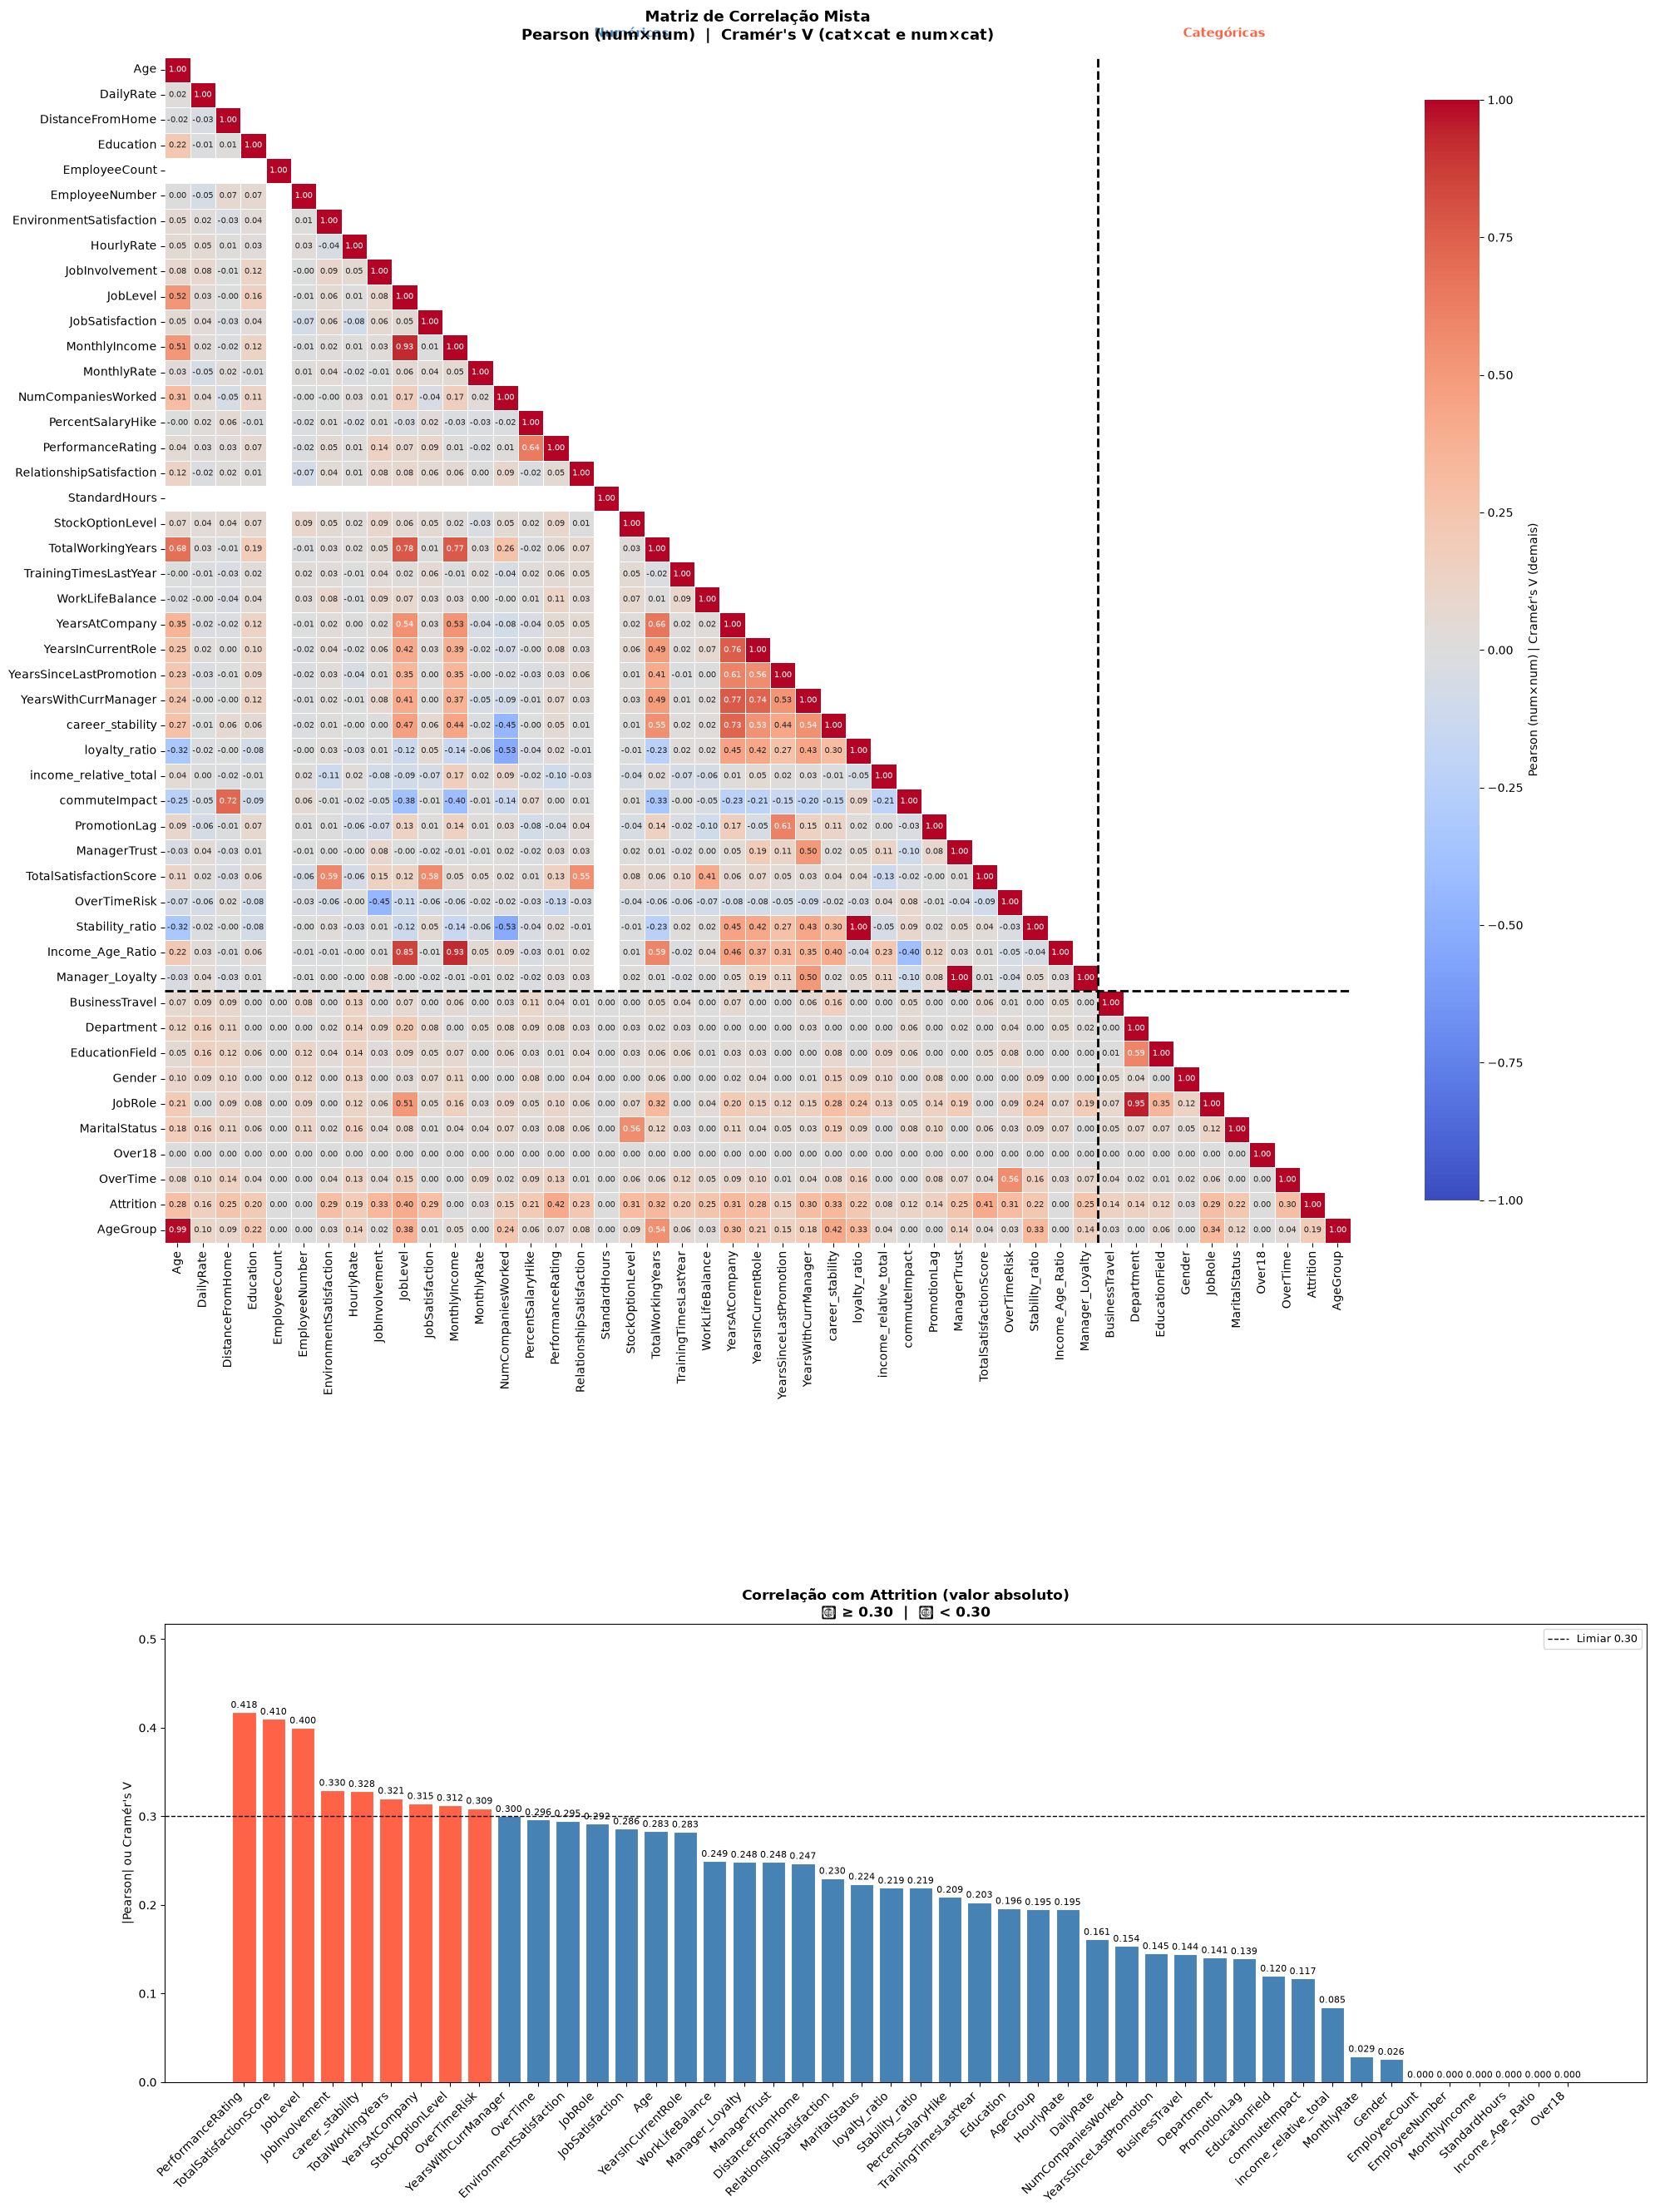


TOP CORRELAÇÕES COM ATTRITION
PerformanceRating           0.417522
TotalSatisfactionScore      0.409976
JobLevel                    0.399916
JobInvolvement              0.329516
career_stability            0.328182
TotalWorkingYears           0.320506
YearsAtCompany              0.314512
StockOptionLevel            0.312497
OverTimeRisk                0.309107
YearsWithCurrManager        0.299994
OverTime                    0.296319
EnvironmentSatisfaction     0.294946
JobRole                     0.291659
JobSatisfaction             0.286037
Age                         0.283090
YearsInCurrentRole          0.282552
WorkLifeBalance             0.249404
Manager_Loyalty             0.248483
ManagerTrust                0.248483
DistanceFromHome            0.246988
RelationshipSatisfaction    0.230091
MaritalStatus               0.223622
loyalty_ratio               0.219163
Stability_ratio             0.219163
PercentSalaryHike           0.208870
TrainingTimesLastYear       0.203140
Educati

In [76]:
# ================================================
# Matriz de Correlação Mista: Pearson + Cramér's V
# ================================================

num_cols = df03.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df03.select_dtypes(include=['object']).columns.tolist()
all_cols = num_cols + cat_cols

n = len(all_cols)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=all_cols, columns=all_cols)

for col_a in all_cols:
    for col_b in all_cols:

        a_is_num = col_a in num_cols
        b_is_num = col_b in num_cols

        if col_a == col_b:
            corr_matrix.loc[col_a, col_b] = 1.0

        elif a_is_num and b_is_num:
            corr_matrix.loc[col_a, col_b] = df03[col_a].corr(df03[col_b])

        else:
            v = cramers_v(df03[col_a].astype(str), df03[col_b].astype(str))
            corr_matrix.loc[col_a, col_b] = v
            corr_matrix.loc[col_b, col_a] = v

corr_matrix = corr_matrix.astype(float)

# ── Visualização: 2 linhas × 1 coluna ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 30),
                          gridspec_kw={'height_ratios': [4, 1]})

# ── Plot 1: Heatmap completo ──────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=axes[0],
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.4,
    square=True,
    cbar_kws={'label': "Pearson (num×num) | Cramér's V (demais)", 'shrink': 0.6}
)

n_num = len(num_cols)
axes[0].axhline(n_num, color='black', linewidth=2, linestyle='--')
axes[0].axvline(n_num, color='black', linewidth=2, linestyle='--')

axes[0].text(n_num / 2, -0.8, 'Numéricas', ha='center',
             fontsize=11, fontweight='bold', color='steelblue')
axes[0].text(n_num + len(cat_cols) / 2, -0.8, 'Categóricas', ha='center',
             fontsize=11, fontweight='bold', color='tomato')

axes[0].set_title("Matriz de Correlação Mista\nPearson (num×num)  |  Cramér's V (cat×cat e num×cat)",
                   fontsize=13, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

# ── Plot 2: Ranking de correlação com Attrition ───────────────────────────
if 'Attrition' in all_cols:
    attrition_corr = (
        corr_matrix['Attrition']
        .drop('Attrition')
        .abs()
        .sort_values(ascending=False)
    )

    colors = ['tomato' if v >= 0.3 else 'steelblue' for v in attrition_corr.values]

    axes[1].bar(attrition_corr.index, attrition_corr.values,
                color=colors, edgecolor='white', linewidth=0.8)
    axes[1].axhline(0.3, color='black', linestyle='--',
                    linewidth=1, label='Limiar 0.30')

    for i, (feat, val) in enumerate(attrition_corr.items()):
        axes[1].text(i, val + 0.005, f'{val:.3f}',
                     ha='center', fontsize=8, color='black')

    axes[1].set_title("Correlação com Attrition (valor absoluto)\n🔴 ≥ 0.30  |  🔵 < 0.30",
                       fontsize=12, fontweight='bold')
    axes[1].set_ylabel("|Pearson| ou Cramér's V")
    axes[1].set_xticks(range(len(attrition_corr)))
    axes[1].set_xticklabels(attrition_corr.index, rotation=45, ha='right')
    axes[1].set_ylim(0, attrition_corr.max() + 0.1)
    axes[1].legend(fontsize=9)

plt.tight_layout(h_pad=4)
plt.show()

# --- Resumo textual ---
print(f"\n{'='*50}")
print("TOP CORRELAÇÕES COM ATTRITION")
print(f"{'='*50}")
print(attrition_corr.to_string())
